# P&P Full Evaluation — LIBERO-PRO

Three-phase evaluation (baseline → uncertainty measurement → refinement) across
position-perturbation and distractor suites, followed by a detailed analysis section.

**Run order — first session:** 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14

**Run order — subsequent sessions:** 1 → 2 → 3b → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14

---
## 1. GPU Check & Drive Mount
Run every session.

In [1]:
import subprocess, torch
print(subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True).stdout.strip())
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE      = '/content/drive/MyDrive'
CACHE_DIR  = f'{DRIVE}/cs159_jeff/smolvla_colab_cache'
RESULTS_DIR = f'{DRIVE}/cs159_jeff/libero_pro_results'
DB_PATH    = f'{RESULTS_DIR}/rollouts_jeff_dimensional.db'
HF_HOME = f'{CACHE_DIR}/hf_models'
# SNAPSHOT   = f'{CACHE_DIR}/site_packages.tar.gz'
# LIBERO_TAR = f'{CACHE_DIR}/libero_pro_files.tar.gz'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(HF_HOME, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

os.environ['HF_HOME']               = HF_HOME
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['MUJOCO_GL']             = 'egl'

SNAPSHOT  = f'{CACHE_DIR}/site_packages.tar.gz'
PRO_CACHE = f'{CACHE_DIR}/libero_pro_files.tar.gz'

print(f'\nPackage snapshot: {"FOUND" if os.path.exists(SNAPSHOT) else "NOT FOUND — run Section 3"}')
print(f'LIBERO-PRO cache: {"FOUND" if os.path.exists(PRO_CACHE) else "NOT FOUND — run Section 5b"}')

NVIDIA L4, 23034 MiB
CUDA: True
GPU:  NVIDIA L4
VRAM: 23.7 GB
Mounted at /content/drive

Package snapshot: FOUND
LIBERO-PRO cache: FOUND


---
## 2. System Libraries
Run once per session (~2 min).

In [ ]:
%%bash
apt-get update -qq
apt-get install -y -qq \
    libosmesa6-dev libgl1-mesa-glx libglfw3 libglew-dev \
    libegl1-mesa-dev patchelf ffmpeg
mkdir -p /usr/share/glvnd/egl_vendor.d
echo '{"file_format_version":"1.0.0","ICD":{"library_path":"libEGL_nvidia.so.0"}}' \
    > /usr/share/glvnd/egl_vendor.d/10_nvidia.json
echo 'System deps done'

Selecting previously unselected package libglx-dev:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../00-libglx-dev_1.4.0-1_amd64.deb ...
Unpacking libglx-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libgl-dev:amd64.
Preparing to unpack .../01-libgl-dev_1.4.0-1_amd64.deb ...
Unpacking libgl-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libegl-dev:amd64.
Preparing to unpack .../02-libegl-dev_1.4.0-1_amd64.deb ...
Unpacking libegl-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libglvnd-core-dev:amd64.
Preparing to unpack .../03-libglvnd-core-dev_1.4.0-1_amd64.deb ...
Unpacking libglvnd-core-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libgles1:amd64.
Preparing to unpack .../04-libgles1_1.4.0-1_amd64.deb ...
Unpacking libgles1:amd64 (1.4.0-1) ...
Selecting previously unselected package libgles-dev:amd64.
Preparing to unpack .../05-libgles-dev_1.4.0-1_amd64.deb ...


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


---
## 3. Python Package Install & Snapshot
### 3a. Full install — FIRST SESSION ONLY
Skip to **3b** on subsequent sessions.

In [ ]:
# ── Full pip install (first session only) ────────────────────────────────────
import subprocess, os
CACHE_DIR = '/content/drive/MyDrive/smolvla_colab_cache'
SNAPSHOT  = f'{CACHE_DIR}/site_packages.tar.gz'

packages = [
    'git+https://github.com/huggingface/lerobot.git#egg=lerobot[smolvla]',
    'mujoco', 'robosuite', 'libero',
]
for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.run(['pip', 'install', '-q', pkg], check=True)

print('\nSaving snapshot to Drive...')
subprocess.run(
    ['tar', '-czf', SNAPSHOT,
     '-C', '/usr/local/lib',
     f'python3.{__import__("sys").version_info.minor}/dist-packages'],
    check=True)
print(f'Snapshot saved: {SNAPSHOT}')

### 3b. Fast restore from Drive snapshot — SUBSEQUENT SESSIONS

In [ ]:
import subprocess, sys, os, time, shutil, importlib

LOCAL_SNAPSHOT = '/content/site_packages_restore.tar.gz'

if not os.path.exists(SNAPSHOT):
    raise FileNotFoundError(
        'No snapshot found. Run Section 3a (full install) first to create it.'
    )

t0 = time.time()
size_mb = os.path.getsize(SNAPSHOT) / 1e6
print(f'Found snapshot on Drive: {size_mb:.0f} MB')

print('Copying snapshot from Drive to local disk (avoids Drive timeout bugs)...')
shutil.copy(SNAPSHOT, LOCAL_SNAPSHOT)

print('Extracting packages...')
result = subprocess.run(
    ['tar', '-xzf', LOCAL_SNAPSHOT, '-C', '/'],
    capture_output=True, text=True
)
os.remove(LOCAL_SNAPSHOT)

if result.returncode != 0:
    print('Restore failed:', result.stderr[:500])
else:
    elapsed = time.time() - t0
    print(f'Restored in {elapsed:.1f}s')

importlib.invalidate_caches()

for pkg in ['mujoco', 'robosuite', 'libero', 'lerobot']:
    try:
        importlib.import_module(pkg)
        print(f'  {pkg} OK')
    except ImportError as e:
        print(f'  {pkg} MISSING: {e}')
print('Restore complete.')

Found snapshot on Drive: 11198 MB
Copying snapshot from Drive to local disk (avoids Drive timeout bugs)...
Extracting packages...
Restored in 434.1s


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


  mujoco OK
  robosuite OK
  libero OK
  lerobot OK
Restore complete.


---
## 4. Clone LIBERO-PRO Repo
Run every session (fast, just clones the repo without installing).

In [ ]:
import subprocess, os

REPO_DIR = '/content/LIBERO-PRO'
if not os.path.exists(REPO_DIR):
    print('Cloning LIBERO-PRO...')
    result = subprocess.run(
        ['git', 'clone', '--depth=1',
         'https://github.com/Zxy-MLlab/LIBERO-PRO.git',
         REPO_DIR],
        capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f'Clone failed:\n{result.stderr}')
    print('Clone complete.')
else:
    print(f'Repo already exists at {REPO_DIR}')

# Verify bddl directory structure
bddl_root = f'{REPO_DIR}/libero/libero/bddl_files'
if os.path.exists(bddl_root):
    suites = sorted(os.listdir(bddl_root))
    print(f'LIBERO-PRO bddl suites found: {len(suites)}')
    pos_suites  = [s for s in suites if 'temp_' in s]
    with_suites = [s for s in suites if '_with_' in s]
    print(f'  Position perturbation: {pos_suites}')
    print(f'  Distractor (_with_*): {with_suites}')
else:
    print('WARNING: bddl_files not found in repo clone')

Cloning LIBERO-PRO...
Clone complete.
LIBERO-PRO bddl suites found: 52
  Position perturbation: ['libero_object_temp_x0.1', 'libero_object_temp_x0.2', 'libero_object_temp_x0.3', 'libero_object_temp_x0.4', 'libero_object_temp_x0.5', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_object_temp_y0.3', 'libero_object_temp_y0.4', 'libero_object_temp_y0.5']
  Distractor (_with_*): ['libero_10_with_blue_stick', 'libero_10_with_diffpos_stick', 'libero_10_with_milk', 'libero_10_with_mug', 'libero_10_with_red_box', 'libero_10_with_red_stick', 'libero_goal_with_blue_stick', 'libero_goal_with_diffpos_stick', 'libero_goal_with_green_mug', 'libero_goal_with_milk', 'libero_goal_with_mug', 'libero_goal_with_red_box', 'libero_goal_with_red_stick', 'libero_goal_with_rotated_stick', 'libero_goal_with_yellow_book', 'libero_object_with_blue_stick', 'libero_object_with_diffpos_stick', 'libero_object_with_mug', 'libero_object_with_red_box', 'libero_object_with_red_stick', 'libero_object_with_tri

---
## 5. LIBERO-PRO Assets (bddl + init files)
### 5a. Download from HuggingFace & save to Drive cache — FIRST SESSION ONLY

In [ ]:
# ── Download LIBERO-PRO bddl + init files from HuggingFace and cache ─────────
# Repo: zhouxueyang/LIBERO-Pro (dataset) — contains bddl_files/ and init_files/
import sys, os, tarfile, time
from huggingface_hub import snapshot_download

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
CACHE_DIR   = '/content/drive/MyDrive/smolvla_colab_cache'
PRO_CACHE   = f'{CACHE_DIR}/libero_pro_files.tar.gz'
HF_TMP      = '/content/libero_pro_hf'

if os.path.exists(PRO_CACHE):
    print(f'Cache already exists ({os.path.getsize(PRO_CACHE)//1024//1024} MB). '
          f'Use Section 5b to restore.')
else:
    print('Downloading from HuggingFace (zhouxueyang/LIBERO-Pro)...')
    t0 = time.time()
    snapshot_download(
        repo_id='zhouxueyang/LIBERO-Pro',
        repo_type='dataset',
        local_dir=HF_TMP,
    )
    print(f'Downloaded in {time.time()-t0:.0f}s. Compressing to Drive...')

    t1 = time.time()
    with tarfile.open(PRO_CACHE, 'w:gz') as tar:
        for subdir in ['bddl_files', 'init_files']:
            src = os.path.join(HF_TMP, subdir)
            if os.path.exists(src):
                tar.add(src, arcname=subdir)
                print(f'  Packed {subdir}/')
            else:
                print(f'  WARNING: {subdir} not found in download')
    print(f'Saved to Drive in {time.time()-t1:.0f}s '
          f'({os.path.getsize(PRO_CACHE)//1024//1024} MB)')

Cache already exists (0 MB). Use Section 5b to restore.


### 5b. Restore from Drive cache — SUBSEQUENT SESSIONS

In [ ]:
# ── Restore bddl + init files from Drive cache ────────────────────────────────
import sys, os, tarfile

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
CACHE_DIR   = f'{DRIVE}/cs159_jeff/smolvla_colab_cache'
PRO_CACHE   = f'{CACHE_DIR}/libero_pro_files.tar.gz'

assert os.path.exists(PRO_CACHE), f'Cache not found: {PRO_CACHE} — run Section 5a first'
print('Restoring LIBERO-PRO files from Drive cache...')
with tarfile.open(PRO_CACHE, 'r:gz') as tar:
    tar.extractall(LIBERO_SITE)
print('Restore complete.')
print(f'  bddl_files: {len(os.listdir(os.path.join(LIBERO_SITE, "bddl_files")))} entries')
print(f'  init_files: {len(os.listdir(os.path.join(LIBERO_SITE, "init_files")))} entries')

Restoring LIBERO-PRO files from Drive cache...
Restore complete.
  bddl_files: 21 entries
  init_files: 21 entries


/tmp/ipykernel_3391/1872230037.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(LIBERO_SITE)


In [ ]:
# ── Pre-import libero benchmark using pip version before patching ─────────────
# Must happen before Section 6 copies LIBERO-PRO files over the pip versions.
# Python will cache this import; the patched files take effect only after
# the explicit reload in Section 10.
import libero.libero.benchmark as _bm_preload
print('libero.libero.benchmark pre-loaded (pip version cached).')

Do you want to specify a custom path for the dataset folder? (Y/N): N
Initializing the default config file...
The following information is stored in the config file: /root/.libero/config.yaml
benchmark_root: /usr/local/lib/python3.12/dist-packages/libero/libero
bddl_files: /usr/local/lib/python3.12/dist-packages/libero/libero/./bddl_files
init_states: /usr/local/lib/python3.12/dist-packages/libero/libero/./init_files
datasets: /usr/local/lib/python3.12/dist-packages/libero/libero/../datasets
assets: /usr/local/lib/python3.12/dist-packages/libero/libero/./assets
libero.libero.benchmark pre-loaded (pip version cached).


---
## 6. Merge LIBERO-PRO Files & Apply All Patches
Run every session. Copies bddl/init files from the repo, registers new suites, and applies
all compatibility patches (dynamo, torch.load, CUSTOM_KEY, object aliases, benchmark dict).

In [ ]:
import shutil, os, sys, re, importlib

LIBERO_SITE    = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
LIBERO_PRO_DIR = '/content/LIBERO-PRO'

# ── Step 1: Copy patched files from LIBERO-PRO repo ──────────────────────────
files_to_patch = [
    'benchmark/__init__.py',
    'benchmark/libero_suite_task_map.py',
    'envs/objects/__init__.py',
]
for rel_path in files_to_patch:
    src = os.path.join(LIBERO_PRO_DIR, 'libero/libero', rel_path)
    dst = os.path.join(LIBERO_SITE, rel_path)
    if not os.path.exists(src):
        print(f'WARNING: not found in clone: {rel_path}')
        continue
    os.makedirs(os.path.dirname(dst), exist_ok=True)  # create benchmark/ if missing
    bak = dst + '.original_bak'
    if os.path.exists(dst) and not os.path.exists(bak):
        shutil.copy2(dst, bak)
    shutil.copy2(src, dst)
    print(f'Patched: {rel_path}')

# Copy any new object definition .py files LIBERO-PRO added
src_objects = os.path.join(LIBERO_PRO_DIR, 'libero/libero/envs/objects')
dst_objects = os.path.join(LIBERO_SITE, 'envs/objects')
for fname in os.listdir(src_objects):
    if not fname.endswith('.py'):
        continue
    dst_file = os.path.join(dst_objects, fname)
    src_file = os.path.join(src_objects, fname)
    if not os.path.exists(dst_file):
        shutil.copy2(src_file, dst_file)
        print(f'Added new object file: {fname}')

# ── Step 2: Fix libero_mine KeyError (.get() patch) ──────────────────────────
benchmark_init = os.path.join(LIBERO_SITE, 'benchmark/__init__.py')
with open(benchmark_init, 'r') as f:
    content = f.read()
old = 'for task in libero_task_map[libero_suite]:'
new = 'for task in libero_task_map.get(libero_suite, []):'
if old in content:
    content = content.replace(old, new)
    with open(benchmark_init, 'w') as f:
        f.write(content)
    print('Fixed: .get() patch applied')
elif new in content:
    print('Already fixed: .get() patch')
else:
    print('WARNING: expected line not found in benchmark/__init__.py')

# ── Step 3: Make libero_suites dynamic ───────────────────────────────────────
with open(benchmark_init, 'r') as f:
    content = f.read()
if 'libero_suites = list(libero_task_map.keys())' in content:
    print('Already patched: libero_suites dynamic')
else:
    match = re.search(r'libero_suites\s*=\s*[\[\(].*?[\]\)]', content, re.DOTALL)
    if match:
        content = content[:match.start()] + \
                  'libero_suites = list(libero_task_map.keys())' + \
                  content[match.end():]
        with open(benchmark_init, 'w') as f:
            f.write(content)
        print('Patched: libero_suites now dynamic')
    else:
        loop_match = re.search(r'for libero_suite in libero_suites:', content)
        if loop_match:
            insert_pos = loop_match.start()
            content = content[:insert_pos] + \
                      'libero_suites = list(libero_task_map.keys())\n' + \
                      content[insert_pos:]
            with open(benchmark_init, 'w') as f:
                f.write(content)
            print('Patched: libero_suites dynamic (fallback method)')
        else:
            print('ERROR: could not find patch point — check benchmark/__init__.py manually')

# ── Step 4: Add PRO suite entries to task map from bddl dirs ─────────────────
task_map_file = os.path.join(LIBERO_SITE, 'benchmark/libero_suite_task_map.py')
PRO_SUFFIXES  = ('_lan', '_swap', '_object', '_task', '_env', '_temp')
BDDL_DIR      = os.path.join(LIBERO_SITE, 'bddl_files')

with open(task_map_file, 'r') as f:
    existing = f.read()

additions = []
for suite_dir in sorted(os.listdir(BDDL_DIR)):
    if not any(suite_dir.endswith(sfx) for sfx in PRO_SUFFIXES):
        continue
    bddl_suite_dir = os.path.join(BDDL_DIR, suite_dir)
    tasks = sorted([f.replace('.bddl', '') for f in os.listdir(bddl_suite_dir)
                    if f.endswith('.bddl')])
    if not tasks:
        continue
    has_tasks = bool(re.search(
        rf'"{re.escape(suite_dir)}"\s*[:\]]\s*\[.*?\S.*?\]',
        existing, re.DOTALL))
    if has_tasks:
        continue
    additions.append((suite_dir, tasks))

if additions:
    with open(task_map_file, 'a') as f:
        f.write('\n\n# ── LIBERO-PRO standard suites (built from bddl files) ──\n')
        for suite_name, tasks in additions:
            f.write(f'libero_task_map["{suite_name}"] = [\n')
            for task in tasks:
                f.write(f'    "{task}",\n')
            f.write(']\n\n')
    print(f'Added {len(additions)} PRO suite(s) to task map')
else:
    print('Task map: all PRO suites already registered')

# ── Step 5: Register position perturbation suites in task map ────────────────
TEMP_TASKS = [
    'pick_up_the_alphabet_soup_and_place_it_in_the_basket',
    'pick_up_the_bbq_sauce_and_place_it_in_the_basket',
    'pick_up_the_butter_and_place_it_in_the_basket',
    'pick_up_the_chocolate_pudding_and_place_it_in_the_basket',
    'pick_up_the_cream_cheese_and_place_it_in_the_basket',
    'pick_up_the_ketchup_and_place_it_in_the_basket',
    'pick_up_the_milk_and_place_it_in_the_basket',
    'pick_up_the_orange_juice_and_place_it_in_the_basket',
    'pick_up_the_salad_dressing_and_place_it_in_the_basket',
    'pick_up_the_tomato_sauce_and_place_it_in_the_basket',
]
TEMP_STRENGTHS = (
    [f'libero_object_temp_x{v}' for v in ['0.1','0.2','0.3','0.4','0.5']] +
    [f'libero_object_temp_y{v}' for v in ['0.1','0.2','0.3','0.4','0.5']]
)
with open(task_map_file, 'r') as f:
    existing = f.read()
temp_additions = [s for s in TEMP_STRENGTHS if f'"{s}"' not in existing]
if temp_additions:
    with open(task_map_file, 'a') as f:
        f.write('\n\n# ── Position perturbation suites ──\n')
        for suite in temp_additions:
            f.write(f'libero_task_map["{suite}"] = [\n')
            for t in TEMP_TASKS:
                f.write(f'    "{t}",\n')
            f.write(']\n')
    print(f'Added {len(temp_additions)} position perturbation suites')
else:
    print('Position perturbation suites already registered')

# ── Step 6: Copy custom assets for _with_milk suites ─────────────────────────
REPO_ASSETS = f'{LIBERO_PRO_DIR}/notebooks/custom_assets'
DIST_ASSETS = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/notebooks/custom_assets'
if os.path.exists(REPO_ASSETS) and not os.path.exists(DIST_ASSETS):
    shutil.copytree(REPO_ASSETS, DIST_ASSETS)
    print('Copied custom_assets to dist-packages')


print('\nSection 6 complete. Run torch patches + policy load next, then Section 10 will reload benchmark.')

Patched: benchmark/__init__.py
Patched: benchmark/libero_suite_task_map.py
Patched: envs/objects/__init__.py
Added new object file: self_designed_object.py
Fixed: .get() patch applied
Patched: libero_suites now dynamic
Task map: all PRO suites already registered
Added 10 position perturbation suites
Copied custom_assets to dist-packages

Section 6 complete. Run torch patches + policy load next, then Section 10 will reload benchmark.


---
## 9. Load Policy (pi0.5)
Run every session.

In [ ]:
# # Torch Patches

# import torch
# import torch.ao.quantization as _taoq

# # Fix CUSTOM_KEY ImportError
# if not hasattr(_taoq, 'CUSTOM_KEY'):
#     setattr(_taoq, 'CUSTOM_KEY', 'custom')

# # Fix torch.load weights_only default (PyTorch 2.6)
# if not hasattr(torch, '_libero_true_load'):
#     torch._libero_true_load = torch.load
# _orig_load = torch._libero_true_load
# def _patched_load(*args, **kwargs):
#     kwargs.setdefault('weights_only', False)
#     return _orig_load(*args, **kwargs)
# torch.load = _patched_load

# # Disable torch dynamo (guard API mismatch)
# torch._dynamo.config.disable = True

# import importlib
# importlib.invalidate_caches()

# print('Torch patches applied.')

Torch patches applied.


In [ ]:
# import time, json, torch, numpy as np, os, math
# from transformers import AutoTokenizer
# from lerobot.policies.pi05.modeling_pi05 import PI05Policy
# from libero.libero import benchmark, get_libero_path
# from libero.libero.envs import OffScreenRenderEnv
# from lerobot.policies.factory import make_pre_post_processors

# from huggingface_hub import login
# login()   # paste HF token; accept PaliGemma license at hf.co/google/paligemma-3b-pt-224

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# policy = PI05Policy.from_pretrained('lerobot/pi05_libero_finetuned').to(device).eval()
# tokenizer = AutoTokenizer.from_pretrained('google/paligemma-3b-pt-224')
# print(f'PI05 loaded — {sum(p.numel() for p in policy.parameters())/1e6:.0f}M params on {device}')

# CAMERAS             = ['agentview', 'robot0_eye_in_hand']
# IMG_SIZE            = 360
# LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
# NUM_STEPS_WAIT      = 10

# preprocess, postprocess = make_pre_post_processors(
#     policy.config,
#     'lerobot/pi05_libero_finetuned',
#     preprocessor_overrides={'device_processor': {'device': str(device)}},
# )

# def _quat2axisangle(quat):
#     if quat[3] > 1.0:  quat[3] = 1.0
#     elif quat[3] < -1.0: quat[3] = -1.0
#     den = np.sqrt(1.0 - quat[3] ** 2)
#     if math.isclose(den, 0.0): return np.zeros(3)
#     return (quat[:3] * 2.0 * math.acos(quat[3])) / den

# def obs_to_policy(obs_dict, task_desc, device):
#     agentview = np.ascontiguousarray(obs_dict['agentview_image'][::-1, ::-1])
#     wrist      = np.ascontiguousarray(obs_dict['robot0_eye_in_hand_image'][::-1, ::-1])
#     img_agent  = torch.from_numpy(agentview / 255.0).permute(2,0,1).float()
#     img_wrist  = torch.from_numpy(wrist     / 255.0).permute(2,0,1).float()
#     state = np.concatenate([
#         obs_dict['robot0_eef_pos'],
#         _quat2axisangle(obs_dict['robot0_eef_quat']),
#         obs_dict['robot0_gripper_qpos'],
#     ])
#     return {
#         'observation.images.image':  img_agent,
#         'observation.images.image2': img_wrist,
#         'observation.state': torch.from_numpy(state).float(),
#         'task': task_desc,
#     }

# def run_episode(env, init_state, policy, task_desc, max_steps, device):
#     env.reset(); policy.reset()
#     obs = env.set_init_state(init_state)
#     for _ in range(NUM_STEPS_WAIT):
#         obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
#     t0 = time.time()
#     for step in range(max_steps):
#         raw_obs = obs_to_policy(obs, task_desc, device)
#         batch   = preprocess(raw_obs)
#         with torch.no_grad():
#             action = policy.select_action(batch)
#         action = postprocess(action)
#         if isinstance(action, torch.Tensor):
#             action = action.squeeze(0).cpu().numpy()
#         obs, _, done, _ = env.step(action)
#         if env.check_success():
#             return True, step+1, time.time()-t0
#         if done:
#             break
#     return False, step+1, time.time()-t0

# print('Eval helpers defined.')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi


ImportError: cannot import name 'NUMERIC_DEBUG_HANDLE_KEY' from 'torch.ao.quantization' (/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/__init__.py)

In [ ]:
import os, torch, numpy as np, time, json, math
from transformers import AutoTokenizer

# ── 1. Globally disable torch.dynamo ─────────────────────────────────────────
os.environ['TORCHDYNAMO_DISABLE'] = '1'
import torch._dynamo
torch._dynamo.config.disable = True
print('torch.dynamo disabled globally.')

# ── 2. Restore any previous torch.load patch ─────────────────────────────────
if hasattr(torch, '_libero_true_load'):
    torch.load = torch._libero_true_load

# ── 3. Patch torch.ao.quantization constants ─────────────────────────────────
import torch.ao.quantization as _taoq
for name, val in [('CUSTOM_KEY', 'custom'),
                  ('NUMERIC_DEBUG_HANDLE_KEY', 'numeric_debug_handle')]:
    if not hasattr(_taoq, name):
        setattr(_taoq, name, val)
        print(f'Patched torch.ao.quantization.{name}')

# ── 4. Fix torch.load for LIBERO .pruned_init files ──────────────────────────
try:
    torch.serialization.add_safe_globals([
        np.core.multiarray._reconstruct,
        np.ndarray, np.dtype,
        np.core.multiarray.scalar,
    ])
except Exception:
    pass

if not hasattr(torch, '_libero_true_load'):
    torch._libero_true_load = torch.load
_true = torch._libero_true_load

def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _true(*args, **kwargs)

torch.load = _patched_load
print('torch.load patched (weights_only=False default).')

# ── 5. Load policy ────────────────────────────────────────────────────────────
from lerobot.policies.pi05.modeling_pi05 import PI05Policy
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv
from lerobot.policies.factory import make_pre_post_processors
from huggingface_hub import login

login()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

policy = PI05Policy.from_pretrained('lerobot/pi05_libero_finetuned').to(device).eval()
tokenizer = AutoTokenizer.from_pretrained('google/paligemma-3b-pt-224')
print(f'PI05 loaded — {sum(p.numel() for p in policy.parameters())/1e6:.0f}M params on {device}')

CAMERAS             = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE            = 360
LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
NUM_STEPS_WAIT      = 10

preprocess, postprocess = make_pre_post_processors(
    policy.config,
    'lerobot/pi05_libero_finetuned',
    preprocessor_overrides={'device_processor': {'device': str(device)}},
)

def _quat2axisangle(quat):
    if quat[3] > 1.0:  quat[3] = 1.0
    elif quat[3] < -1.0: quat[3] = -1.0
    den = np.sqrt(1.0 - quat[3] ** 2)
    if math.isclose(den, 0.0): return np.zeros(3)
    return (quat[:3] * 2.0 * math.acos(quat[3])) / den

def obs_to_policy(obs_dict, task_desc, device):
    agentview = np.ascontiguousarray(obs_dict['agentview_image'][::-1, ::-1])
    wrist      = np.ascontiguousarray(obs_dict['robot0_eye_in_hand_image'][::-1, ::-1])
    img_agent  = torch.from_numpy(agentview / 255.0).permute(2,0,1).float()
    img_wrist  = torch.from_numpy(wrist     / 255.0).permute(2,0,1).float()
    state = np.concatenate([
        obs_dict['robot0_eef_pos'],
        _quat2axisangle(obs_dict['robot0_eef_quat']),
        obs_dict['robot0_gripper_qpos'],
    ])
    return {
        'observation.images.image':  img_agent,
        'observation.images.image2': img_wrist,
        'observation.state': torch.from_numpy(state).float(),
        'task': task_desc,
    }

def run_episode(env, init_state, policy, task_desc, max_steps, device):
    env.reset(); policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
    t0 = time.time()
    for step in range(max_steps):
        raw_obs = obs_to_policy(obs, task_desc, device)
        batch   = preprocess(raw_obs)
        with torch.no_grad():
            action = policy.select_action(batch)
        action = postprocess(action)
        if isinstance(action, torch.Tensor):
            action = action.squeeze(0).cpu().numpy()
        obs, _, done, _ = env.step(action)
        if env.check_success():
            return True, step+1, time.time()-t0
        if done:
            break
    return False, step+1, time.time()-t0

print('Eval helpers defined.')

torch.dynamo disabled globally.
Patched torch.ao.quantization.CUSTOM_KEY
Patched torch.ao.quantization.NUMERIC_DEBUG_HANDLE_KEY
torch.load patched (weights_only=False default).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned


✓ Loaded state dict from model.safetensors
All keys loaded successfully!
PI05 loaded — 4143M params on cuda
Eval helpers defined.


---
## 7. Generate Init States for Position Perturbation Suites
Must run once per session (or once ever if you cache results to Drive).
Regenerates `.pruned_init` files using the perturbed bddl positions.

In [ ]:
# import shutil, os, sys

# import numpy as np, random
# np.random.seed(42)
# random.seed(42)

# LIBERO_SITE  = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
# BDDL_DST     = os.path.join(LIBERO_SITE, 'bddl_files')
# INIT_DST     = os.path.join(LIBERO_SITE, 'init_files')
# REPO_BDDL    = '/content/LIBERO-PRO/libero/libero/bddl_files'
# LIBERO_OBJ_INIT = os.path.join(INIT_DST, 'libero_object')

# STRENGTHS = [f'libero_object_temp_x{v}' for v in ['0.1','0.2','0.3','0.4','0.5']] + \
#             [f'libero_object_temp_y{v}' for v in ['0.1','0.2','0.3','0.4','0.5']]

# for suite in STRENGTHS:
#     src_bddl = os.path.join(REPO_BDDL, suite)
#     dst_bddl = os.path.join(BDDL_DST, suite)
#     dst_init = os.path.join(INIT_DST, suite)

#     if not os.path.exists(src_bddl):
#         print(f'  SKIP (not in repo): {suite}')
#         continue

#     # Copy bddl files
#     if not os.path.exists(dst_bddl):
#         shutil.copytree(src_bddl, dst_bddl)
#         print(f'  Copied bddl: {suite}')
#     else:
#         print(f'  bddl already exists: {suite}')

#     # Copy init files from libero_object (same tasks, same robot start state)
#     if not os.path.exists(dst_init):
#         shutil.copytree(LIBERO_OBJ_INIT, dst_init)
#         print(f'  Copied init files from libero_object → {suite}')
#     else:
#         print(f'  init already exists: {suite}')

# print('\nDone.')

  Copied bddl: libero_object_temp_x0.1
  Copied init files from libero_object → libero_object_temp_x0.1
  Copied bddl: libero_object_temp_x0.2
  Copied init files from libero_object → libero_object_temp_x0.2
  Copied bddl: libero_object_temp_x0.3
  Copied init files from libero_object → libero_object_temp_x0.3
  Copied bddl: libero_object_temp_x0.4
  Copied init files from libero_object → libero_object_temp_x0.4
  Copied bddl: libero_object_temp_x0.5
  Copied init files from libero_object → libero_object_temp_x0.5
  Copied bddl: libero_object_temp_y0.1
  Copied init files from libero_object → libero_object_temp_y0.1
  Copied bddl: libero_object_temp_y0.2
  Copied init files from libero_object → libero_object_temp_y0.2
  Copied bddl: libero_object_temp_y0.3
  Copied init files from libero_object → libero_object_temp_y0.3
  Copied bddl: libero_object_temp_y0.4
  Copied init files from libero_object → libero_object_temp_y0.4
  Copied bddl: libero_object_temp_y0.5
  Copied init files from 

In [ ]:
# import numpy as np, torch, os, sys
# from libero.libero.envs import OffScreenRenderEnv

# LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
# CAMERAS     = ['agentview', 'robot0_eye_in_hand']
# IMG_SIZE    = 360
# N_STATES    = 10

# TARGET_TEMP_SUITES = [
#     'libero_object_temp_x0.1',
#     'libero_object_temp_y0.1',
#     'libero_object_temp_y0.2',
#     'libero_object_temp_x0.2',
# ]

# TASKS = [
#     'pick_up_the_alphabet_soup_and_place_it_in_the_basket',
#     'pick_up_the_bbq_sauce_and_place_it_in_the_basket',
#     'pick_up_the_butter_and_place_it_in_the_basket',
#     'pick_up_the_chocolate_pudding_and_place_it_in_the_basket',
#     'pick_up_the_cream_cheese_and_place_it_in_the_basket',
#     'pick_up_the_ketchup_and_place_it_in_the_basket',
#     'pick_up_the_milk_and_place_it_in_the_basket',
#     'pick_up_the_orange_juice_and_place_it_in_the_basket',
#     'pick_up_the_salad_dressing_and_place_it_in_the_basket',
#     'pick_up_the_tomato_sauce_and_place_it_in_the_basket',
# ]

# for suite in TARGET_TEMP_SUITES:
#     save_dir = os.path.join(LIBERO_SITE, 'init_files', suite)
#     os.makedirs(save_dir, exist_ok=True)
#     print(f'\nGenerating init states for {suite}...')

#     for task in TASKS:
#         bddl_path = os.path.join(LIBERO_SITE, 'bddl_files', suite, task + '.bddl')
#         save_path = os.path.join(save_dir, task + '.pruned_init')

#         # Force overwrite — delete any existing placeholder
#         if os.path.exists(save_path):
#             os.remove(save_path)

#         env = OffScreenRenderEnv(
#             bddl_file_name=bddl_path,
#             camera_names=CAMERAS,
#             camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
#             has_offscreen_renderer=True, use_camera_obs=True,
#             has_renderer=False, reward_shaping=False,
#         )
#         states = []
#         for _ in range(N_STATES):
#             env.reset()
#             states.append(env.sim.get_state().flatten())
#         env.close()

#         states_arr = np.array(states)
#         torch.save(states_arr, save_path)
#         print(f'  {task}: shape={states_arr.shape}')

# print('\nDone.')


Generating init states for libero_object_temp_x0.1...
Local assets not found. Downloading from HuggingFace Hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 586 files:   0%|          | 0/586 [00:00<?, ?it/s]

Assets downloaded successfully to /root/.cache/libero/assets
  pick_up_the_alphabet_soup_and_place_it_in_the_basket: shape=(10, 110)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  pick_up_the_bbq_sauce_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_butter_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_chocolate_pudding_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_cream_cheese_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_ketchup_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_milk_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_orange_juice_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_salad_dressing_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_tomato_sauce_and_place_it_in_the_basket: shape=(10, 110)

Generating init states for libero_object_temp_y0.1...
  pick_up_the_alphabet_soup_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_bbq_sauce_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_butter_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_chocolate_pudding_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_cream_cheese_and_place_it_

---
## 8. Generate Init States for Distractor Suites
Run once (idempotent — skips tasks already done).

In [ ]:
# import shutil, os, sys, importlib
# import numpy as np, torch
# from libero.libero.envs import OffScreenRenderEnv

# LIBERO_SITE   = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
# REPO_BDDL     = '/content/LIBERO-PRO/libero/libero/bddl_files'
# task_map_file = os.path.join(LIBERO_SITE, 'benchmark/libero_suite_task_map.py')
# BDDL_DIR      = os.path.join(LIBERO_SITE, 'bddl_files')
# CAMERAS       = ['agentview', 'robot0_eye_in_hand']
# IMG_SIZE      = 360
# N_STATES      = 10

# WITH_SUITES = [
#     'libero_spatial_with_milk',
#     # 'libero_spatial_with_yellow_book',
#     # 'libero_goal_with_milk',
#     'libero_goal_with_yellow_book',
#     # 'libero_object_with_yellow_book',
#     # 'libero_10_with_milk',
# ]

# # ── Step 1: Copy bddl files from repo ────────────────────────────────────────
# for suite in WITH_SUITES:
#     src = os.path.join(REPO_BDDL, suite)
#     dst = os.path.join(BDDL_DIR, suite)
#     if not os.path.exists(src):
#         print(f'  SKIP (not in repo): {suite}')
#         continue
#     if not os.path.exists(dst):
#         shutil.copytree(src, dst)
#         print(f'  Copied bddl: {suite}')
#     else:
#         print(f'  bddl already exists: {suite}')

# # ── Step 2: Generate init states ─────────────────────────────────────────────
# for suite in WITH_SUITES:
#     bddl_dir = os.path.join(BDDL_DIR, suite)
#     save_dir = os.path.join(LIBERO_SITE, 'init_files', suite)
#     if not os.path.exists(bddl_dir):
#         print(f'  SKIP (no bddl dir): {suite}')
#         continue
#     os.makedirs(save_dir, exist_ok=True)
#     tasks = sorted([f.replace('.bddl','') for f in os.listdir(bddl_dir) if f.endswith('.bddl')])
#     print(f'\nGenerating init states for {suite} ({len(tasks)} tasks)...')
#     for task in tasks:
#         bddl_path = os.path.join(bddl_dir, task + '.bddl')
#         save_path = os.path.join(save_dir, task + '.pruned_init')
#         if os.path.exists(save_path):
#             print(f'  SKIP (exists): {task[:55]}')
#             continue
#         try:
#             env = OffScreenRenderEnv(
#                 bddl_file_name=bddl_path,
#                 camera_names=CAMERAS,
#                 camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
#                 has_offscreen_renderer=True, use_camera_obs=True,
#                 has_renderer=False, reward_shaping=False,
#             )
#             states = []
#             for _ in range(N_STATES):
#                 env.reset()
#                 states.append(env.sim.get_state().flatten())
#             env.close()
#             states_arr = np.array(states)
#             torch.save(states_arr, save_path)
#             print(f'  {task[:55]}: {states_arr.shape}')
#         except Exception as e:
#             print(f'  ERROR {task[:45]}: {e}')

# # ── Step 3: Register in task map file ────────────────────────────────────────
# with open(task_map_file, 'r') as f:
#     existing = f.read()

# added = []
# with open(task_map_file, 'a') as f:
#     f.write('\n\n# ── _with_* suites ──\n')
#     for suite in WITH_SUITES:
#         if f'"{suite}"' in existing:
#             print(f'  {suite}: already in task map')
#             continue
#         bddl_suite_dir = os.path.join(BDDL_DIR, suite)
#         if not os.path.exists(bddl_suite_dir):
#             continue
#         tasks = sorted([t.replace('.bddl','') for t in os.listdir(bddl_suite_dir)
#                         if t.endswith('.bddl')])
#         f.write(f'libero_task_map["{suite}"] = [\n')
#         for t in tasks:
#             f.write(f'    "{t}",\n')
#         f.write(']\n\n')
#         added.append(suite)
#         print(f'  Added to task map: {suite} ({len(tasks)} tasks)')

# # ── Step 4: Reload task map and inject into benchmark.task_maps ──────────────
# import libero.libero.benchmark.libero_suite_task_map as _tm
# importlib.reload(_tm)
# import libero.libero.benchmark as _bm_with
# importlib.reload(_bm_with)

# from libero.libero.benchmark.libero_suite_task_map import libero_task_map
# from libero.libero.benchmark import grab_language_from_filename, Task

# for suite in WITH_SUITES:
#     if suite not in _bm_with.task_maps and suite in libero_task_map:
#         _bm_with.task_maps[suite] = {}
#         for task_name in libero_task_map[suite]:
#             try:
#                 language = grab_language_from_filename(task_name + '.bddl')
#                 _bm_with.task_maps[suite][task_name] = Task(
#                     name=task_name, language=language,
#                     problem_folder=suite, bddl_file=task_name + '.bddl')
#             except Exception as e:
#                 print(f'    WARNING task {task_name}: {e}')
#         print(f'  Injected {len(_bm_with.task_maps[suite])} tasks into task_maps[{suite}]')

# # ── Step 5: Extend monkey-patch to cover both temp and _with_* suites ─────────
# TEMP_STRENGTHS = (
#     [f'libero_object_temp_x{v}' for v in ['0.1','0.2','0.3','0.4','0.5']] +
#     [f'libero_object_temp_y{v}' for v in ['0.1','0.2','0.3','0.4','0.5']]
# )
# ALL_CUSTOM_SUITES = TEMP_STRENGTHS + WITH_SUITES

# _orig = _bm_with.get_benchmark_dict

# def _patched_get_benchmark_dict():
#     result = dict(_orig())
#     for suite in ALL_CUSTOM_SUITES:
#         if suite not in result and \
#            suite in _bm_with.task_maps and \
#            _bm_with.task_maps[suite]:
#             def make_cls(s):
#                 class _Suite:
#                     def __init__(self):
#                         self._tasks = list(_bm_with.task_maps[s].values())
#                         self.n_tasks = len(self._tasks)
#                     def get_task(self, i): return self._tasks[i]
#                     def get_task_names(self): return list(_bm_with.task_maps[s].keys())
#                     def get_task_init_states(self, i):
#                         import torch, os
#                         task = self._tasks[i]
#                         init_file = os.path.join(
#                             f'/usr/local/lib/python3.{sys.version_info.minor}'
#                             f'/dist-packages/libero/libero/init_files',
#                             task.problem_folder,
#                             task.bddl_file.replace('.bddl', '.pruned_init'))
#                         return torch.load(init_file)
#                 return _Suite
#             result[suite] = make_cls(suite)
#     return result

# _bm_with.get_benchmark_dict = _patched_get_benchmark_dict

# # ── Verify ────────────────────────────────────────────────────────────────────
# bm = _bm_with.get_benchmark_dict()
# for suite in WITH_SUITES:
#     if suite in bm:
#         n = bm[suite]().n_tasks
#         MAX_STEPS_MAP[suite] = 300
#         print(f'  {suite}: {n} tasks ✓')
#     else:
#         print(f'  {suite}: NOT in benchmark_dict ✗')

  Copied bddl: libero_spatial_with_milk
  Copied bddl: libero_goal_with_yellow_book

Generating init states for libero_spatial_with_milk (10 tasks)...
  FLOOR_SCENE1_pick_the_akita_black_bowl_between_the_plat: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_from_table_cente: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_in_the_top_layer: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_cook: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_plat: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_rame: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_cookies_b: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_ramekin_a: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_stove_and: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_wooden_ca: (10, 105)

Generating init states for libero_goal_with_yellow_book (10 tasks)...
  MAIN_TABLE_SCENE1_open_the_middle_drawer_of_the_cabinet: (10, 92)
  MAIN_TABLE_SCENE1_

NameError: name 'MAX_STEPS_MAP' is not defined

In [ ]:
# import numpy as np, torch, os, sys
# from libero.libero.envs import OffScreenRenderEnv

# LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
# CAMERAS     = ['agentview', 'robot0_eye_in_hand']
# IMG_SIZE    = 360
# N_STATES    = 10

# WITH_SUITES = [
#     'libero_spatial_with_milk',
#     # 'libero_spatial_with_yellow_book',
#     # 'libero_goal_with_milk',
#     'libero_goal_with_yellow_book',
#     # 'libero_object_with_yellow_book',
#     # 'libero_10_with_milk',
# ]

# for suite in WITH_SUITES:
#     bddl_dir = os.path.join(LIBERO_SITE, 'bddl_files', suite)
#     save_dir = os.path.join(LIBERO_SITE, 'init_files', suite)

#     if not os.path.exists(bddl_dir):
#         print(f'SKIP (no bddl): {suite}')
#         continue

#     os.makedirs(save_dir, exist_ok=True)
#     tasks = sorted([f.replace('.bddl','') for f in os.listdir(bddl_dir) if f.endswith('.bddl')])
#     print(f'\n{suite} ({len(tasks)} tasks):')

#     for task in tasks:
#         save_path = os.path.join(save_dir, task + '.pruned_init')
#         if os.path.exists(save_path):
#             print(f'  SKIP (exists): {task[:55]}')
#             continue
#         bddl_path = os.path.join(bddl_dir, task + '.bddl')
#         try:
#             env = OffScreenRenderEnv(
#                 bddl_file_name=bddl_path,
#                 camera_names=CAMERAS,
#                 camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
#                 has_offscreen_renderer=True, use_camera_obs=True,
#                 has_renderer=False, reward_shaping=False,
#             )
#             states = []
#             for _ in range(N_STATES):
#                 env.reset()
#                 states.append(env.sim.get_state().flatten())
#             env.close()
#             states_arr = np.array(states)
#             torch.save(states_arr, save_path)
#             print(f'  {task[:55]}: {states_arr.shape}')
#         except Exception as e:
#             print(f'  ERROR {task[:45]}: {e}')

# print('\nDistractor init states complete.')


libero_spatial_with_milk (10 tasks):
  FLOOR_SCENE1_pick_the_akita_black_bowl_between_the_plat: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_from_table_cente: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_in_the_top_layer: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_cook: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_plat: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_rame: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_cookies_b: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_ramekin_a: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_stove_and: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_wooden_ca: (10, 105)

libero_spatial_with_yellow_book (10 tasks):
  MAIN_TABLE_SCENE1_pick_up_the_black_bowl_between_the_pl: (10, 105)
  MAIN_TABLE_SCENE1_pick_up_the_black_bowl_from_table_cen: (10, 105)
  MAIN_TABLE_SCENE1_pick_up_the_black_bowl_in_the_top_dra: (10, 105)
  MAIN_TABLE_SCENE1_

# LOAD IN INIT STATES FROM DRIVE

In [ ]:
import shutil, os, sys

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
INIT_SRC    = f'{RESULTS_DIR}/init_files_backup_dimensional_1'
INIT_DST    = os.path.join(LIBERO_SITE, 'init_files')

TARGET_SUITES = [
    'libero_object_temp_x0.1',
    'libero_object_temp_y0.1',
    'libero_object_temp_x0.2',
    'libero_object_temp_y0.2',
    'libero_spatial_with_milk',
    'libero_goal_with_yellow_book',
]

for suite in TARGET_SUITES:
    src = os.path.join(INIT_SRC, suite)
    dst = os.path.join(INIT_DST, suite)
    if not os.path.exists(src):
        print(f'  SKIP (not in backup): {suite}')
        continue
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    n_files = len([f for f in os.listdir(dst) if f.endswith('.pruned_init')])
    print(f'  Restored {n_files} init files: {suite}')

print(f'\nInit files restored from: {INIT_SRC}')

In [ ]:
import shutil, os, sys

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
INIT_SRC    = os.path.join(LIBERO_SITE, 'init_files')
INIT_DST    = f'{RESULTS_DIR}/init_files_backup_dimensional_1'

TARGET_SUITES = [
    'libero_object_temp_x0.1',
    'libero_object_temp_y0.1',
    'libero_object_temp_x0.2',
    'libero_object_temp_y0.2',
    'libero_spatial_with_milk',
    'libero_goal_with_yellow_book',
]

os.makedirs(INIT_DST, exist_ok=True)

for suite in TARGET_SUITES:
    src = os.path.join(INIT_SRC, suite)
    dst = os.path.join(INIT_DST, suite)
    if not os.path.exists(src):
        print(f'  SKIP (not found): {suite}')
        continue
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    n_files = len([f for f in os.listdir(dst) if f.endswith('.pruned_init')])
    print(f'  Saved {n_files} init files: {suite}')

print(f'\nInit files backed up to: {INIT_DST}')

  Saved 10 init files: libero_object_temp_x0.1
  Saved 10 init files: libero_object_temp_y0.1
  Saved 10 init files: libero_object_temp_x0.2
  Saved 10 init files: libero_object_temp_y0.2
  Saved 10 init files: libero_spatial_with_milk
  Saved 10 init files: libero_goal_with_yellow_book

Init files backed up to: /content/drive/MyDrive/cs159_jeff/libero_pro_results/init_files_backup_dimensional_1


---
## 10. Benchmark Registration & Verification
Run every session after policy is loaded.

In [ ]:
import sys, os, importlib
import libero.libero.benchmark as _bm
import libero.libero.benchmark.libero_suite_task_map as _ltm

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'

# Force reload task map
importlib.reload(_ltm)
importlib.reload(_bm)

libero_task_map = _ltm.libero_task_map

TEMP_STRENGTHS = (
    [f'libero_object_temp_x{v}' for v in ['0.1','0.2','0.3','0.4','0.5']] +
    [f'libero_object_temp_y{v}' for v in ['0.1','0.2','0.3','0.4','0.5']]
)

# ── Monkey-patch get_benchmark_dict to include position perturbation suites ───
_orig_get_bm_dict = _bm.get_benchmark_dict

def _patched_get_benchmark_dict():
    result = dict(_orig_get_bm_dict())

    for suite in TEMP_STRENGTHS:
        if suite not in result and \
           suite in _bm.task_maps and \
           _bm.task_maps[suite]:

            def make_cls(s):
                class _PositionPerturbSuite:
                    def __init__(self):
                        self._tasks = list(_bm.task_maps[s].values())
                        self.n_tasks = len(self._tasks)
                    def get_task(self, i):
                        return self._tasks[i]
                    def get_task_names(self):
                        return list(_bm.task_maps[s].keys())
                    def get_task_init_states(self, i):
                        import torch, os, sys
                        task = self._tasks[i]
                        init_dir = os.path.join(
                            f'/usr/local/lib/python3.{sys.version_info.minor}'
                            f'/dist-packages/libero/libero/init_files',
                            task.problem_folder)
                        init_file = os.path.join(
                            init_dir,
                            task.bddl_file.replace('.bddl', '.pruned_init'))
                        return torch.load(init_file)
                return _PositionPerturbSuite

            result[suite] = make_cls(suite)

    return result

_bm.get_benchmark_dict = _patched_get_benchmark_dict

patched_dict = _bm.get_benchmark_dict()
found = [k for k in patched_dict if 'temp_x' in k or 'temp_y' in k]
print(f'Position perturbation suites now in benchmark_dict: {found}')

# ── Register object aliases ───────────────────────────────────────────────────
from libero.libero.envs.objects import OBJECTS_DICT

ALIASES = {
    'black_bowl':              'akita_black_bowl',
    'yellow_plate':            'plate',
    'bigger_akita_black_bowl': 'akita_black_bowl',
    'brown_rack':              'wine_rack',
    'red_cream_cheese':        'cream_cheese',
    'white_bottle':            'wine_bottle',
    'yellow_cabinet':          'wooden_cabinet',
    'yellow_stove':            'stove',
}
for alias, base in ALIASES.items():
    if alias not in OBJECTS_DICT and base in OBJECTS_DICT:
        OBJECTS_DICT[alias] = OBJECTS_DICT[base]

print(f'OBJECTS_DICT: {len(OBJECTS_DICT)} entries')

# ── Build MAX_STEPS_MAP and verify all target suites ─────────────────────────
MAX_STEPS_MAP = {}
bm_dict = _bm.get_benchmark_dict()

TARGET_SUITES = [
    # Position perturbation (known to be in 20-60% SR range)
    'libero_object_temp_x0.1',
    'libero_object_temp_y0.1',
    'libero_object_temp_y0.2',
    'libero_object_temp_x0.2',
    # Distractor (asset-verified)
    'libero_spatial_with_milk',
    # 'libero_spatial_with_yellow_book',
    # 'libero_goal_with_milk',
    'libero_goal_with_yellow_book',
    # 'libero_object_with_yellow_book',
    # 'libero_10_with_milk',
]

MAX_STEPS_DEFAULTS = {
    'libero_10': 520, 'libero_goal': 300, 'libero_object': 280,
    'libero_spatial': 300, 'libero_object_temp': 280,
}

print('\nSuite verification:')
print(f'{"Suite":<45} {"Tasks":>5}  {"Max steps":>10}  Status')
print('-' * 75)
for suite in TARGET_SUITES:
    if suite in bm_dict:
        n = bm_dict[suite]().n_tasks
        ms = 280
        for prefix, steps in MAX_STEPS_DEFAULTS.items():
            if suite.startswith(prefix):
                ms = steps
                break
        MAX_STEPS_MAP[suite] = ms
        print(f'{suite:<45} {n:>5}  {ms:>10}  ✓')
    else:
        print(f'{suite:<45} {"":>5}  {"":>10}  ✗ NOT IN BENCHMARK DICT')

print(f'\n{len(MAX_STEPS_MAP)}/{len(TARGET_SUITES)} suites ready.')

Position perturbation suites now in benchmark_dict: ['libero_object_temp_x0.1', 'libero_object_temp_x0.2', 'libero_object_temp_x0.3', 'libero_object_temp_x0.4', 'libero_object_temp_x0.5', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_object_temp_y0.3', 'libero_object_temp_y0.4', 'libero_object_temp_y0.5']
OBJECTS_DICT: 62 entries

Suite verification:
Suite                                         Tasks   Max steps  Status
---------------------------------------------------------------------------
libero_object_temp_x0.1                          10         280  ✓
libero_object_temp_y0.1                          10         280  ✓
libero_object_temp_y0.2                          10         280  ✓
libero_object_temp_x0.2                          10         280  ✓
[info] Using default task order for benchmark 'libero_spatial_with_milk' (10 tasks).
libero_spatial_with_milk                         10         300  ✓
[info] Using default task order for benchmark 'libero_goal_with

---
## 11. P&P Implementation
Monkey-patches `policy.model.sample_actions` to inject the predict-and-perturb loop.
Run every session after policy is loaded.

In [ ]:
import torch, numpy as np, types, uuid, json as _json
from dataclasses import dataclass
from typing import Optional, Sequence
from lerobot.policies.pi05.modeling_pi05 import make_att_2d_masks


@dataclass
class PnPConfig:
    enabled:              bool                    = False
    step_indices:         Optional[Sequence[int]] = (1,)
    time_min:             Optional[float]         = None
    num_iterations:       int                     = 3
    mode:                 str                     = 'both'
    action_dim:           int                     = 7
    record_per_iteration: bool                    = False

    def step_selected(self, step: int, s: float) -> bool:
        if not self.enabled: return False
        if self.time_min is not None: return s >= self.time_min
        return self.step_indices is not None and step in tuple(self.step_indices)

    @property
    def do_refine(self) -> bool:
        return self.mode in ('refine', 'both')

    @property
    def step_indices_json(self) -> Optional[str]:
        return _json.dumps(list(self.step_indices)) if self.step_indices is not None else None


class PnPRecorder:
    def __init__(self):
        self.reset()

    def reset(self):
        self.episodes   = []
        self._cur       = None
        self._chunk_idx = 0

    def new_episode(self, meta: dict = None):
        self._cur = {
            'rollout_id':     str(uuid.uuid4()),
            'meta':           dict(meta or {}),
            'chunks':         [],
            'success':        None,
            'n_steps':        None,
            'elapsed_s':      None,
            'u_mean_episode': None,
            'u_max_episode':  None,
        }
        self._chunk_idx = 0

    def log_chunk(self, chunk_rec: dict):
        if self._cur is None: return
        chunk_rec = dict(chunk_rec)
        chunk_rec['chunk_idx'] = self._chunk_idx
        self._cur['chunks'].append(chunk_rec)
        self._chunk_idx += 1

    def close_episode(self, success: bool, n_steps: int, elapsed_s: float = 0.0):
        if self._cur is None: return
        self._cur['success']   = bool(success)
        self._cur['n_steps']   = int(n_steps)
        self._cur['elapsed_s'] = float(elapsed_s)
        all_u = [st['u_mean'] for c in self._cur['chunks'] for st in c['steps']]
        if all_u:
            self._cur['u_mean_episode'] = float(np.mean(all_u))
            self._cur['u_max_episode']  = float(np.max(all_u))
        self.episodes.append(self._cur)
        self._cur = None

    @property
    def current_rollout_id(self) -> Optional[str]:
        return self._cur['rollout_id'] if self._cur else None


PNP_CONFIG   = PnPConfig()
PNP_RECORDER = PnPRecorder()


def _pnp_refine_at_step(x_t, s, vfield, cfg):
    adim   = cfg.action_dim
    x_acc  = x_t
    a_hats = []

    for _ in range(cfg.num_iterations):
        v     = vfield(x_acc)
        a_hat = x_acc - s * v
        a_hats.append(a_hat[..., :adim])
        eps   = torch.randn_like(x_acc)
        x_acc = (1.0 - s) * a_hat + s * eps

    A = torch.stack(a_hats, dim=0)
    if A.shape[0] >= 2:
        u_consecutive = (A[1:] - A[:-1]).abs().mean(dim=0)  # shape: (batch, chunk, adim)
        a_std         = A.std(dim=0)
    else:
        u_consecutive = torch.zeros_like(A[0])
        a_std         = torch.zeros_like(A[0])

    # Collapse batch dim (always 1 during inference), keep chunk and adim
    # u_vec shape: (chunk_size, adim) -> mean over chunk -> (adim,)
    u_vec_per_dim = u_consecutive.squeeze(0).mean(dim=0)  # (adim,)
    a_mean_vec    = A.mean(dim=0).squeeze(0).mean(dim=0)  # mean predicted clean action per dim

    rec = {
        's':             float(s),
        'u_mean':        float(u_consecutive.mean()),
        'u_max':         float(u_consecutive.max()),
        'u_vec':         u_vec_per_dim.detach().float().cpu().numpy().tolist(),  # list of 7
        'a_mean_vec':    a_mean_vec.detach().float().cpu().numpy().tolist(),     # list of 7
        'u_consecutive': u_consecutive.detach().float().cpu().numpy(),
        'a_std':         a_std.detach().float().cpu().numpy(),
        'a_std_mean':    float(a_std.mean()),
    }
    if cfg.record_per_iteration:
        rec['a_hats'] = A.detach().float().cpu().numpy()

    return (x_acc if cfg.do_refine else x_t), rec


@torch.no_grad()
def _sample_actions_pnp(self, images, img_masks, tokens, masks,
                          noise=None, num_steps=None, **kwargs):
    cfg = PNP_CONFIG
    if (not cfg.enabled) or self._rtc_enabled():
        return self._orig_sample_actions(
            images, img_masks, tokens, masks,
            noise=noise, num_steps=num_steps, **kwargs)

    if num_steps is None:
        num_steps = self.config.num_inference_steps
    bsize  = tokens.shape[0]
    device = tokens.device
    if noise is None:
        noise = self.sample_noise(
            (bsize, self.config.chunk_size, self.config.max_action_dim), device)

    prefix_embs, prefix_pad_masks, prefix_att_masks = \
        self.embed_prefix(images, img_masks, tokens, masks)
    prefix_att_2d_masks    = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_position_ids    = torch.cumsum(prefix_pad_masks, dim=1) - 1
    prefix_att_2d_masks_4d = self._prepare_attention_masks_4d(prefix_att_2d_masks)
    self.paligemma_with_expert.paligemma.model.language_model.config._attn_implementation = 'eager'
    _, past_key_values = self.paligemma_with_expert.forward(
        attention_mask=prefix_att_2d_masks_4d,
        position_ids=prefix_position_ids,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
    )

    dt        = -1.0 / num_steps
    x_t       = noise
    chunk_rec = {'num_steps': num_steps, 'steps': []}

    for step in range(num_steps):
        s           = 1.0 + step * dt
        time_tensor = torch.tensor(s, dtype=torch.float32, device=device).expand(bsize)

        def vfield(inp, _ts=time_tensor):
            return self.denoise_step(
                prefix_pad_masks=prefix_pad_masks,
                past_key_values=past_key_values,
                x_t=inp, timestep=_ts)

        if cfg.step_selected(step, s):
            x_t, rec = _pnp_refine_at_step(x_t, s, vfield, cfg)
            rec['step'] = step
            chunk_rec['steps'].append(rec)

        x_t = x_t + dt * vfield(x_t)

    PNP_RECORDER.log_chunk(chunk_rec)
    return x_t


# ── Apply monkey-patch ────────────────────────────────────────────────────────
try:
    from lerobot.constants import ACTION
    PNP_CONFIG.action_dim = policy.config.output_features[ACTION].shape[0]
except Exception:
    PNP_CONFIG.action_dim = 7

if not hasattr(policy.model, '_orig_sample_actions'):
    policy.model._orig_sample_actions = policy.model.sample_actions
policy.model.sample_actions = types.MethodType(_sample_actions_pnp, policy.model)

PNP_CONFIG.enabled = False
print(f'P&P ready. action_dim={PNP_CONFIG.action_dim} | '
      f'inference_steps={policy.config.num_inference_steps}')
print('PnP currently disabled.')

P&P ready. action_dim=7 | inference_steps=10
PnP currently disabled.


---
## 12. Database Setup & Eval Helpers
Run every session.

In [ ]:
import sqlite3, os, time as _time, hashlib, json as _json, numpy as np, torch

DB_PATH = f'{RESULTS_DIR}/rollouts_jeff_dimensional.db'
con     = sqlite3.connect(DB_PATH, check_same_thread=False)

con.executescript("""
    CREATE TABLE IF NOT EXISTS rollouts (
        rollout_id          TEXT PRIMARY KEY,
        suite               TEXT,
        task_idx            INTEGER,
        episode_idx         INTEGER,
        init_state_hash     TEXT,
        success             INTEGER,
        n_steps             INTEGER,
        elapsed_s           REAL,
        pnp_enabled         INTEGER,
        pnp_step_indices    TEXT,
        pnp_mode            TEXT,
        pnp_num_iterations  INTEGER,
        u_mean_episode      REAL,
        u_max_episode       REAL,
        timestamp           TEXT
    );

    CREATE TABLE IF NOT EXISTS pnp_euler_steps (
        id          INTEGER PRIMARY KEY AUTOINCREMENT,
        rollout_id  TEXT,
        chunk_idx   INTEGER,
        euler_step  INTEGER,
        u_mean      REAL,
        u_max       REAL,
        s           REAL
    );

    CREATE TABLE IF NOT EXISTS pnp_action_vectors (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        rollout_id   TEXT,
        chunk_idx    INTEGER,
        euler_step   INTEGER,
        s            REAL,
        u_vec        TEXT,   -- JSON list of 7 floats: per-dim uncertainty
        a_mean_vec   TEXT    -- JSON list of 7 floats: mean predicted clean action per dim
    );

""")
con.commit()

existing = con.execute('SELECT COUNT(*) FROM rollouts').fetchone()[0]
print(f'DB ready: {DB_PATH}  ({existing} existing rollouts)')


def _init_state_hash(init_state_arr):
    return hashlib.md5(np.asarray(init_state_arr).tobytes()).hexdigest()[:16]


def write_episode_to_db(ep, suite, task_idx, episode_idx,
                        init_state_hash, elapsed_s):
    """Write one closed PnPRecorder episode to the DB."""
    rid = ep['rollout_id']
    con.execute("""
        INSERT OR REPLACE INTO rollouts
        (rollout_id, suite, task_idx, episode_idx, init_state_hash,
         success, n_steps, elapsed_s,
         pnp_enabled, pnp_step_indices, pnp_mode, pnp_num_iterations,
         u_mean_episode, u_max_episode, timestamp)
        VALUES (?,?,?,?,?, ?,?,?, ?,?,?,?, ?,?,?)
    """, (
        rid, suite, task_idx, episode_idx, init_state_hash,
        int(ep['success']), ep['n_steps'], elapsed_s,
        int(PNP_CONFIG.enabled),
        PNP_CONFIG.step_indices_json,
        PNP_CONFIG.mode if PNP_CONFIG.enabled else None,
        PNP_CONFIG.num_iterations if PNP_CONFIG.enabled else None,
        ep.get('u_mean_episode'), ep.get('u_max_episode'),
        _time.strftime('%Y-%m-%dT%H:%M:%S'),
    ))
    for chunk in ep.get('chunks', []):
        for step_rec in chunk.get('steps', []):
            con.execute("""
                INSERT INTO pnp_euler_steps
                (rollout_id, chunk_idx, euler_step, u_mean, u_max, s)
                VALUES (?,?,?,?,?,?)
            """, (rid, chunk['chunk_idx'], step_rec['step'],
                  step_rec['u_mean'], step_rec['u_max'], step_rec['s']))

            if 'u_vec' in step_rec:
                con.execute("""
                    INSERT INTO pnp_action_vectors
                    (rollout_id, chunk_idx, euler_step, s, u_vec, a_mean_vec)
                    VALUES (?,?,?,?,?,?)
                """, (rid, chunk['chunk_idx'], step_rec['step'],
                      step_rec['s'],
                      _json.dumps(step_rec['u_vec']),
                      _json.dumps(step_rec.get('a_mean_vec', []))))
    con.commit()


# ── Eval helpers ─────────────────────────────────────────────────────────────
import torchvision.transforms.functional as TVF

CAMERAS           = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE          = 360
LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
NUM_STEPS_WAIT    = 10


def _quat2axisangle(quat):
    import numpy as np
    q = np.array(quat, dtype=float)
    if q[3] < 0:
        q = -q
    denom = np.sqrt(1.0 - q[3]**2)
    if denom < 1e-8:
        return np.zeros(3)
    return (q[:3] / denom) * 2.0 * np.arccos(q[3])


# def obs_to_policy(obs_dict, task_desc, device):
#     def _proc(img):
#         t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
#         return TVF.resize(t, [224, 224]).to(device)

#     img_agent = _proc(obs_dict['agentview_image'])
#     img_wrist = _proc(obs_dict['robot0_eye_in_hand_image'])
#     state = np.concatenate([
#         obs_dict['robot0_eef_pos'],
#         _quat2axisangle(obs_dict['robot0_eef_quat']),
#         obs_dict['robot0_gripper_qpos'],
#     ])
#     return {
#         'observation.images.image':  img_agent,
#         'observation.images.image2': img_wrist,
#         'observation.state':         torch.from_numpy(state).float().to(device),
#         'task':                      task_desc,
#     }


# def preprocess(raw_obs):
#     batch = {}
#     for k, v in raw_obs.items():
#         if isinstance(v, torch.Tensor):
#             batch[k] = v.unsqueeze(0)
#         else:
#             batch[k] = v
#     return batch


# def postprocess(action):
#     if isinstance(action, torch.Tensor):
#         return action.squeeze(0).cpu().numpy()
#     return action


def run_episode(env, init_state, policy, task_desc, max_steps, device):
    env.reset()
    policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
    t0 = _time.time()
    for step in range(max_steps):
        raw_obs = obs_to_policy(obs, task_desc, device)
        batch   = preprocess(raw_obs)
        with torch.no_grad():
            action = policy.select_action(batch)
        action = postprocess(action)
        obs, _, done, _ = env.step(action)
        if env.check_success():
            return True, step + 1, _time.time() - t0
        if done:
            break
    return False, step + 1, _time.time() - t0


print('DB and eval helpers ready.')

DB ready: /content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db  (0 existing rollouts)
DB and eval helpers ready.


---
## 13. Evaluation Configuration
Edit this cell to select suites and episode count, then run the eval loop below.

In [ ]:
# ── Eval configuration — edit as needed ──────────────────────────────────────

SUITES = [
    # Position perturbation suites (known SR range: 27-60%)
    'libero_object_temp_x0.1',   # ~53% baseline
    'libero_object_temp_y0.1',   # ~60% baseline
    'libero_object_temp_y0.2',   # ~27% baseline
    'libero_object_temp_x0.2',   # ~0% baseline
    # Distractor suites (untested — run first to confirm SR is in 20-70% range)
    'libero_spatial_with_milk',
    # 'libero_spatial_with_yellow_book',
    # 'libero_goal_with_milk',
    'libero_goal_with_yellow_book',
    # 'libero_object_with_yellow_book',
    # 'libero_10_with_milk',
]

N_EPISODES = 10   # episodes per task; use 1 for smoke test
VERBOSE    = True

# ── Phase selector — change before each run of the eval loop ─────────────────
# Phase 1: baseline
PNP_CONFIG.enabled = False

# Phase 2: uncertainty measurement only (uncomment to activate)
# PNP_CONFIG.enabled       = True
# PNP_CONFIG.mode          = 'uncertainty'
# PNP_CONFIG.step_indices  = (1, 2)
# PNP_CONFIG.num_iterations = 3

# Phase 3: uncertainty + refinement (uncomment to activate)
# PNP_CONFIG.enabled       = True
# PNP_CONFIG.mode          = 'both'
# PNP_CONFIG.step_indices  = (1, 2)
# PNP_CONFIG.num_iterations = 3

print(f'Suites:    {SUITES}')
print(f'Episodes:  {N_EPISODES}/task')
print(f'P&P mode:  {"ENABLED — " + PNP_CONFIG.mode if PNP_CONFIG.enabled else "disabled (baseline)"}')
print(f'Max steps: { {s: MAX_STEPS_MAP.get(s, 300) for s in SUITES} }')

Suites:    ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_object_temp_x0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
Episodes:  10/task
P&P mode:  disabled (baseline)
Max steps: {'libero_object_temp_x0.1': 280, 'libero_object_temp_y0.1': 280, 'libero_object_temp_y0.2': 280, 'libero_object_temp_x0.2': 280, 'libero_spatial_with_milk': 300, 'libero_goal_with_yellow_book': 300}


---
## 14. Evaluation Loop
Run this cell for each phase (baseline, uncertainty, refinement).
Results are appended to `rollouts.db` and can be re-analyzed at any time.

**Estimated runtime:** ~20 s/episode (baseline) · ~40 s/episode (P&P)
- 6 suites × 10 tasks × 10 ep × 3 phases ≈ 1800 episodes ≈ 10–14 hours total on A100
- Reduce `N_EPISODES = 5` for a ~5–7 hour run

In [ ]:
import hashlib
from tqdm.notebook import tqdm

def _hash_init_state(init_state) -> str:
    arr = np.asarray(init_state)
    return hashlib.md5(arr.tobytes()).hexdigest()[:16]


def run_episode_pnp(env, init_state, policy, task_desc,
                    max_steps, device, meta: dict = None):
    env.reset(); policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)

    PNP_RECORDER.new_episode(meta)
    t0 = time.time(); success = False; step = 0

    for step in range(max_steps):
        raw_obs = obs_to_policy(obs, task_desc, device)
        batch   = preprocess(raw_obs)
        with torch.no_grad():
            action = policy.select_action(batch)
        action = postprocess(action)
        if isinstance(action, torch.Tensor):
            action = action.squeeze(0).cpu().numpy()
        obs, _, done, _ = env.step(action)
        if env.check_success():
            success = True; break
        if done:
            break

    elapsed = time.time() - t0
    PNP_RECORDER.close_episode(success, step + 1, elapsed)
    return success, step + 1, elapsed


# ── Run ───────────────────────────────────────────────────────────────────────
all_results    = []
PNP_RECORDER.reset()
benchmark_dict = _bm.get_benchmark_dict()
total_start    = time.time()

for SUITE in tqdm(SUITES, desc='Suites'):
    print(f'\n{"="*60}\nSuite: {SUITE}\n{"="*60}')

    task_suite  = benchmark_dict[SUITE]()
    max_steps   = MAX_STEPS_MAP.get(SUITE, 300)
    suite_results = []
    suite_start   = time.time()

    for task_idx in tqdm(range(task_suite.n_tasks),
                         desc=f'  {SUITE} tasks', leave=False):
        task        = task_suite.get_task(task_idx)
        init_states = task_suite.get_task_init_states(task_idx)

        bddl_file_path = os.path.join(
            get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)

        env = OffScreenRenderEnv(
            bddl_file_name=bddl_file_path, camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False,
        )

        n_success = 0
        ep_bar    = tqdm(range(min(N_EPISODES, len(init_states))),
                         desc=f'    T{task_idx+1} ({task.language[:40]}...)',
                         leave=False)

        for ep_idx in ep_bar:
            init_state      = init_states[ep_idx]
            init_state_hash = _hash_init_state(init_state)

            success, n_steps, elapsed = run_episode_pnp(
                env, init_state, policy, task.language, max_steps, device,
                meta={
                    'suite': SUITE, 'task_idx': task_idx,
                    'episode_idx': ep_idx,
                    'init_state_hash': init_state_hash,
                })

            n_success += int(success)

            ep_record = PNP_RECORDER.episodes[-1]
            write_episode_to_db(
                ep_record, SUITE, task_idx, ep_idx,
                init_state_hash, elapsed)

            result = {
                'rollout_id':       ep_record['rollout_id'],
                'suite':            SUITE,
                'task_idx':         task_idx,
                'task_description': task.language,
                'episode':          ep_idx,
                'init_state_hash':  init_state_hash,
                'success':          success,
                'n_steps':          n_steps,
                'elapsed_s':        round(elapsed, 2),
                'pnp_enabled':      PNP_CONFIG.enabled,
                'u_mean_episode':   ep_record['u_mean_episode'],
            }
            suite_results.append(result)
            all_results.append(result)

            status = '✓' if success else '✗'
            u_str  = (f' | U={ep_record["u_mean_episode"]:.4f}'
                      if ep_record['u_mean_episode'] is not None else '')
            ep_bar.set_postfix(sr=f'{n_success}/{ep_idx+1}', status=status)
            if VERBOSE:
                tqdm.write(f'    {status} ep{ep_idx} | {n_steps} steps | '
                           f'{elapsed:.1f}s{u_str}')

        tqdm.write(f'  T{task_idx+1} SR: {n_success/N_EPISODES:.0%} '
                   f'({n_success}/{N_EPISODES}) — {task.language[:50]}...')
        env.close()

    suite_sr  = sum(r['success'] for r in suite_results) / len(suite_results)
    suite_min = (time.time() - suite_start) / 60
    tqdm.write(f'\n{SUITE} SR: {suite_sr:.1%} | Time: {suite_min:.1f} min')

overall_sr = sum(r['success'] for r in all_results) / len(all_results)
total_min  = (time.time() - total_start) / 60

print(f'\n{"="*60}')
print(f'OVERALL SR: {overall_sr:.1%} '
      f'({sum(r["success"] for r in all_results)}/{len(all_results)})')
print(f'Total time: {total_min:.1f} min')
print(f'DB: {DB_PATH}  '
      f'({con.execute("SELECT COUNT(*) FROM rollouts").fetchone()[0]} total rollouts)')
print(f'{"="*60}')

Suites:   0%|          | 0/6 [00:00<?, ?it/s]


Suite: libero_object_temp_x0.1


  libero_object_temp_x0.1 tasks:   0%|          | 0/10 [00:00<?, ?it/s]

    T1 (pick up the alphabet soup and place it i...):   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

    ✓ ep0 | 66 steps | 3.6s
    ✓ ep1 | 78 steps | 4.2s
    ✓ ep2 | 82 steps | 4.2s
    ✓ ep3 | 68 steps | 3.8s
    ✓ ep4 | 68 steps | 3.7s
    ✓ ep5 | 80 steps | 4.2s
    ✓ ep6 | 67 steps | 3.7s
    ✓ ep7 | 80 steps | 4.2s
    ✓ ep8 | 83 steps | 4.3s
    ✓ ep9 | 74 steps | 3.9s
  T8 SR: 100% (10/10) — turn on the stove...


    T9 (put the bowl on the plate...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 71 steps | 4.0s
    ✓ ep1 | 73 steps | 3.9s
    ✗ ep2 | 300 steps | 14.9s
    ✓ ep3 | 78 steps | 4.2s
    ✓ ep4 | 84 steps | 4.6s
    ✓ ep5 | 75 steps | 4.1s
    ✓ ep6 | 75 steps | 4.0s
    ✓ ep7 | 76 steps | 4.1s
    ✓ ep8 | 75 steps | 4.2s
    ✓ ep9 | 73 steps | 3.9s
  T9 SR: 90% (9/10) — put the bowl on the plate...


    T10 (put the wine bottle on the rack...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 141 steps | 7.2s
    ✓ ep1 | 139 steps | 7.3s
    ✓ ep2 | 124 steps | 6.5s
    ✓ ep3 | 125 steps | 6.5s
    ✓ ep4 | 167 steps | 8.8s
    ✓ ep5 | 128 steps | 6.7s
    ✓ ep6 | 121 steps | 6.3s
    ✓ ep7 | 140 steps | 7.3s
    ✓ ep8 | 122 steps | 6.4s
    ✓ ep9 | 154 steps | 8.3s
  T10 SR: 100% (10/10) — put the wine bottle on the rack...

libero_goal_with_yellow_book SR: 88.0% | Time: 14.9 min

OVERALL SR: 48.2% (289/600)
Total time: 121.2 min
DB: /content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db  (600 total rollouts)


# PHASE 2 UNCERTAINTY

Doing this as a separate cell for now (instead of rerunning the one above) in case I fall asleep, can just be run as one cell in the future

In [ ]:
# ── Phase 2: Uncertainty measurement ─────────────────────────────────────────
import hashlib, time
from tqdm.notebook import tqdm

SUITES     = ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
N_EPISODES = 10
VERBOSE    = True

PNP_CONFIG.enabled        = True
PNP_CONFIG.mode           = 'uncertainty'
PNP_CONFIG.step_indices   = (3, 4)
PNP_CONFIG.num_iterations = 3

print(f'Suites:    {SUITES}')
print(f'Episodes:  {N_EPISODES}/task')
print(f'P&P mode:  {PNP_CONFIG.mode}')

# Verify
assert hasattr(policy.model, '_orig_sample_actions'), \
    "ERROR: monkey-patch not applied — rerun Section 11"
assert policy.model.sample_actions != policy.model._orig_sample_actions, \
    "ERROR: sample_actions not patched"
assert PNP_CONFIG.enabled, "ERROR: PNP_CONFIG.enabled is False"

import types
is_patched = isinstance(policy.model.sample_actions, types.MethodType) and \
             policy.model.sample_actions.__func__.__name__ == '_sample_actions_pnp'
assert is_patched, "ERROR: sample_actions is not _sample_actions_pnp"

print(f'P&P active: mode={PNP_CONFIG.mode}, steps={PNP_CONFIG.step_indices}, K={PNP_CONFIG.num_iterations}')

Suites:    ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
Episodes:  10/task
P&P mode:  uncertainty
P&P active: mode=uncertainty, steps=(3, 4), K=3


In [ ]:
# Quick single-episode test to verify uncertainty + dimension vectors are logged
PNP_RECORDER.reset()
bm_dict = _bm.get_benchmark_dict()
task_suite = bm_dict['libero_object_temp_x0.1']()
task = task_suite.get_task(0)
init_states = task_suite.get_task_init_states(0)
bddl_path = os.path.join(get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)

env = OffScreenRenderEnv(
    bddl_file_name=bddl_path, camera_names=CAMERAS,
    camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
    has_offscreen_renderer=True, use_camera_obs=True,
    has_renderer=False, reward_shaping=False,
)

PNP_RECORDER.new_episode({'suite': 'test', 'task_idx': 0, 'episode_idx': 0, 'init_state_hash': 'test'})
env.reset(); policy.reset()
obs = env.set_init_state(init_states[0])
for _ in range(NUM_STEPS_WAIT):
    obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)

for step in range(50):
    raw_obs = obs_to_policy(obs, task.language, device)
    batch = preprocess(raw_obs)
    with torch.no_grad():
        action = policy.select_action(batch)
    action = postprocess(action)
    if isinstance(action, torch.Tensor):
        action = action.squeeze(0).cpu().numpy()
    obs, _, done, _ = env.step(action)
    if env.check_success() or done:
        break

PNP_RECORDER.close_episode(False, step+1, 0.0)
env.close()

ep = PNP_RECORDER.episodes[-1]
print(f'u_mean_episode:  {ep["u_mean_episode"]}')
print(f'u_max_episode:   {ep["u_max_episode"]}')
print(f'chunks logged:   {len(ep["chunks"])}')

DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']

if ep['chunks']:
    print(f'\nsteps in chunk 0: {len(ep["chunks"][0]["steps"])}')
    for s in ep['chunks'][0]['steps']:
        print(f'\n  step={s["step"]}  s={s["s"]:.3f}  u_mean={s["u_mean"]:.4f}  u_max={s["u_max"]:.4f}')

        # Check u_vec (per-dim uncertainty)
        if 'u_vec' in s:
            print(f'  u_vec (per-dim uncertainty):')
            for dim, val in zip(DIM_NAMES, s['u_vec']):
                bar = '█' * int(val / max(s['u_vec']) * 20) if max(s['u_vec']) > 0 else ''
                print(f'    {dim:>7}: {val:.4f}  {bar}')
        else:
            print('  WARNING: u_vec not found in step record')

        # Check a_mean_vec (mean predicted clean action per dim)
        if 'a_mean_vec' in s:
            print(f'  a_mean_vec (mean predicted action):')
            for dim, val in zip(DIM_NAMES, s['a_mean_vec']):
                print(f'    {dim:>7}: {val:+.4f}')
        else:
            print('  WARNING: a_mean_vec not found in step record')

# Assertions
assert ep['u_mean_episode'] is not None, \
    "ERROR: u_mean_episode is None — P&P inner loop not executing"
assert ep['chunks'] and ep['chunks'][0]['steps'], \
    "ERROR: no steps logged in chunk"
assert 'u_vec' in ep['chunks'][0]['steps'][0], \
    "ERROR: u_vec not in step record — check _pnp_refine_at_step"
assert 'a_mean_vec' in ep['chunks'][0]['steps'][0], \
    "ERROR: a_mean_vec not in step record — check _pnp_refine_at_step"
assert len(ep['chunks'][0]['steps'][0]['u_vec']) == 7, \
    f"ERROR: u_vec has wrong length {len(ep['chunks'][0]['steps'][0]['u_vec'])}, expected 7"

print('\nAll checks passed — dimension vectors logging correctly.')

u_mean_episode:  0.023164430633187294
u_max_episode:   0.029876157641410828
chunks logged:   1

steps in chunk 0: 2

  step=3  s=0.700  u_mean=0.0165  u_max=0.0969
  u_vec (per-dim uncertainty):
          x: 0.0216  ████████████████
          y: 0.0157  ████████████
          z: 0.0110  ████████
       roll: 0.0255  ████████████████████
      pitch: 0.0235  ██████████████████
        yaw: 0.0101  ███████
    gripper: 0.0077  ██████
  a_mean_vec (mean predicted action):
          x: +0.1516
          y: -1.1416
          z: -0.4656
       roll: +0.0403
      pitch: -0.2377
        yaw: -0.0066
    gripper: -0.9432

  step=4  s=0.600  u_mean=0.0299  u_max=0.1745
  u_vec (per-dim uncertainty):
          x: 0.0412  █████████████████
          y: 0.0334  ██████████████
          z: 0.0214  █████████
       roll: 0.0468  ████████████████████
      pitch: 0.0367  ███████████████
        yaw: 0.0226  █████████
    gripper: 0.0070  ███
  a_mean_vec (mean predicted action):
          x: +0.1506


In [ ]:
print(inspect.getsource(obs_to_policy))

def obs_to_policy(obs_dict, task_desc, device):
    def _proc(img):
        t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        return TVF.resize(t, [224, 224]).to(device)

    img_agent = _proc(obs_dict['agentview_image'])
    img_wrist = _proc(obs_dict['robot0_eye_in_hand_image'])
    state = np.concatenate([
        obs_dict['robot0_eef_pos'],
        _quat2axisangle(obs_dict['robot0_eef_quat']),
        obs_dict['robot0_gripper_qpos'],
    ])
    return {
        'observation.images.image':  img_agent,
        'observation.images.image2': img_wrist,
        'observation.state':         torch.from_numpy(state).float().to(device),
        'task':                      task_desc,
    }



In [ ]:


def _hash_init_state(init_state) -> str:
    arr = np.asarray(init_state)
    return hashlib.md5(arr.tobytes()).hexdigest()[:16]

all_results    = []
PNP_RECORDER.reset()
benchmark_dict = _bm.get_benchmark_dict()
total_start    = time.time()

for SUITE in tqdm(SUITES, desc='Suites'):
    print(f'\n{"="*60}\nSuite: {SUITE}\n{"="*60}')

    task_suite    = benchmark_dict[SUITE]()
    max_steps     = MAX_STEPS_MAP.get(SUITE, 300)
    suite_results = []
    suite_start   = time.time()

    for task_idx in tqdm(range(task_suite.n_tasks),
                         desc=f'  {SUITE} tasks', leave=False):
        task        = task_suite.get_task(task_idx)
        init_states = task_suite.get_task_init_states(task_idx)

        bddl_file_path = os.path.join(
            get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)

        env = OffScreenRenderEnv(
            bddl_file_name=bddl_file_path, camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False,
        )

        n_success = 0
        ep_bar    = tqdm(range(min(N_EPISODES, len(init_states))),
                         desc=f'    T{task_idx+1} ({task.language[:40]}...)',
                         leave=False)

        for ep_idx in ep_bar:
            init_state      = init_states[ep_idx]
            init_state_hash = _hash_init_state(init_state)

            success, n_steps, elapsed = run_episode_pnp(
                env, init_state, policy, task.language, max_steps, device,
                meta={
                    'suite': SUITE, 'task_idx': task_idx,
                    'episode_idx': ep_idx,
                    'init_state_hash': init_state_hash,
                })

            n_success += int(success)

            ep_record = PNP_RECORDER.episodes[-1]
            write_episode_to_db(
                ep_record, SUITE, task_idx, ep_idx,
                init_state_hash, elapsed)

            result = {
                'rollout_id':       ep_record['rollout_id'],
                'suite':            SUITE,
                'task_idx':         task_idx,
                'task_description': task.language,
                'episode':          ep_idx,
                'init_state_hash':  init_state_hash,
                'success':          success,
                'n_steps':          n_steps,
                'elapsed_s':        round(elapsed, 2),
                'pnp_enabled':      PNP_CONFIG.enabled,
                'u_mean_episode':   ep_record['u_mean_episode'],
            }
            suite_results.append(result)
            all_results.append(result)

            status = '✓' if success else '✗'
            u_str  = (f' | U={ep_record["u_mean_episode"]:.4f}'
                      if ep_record['u_mean_episode'] is not None else '')
            ep_bar.set_postfix(sr=f'{n_success}/{ep_idx+1}', status=status)
            if VERBOSE:
                tqdm.write(f'    {status} ep{ep_idx} | {n_steps} steps | '
                           f'{elapsed:.1f}s{u_str}')

        tqdm.write(f'  T{task_idx+1} SR: {n_success/N_EPISODES:.0%} '
                   f'({n_success}/{N_EPISODES}) — {task.language[:50]}...')
        env.close()

    suite_sr  = sum(r['success'] for r in suite_results) / len(suite_results)
    suite_min = (time.time() - suite_start) / 60
    tqdm.write(f'\n{SUITE} SR: {suite_sr:.1%} | Time: {suite_min:.1f} min')

overall_sr = sum(r['success'] for r in all_results) / len(all_results)
total_min  = (time.time() - total_start) / 60
print(f'\n{"="*60}')
print(f'OVERALL SR: {overall_sr:.1%} '
      f'({sum(r["success"] for r in all_results)}/{len(all_results)})')
print(f'Total time: {total_min:.1f} min')
print(f'DB: {DB_PATH}  '
      f'({con.execute("SELECT COUNT(*) FROM rollouts").fetchone()[0]} total rollouts)')
print(f'{"="*60}')

Suites:   0%|          | 0/6 [00:00<?, ?it/s]


Suite: libero_object_temp_x0.1


  libero_object_temp_x0.1 tasks:   0%|          | 0/10 [00:00<?, ?it/s]

    T1 (pick up the alphabet soup and place it i...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 181 steps | 9.6s | U=0.0165
    ✗ ep1 | 280 steps | 14.2s | U=0.0287
    ✓ ep2 | 167 steps | 8.9s | U=0.0215
    ✗ ep3 | 280 steps | 14.4s | U=0.0485
    ✓ ep4 | 186 steps | 9.7s | U=0.0201
    ✓ ep5 | 181 steps | 9.8s | U=0.0264
    ✓ ep6 | 176 steps | 9.8s | U=0.0158
    ✓ ep7 | 144 steps | 7.7s | U=0.0181
    ✓ ep8 | 189 steps | 9.8s | U=0.0217
    ✓ ep9 | 185 steps | 9.7s | U=0.0177
  T1 SR: 80% (8/10) — pick up the alphabet soup and place it in the bask...


...

    ✓ ep0 | 72 steps | 4.4s | U=0.0190
    ✓ ep1 | 78 steps | 4.6s | U=0.0163
    ✓ ep2 | 82 steps | 4.8s | U=0.0180
    ✓ ep3 | 76 steps | 4.6s | U=0.0185
    ✓ ep4 | 79 steps | 4.7s | U=0.0258
    ✓ ep5 | 76 steps | 4.6s | U=0.0186
    ✓ ep6 | 68 steps | 4.3s | U=0.0207
    ✓ ep7 | 78 steps | 4.7s | U=0.0218
    ✓ ep8 | 75 steps | 4.6s | U=0.0222
    ✓ ep9 | 79 steps | 4.7s | U=0.0185
  T8 SR: 100% (10/10) — turn on the stove...


    T9 (put the bowl on the plate...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 74 steps | 4.6s | U=0.0222
    ✓ ep1 | 72 steps | 4.5s | U=0.0168
    ✓ ep2 | 74 steps | 4.5s | U=0.0173
    ✓ ep3 | 77 steps | 4.6s | U=0.0206
    ✓ ep4 | 81 steps | 4.9s | U=0.0188
    ✓ ep5 | 72 steps | 4.6s | U=0.0195
    ✓ ep6 | 73 steps | 4.4s | U=0.0207
    ✓ ep7 | 73 steps | 4.6s | U=0.0169
    ✓ ep8 | 74 steps | 4.6s | U=0.0168
    ✓ ep9 | 73 steps | 4.4s | U=0.0223
  T9 SR: 100% (10/10) — put the bowl on the plate...


    T10 (put the wine bottle on the rack...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 153 steps | 9.3s | U=0.0282
    ✓ ep1 | 118 steps | 7.1s | U=0.0262
    ✓ ep2 | 121 steps | 7.2s | U=0.0330
    ✓ ep3 | 135 steps | 7.9s | U=0.0329
    ✓ ep4 | 144 steps | 8.1s | U=0.0326
    ✓ ep5 | 127 steps | 7.4s | U=0.0423
    ✓ ep6 | 148 steps | 8.2s | U=0.0291
    ✓ ep7 | 151 steps | 9.2s | U=0.0335
    ✓ ep8 | 127 steps | 7.4s | U=0.0312
    ✓ ep9 | 142 steps | 8.0s | U=0.0349
  T10 SR: 100% (10/10) — put the wine bottle on the rack...

libero_goal_with_yellow_book SR: 90.0% | Time: 15.9 min

OVERALL SR: 50.0% (300/600)
Total time: 130.6 min
DB: /content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db  (1200 total rollouts)


# PHASE 3 REFINEMENT
Same description as phase 2

In [ ]:
# ── Phase 3: Refinement ───────────────────────────────────────────────────────
import hashlib, time
from tqdm.notebook import tqdm

SUITES     = ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
N_EPISODES = 10
VERBOSE    = True

PNP_CONFIG.enabled        = True
PNP_CONFIG.mode           = 'both'
PNP_CONFIG.step_indices   = (3, 4)
PNP_CONFIG.num_iterations = 3

print(f'Suites:    {SUITES}')
print(f'Episodes:  {N_EPISODES}/task')
print(f'P&P mode:  {PNP_CONFIG.mode}')

all_results    = []
PNP_RECORDER.reset()
benchmark_dict = _bm.get_benchmark_dict()
total_start    = time.time()

for SUITE in tqdm(SUITES, desc='Suites'):
    print(f'\n{"="*60}\nSuite: {SUITE}\n{"="*60}')

    task_suite    = benchmark_dict[SUITE]()
    max_steps     = MAX_STEPS_MAP.get(SUITE, 300)
    suite_results = []
    suite_start   = time.time()

    for task_idx in tqdm(range(task_suite.n_tasks),
                         desc=f'  {SUITE} tasks', leave=False):
        task        = task_suite.get_task(task_idx)
        init_states = task_suite.get_task_init_states(task_idx)

        bddl_file_path = os.path.join(
            get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)

        env = OffScreenRenderEnv(
            bddl_file_name=bddl_file_path, camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False,
        )

        n_success = 0
        ep_bar    = tqdm(range(min(N_EPISODES, len(init_states))),
                         desc=f'    T{task_idx+1} ({task.language[:40]}...)',
                         leave=False)

        for ep_idx in ep_bar:
            init_state      = init_states[ep_idx]
            init_state_hash = _hash_init_state(init_state)

            success, n_steps, elapsed = run_episode_pnp(
                env, init_state, policy, task.language, max_steps, device,
                meta={
                    'suite': SUITE, 'task_idx': task_idx,
                    'episode_idx': ep_idx,
                    'init_state_hash': init_state_hash,
                })

            n_success += int(success)

            ep_record = PNP_RECORDER.episodes[-1]
            write_episode_to_db(
                ep_record, SUITE, task_idx, ep_idx,
                init_state_hash, elapsed)

            result = {
                'rollout_id':       ep_record['rollout_id'],
                'suite':            SUITE,
                'task_idx':         task_idx,
                'task_description': task.language,
                'episode':          ep_idx,
                'init_state_hash':  init_state_hash,
                'success':          success,
                'n_steps':          n_steps,
                'elapsed_s':        round(elapsed, 2),
                'pnp_enabled':      PNP_CONFIG.enabled,
                'u_mean_episode':   ep_record['u_mean_episode'],
            }
            suite_results.append(result)
            all_results.append(result)

            status = '✓' if success else '✗'
            u_str  = (f' | U={ep_record["u_mean_episode"]:.4f}'
                      if ep_record['u_mean_episode'] is not None else '')
            ep_bar.set_postfix(sr=f'{n_success}/{ep_idx+1}', status=status)
            if VERBOSE:
                tqdm.write(f'    {status} ep{ep_idx} | {n_steps} steps | '
                           f'{elapsed:.1f}s{u_str}')

        tqdm.write(f'  T{task_idx+1} SR: {n_success/N_EPISODES:.0%} '
                   f'({n_success}/{N_EPISODES}) — {task.language[:50]}...')
        env.close()

    suite_sr  = sum(r['success'] for r in suite_results) / len(suite_results)
    suite_min = (time.time() - suite_start) / 60
    tqdm.write(f'\n{SUITE} SR: {suite_sr:.1%} | Time: {suite_min:.1f} min')

overall_sr = sum(r['success'] for r in all_results) / len(all_results)
total_min  = (time.time() - total_start) / 60
print(f'\n{"="*60}')
print(f'OVERALL SR: {overall_sr:.1%} '
      f'({sum(r["success"] for r in all_results)}/{len(all_results)})')
print(f'Total time: {total_min:.1f} min')
print(f'DB: {DB_PATH}  '
      f'({con.execute("SELECT COUNT(*) FROM rollouts").fetchone()[0]} total rollouts)')
print(f'{"="*60}')

Suites:    ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
Episodes:  10/task
P&P mode:  both


Suites:   0%|          | 0/6 [00:00<?, ?it/s]


Suite: libero_object_temp_x0.1


  libero_object_temp_x0.1 tasks:   0%|          | 0/10 [00:00<?, ?it/s]

    T1 (pick up the alphabet soup and place it i...):   0%|          | 0/10 [00:00<?, ?it/s]

...

    ✓ ep0 | 72 steps | 4.4s | U=0.0179
    ✓ ep1 | 77 steps | 4.6s | U=0.0172
    ✓ ep2 | 82 steps | 4.8s | U=0.0162
    ✓ ep3 | 76 steps | 4.6s | U=0.0216
    ✓ ep4 | 70 steps | 4.3s | U=0.0239
    ✓ ep5 | 85 steps | 4.9s | U=0.0222
    ✓ ep6 | 71 steps | 4.3s | U=0.0228
    ✓ ep7 | 79 steps | 4.7s | U=0.0179
    ✓ ep8 | 75 steps | 4.5s | U=0.0249
    ✓ ep9 | 77 steps | 4.6s | U=0.0172
  T8 SR: 100% (10/10) — turn on the stove...


    T9 (put the bowl on the plate...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 70 steps | 4.5s | U=0.0170
    ✓ ep1 | 74 steps | 4.5s | U=0.0193
    ✓ ep2 | 71 steps | 4.5s | U=0.0201
    ✓ ep3 | 76 steps | 4.5s | U=0.0178
    ✓ ep4 | 80 steps | 4.8s | U=0.0241
    ✓ ep5 | 74 steps | 4.6s | U=0.0180
    ✓ ep6 | 75 steps | 4.5s | U=0.0174
    ✓ ep7 | 72 steps | 4.5s | U=0.0172
    ✓ ep8 | 74 steps | 4.7s | U=0.0165
    ✓ ep9 | 72 steps | 4.4s | U=0.0189
  T9 SR: 100% (10/10) — put the bowl on the plate...


    T10 (put the wine bottle on the rack...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 154 steps | 9.4s | U=0.0335
    ✓ ep1 | 142 steps | 8.0s | U=0.0309
    ✓ ep2 | 150 steps | 8.3s | U=0.0271
    ✓ ep3 | 123 steps | 7.3s | U=0.0278
    ✓ ep4 | 158 steps | 9.4s | U=0.0278
    ✓ ep5 | 137 steps | 7.7s | U=0.0310
    ✓ ep6 | 144 steps | 8.4s | U=0.0349
    ✓ ep7 | 130 steps | 7.5s | U=0.0318
    ✓ ep8 | 144 steps | 8.1s | U=0.0258
    ✓ ep9 | 138 steps | 7.9s | U=0.0320
  T10 SR: 100% (10/10) — put the wine bottle on the rack...

libero_goal_with_yellow_book SR: 93.0% | Time: 15.6 min

OVERALL SR: 48.3% (290/600)
Total time: 131.3 min
DB: /content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db  (1800 total rollouts)


---
# Analysis (New): Dimensional Uncertainty

In [ ]:
import sqlite3, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import json

DB_PATH_JEFF = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db'
con = sqlite3.connect(DB_PATH_JEFF)

# Load rollouts
df = pd.read_sql('SELECT * FROM rollouts', con)

# Load action vectors
vec_df = pd.read_sql('SELECT * FROM pnp_action_vectors', con)
con.close()

# Parse JSON vectors
vec_df['u_vec']     = vec_df['u_vec'].apply(json.loads)
vec_df['a_mean_vec'] = vec_df['a_mean_vec'].apply(json.loads)

DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']
N_DIMS    = 7

# Expand u_vec into per-dim columns
for i, dim in enumerate(DIM_NAMES):
    vec_df[f'u_{dim}'] = vec_df['u_vec'].apply(lambda v: v[i] if len(v) > i else np.nan)
    vec_df[f'a_{dim}'] = vec_df['a_mean_vec'].apply(lambda v: v[i] if len(v) > i else np.nan)

# Aggregate per rollout: mean u per dim across all chunks/steps
rollout_u = vec_df.groupby('rollout_id')[[f'u_{d}' for d in DIM_NAMES]].mean().reset_index()

# Merge with outcome
base = df[df.pnp_enabled==0][['rollout_id','suite','task_idx','episode_idx',
                               'init_state_hash','success']]\
         .rename(columns={'success':'base_success'})
unc  = df[(df.pnp_enabled==1)&(df.pnp_mode=='uncertainty')]\
         [['rollout_id','suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'unc_success', 'rollout_id':'unc_rollout_id'})

# Join u_vecs onto uncertainty rollout_ids
rollout_u_renamed = rollout_u.rename(columns={'rollout_id': 'unc_rollout_id'})
unc_with_u = unc.merge(rollout_u_renamed, on='unc_rollout_id', how='inner')

# Pair with baseline outcome via hash
paired = base.merge(unc_with_u,
                    on=['suite','task_idx','episode_idx','init_state_hash'],
                    how='inner')

print(f'Paired episodes with vector data: {len(paired)}')
print(paired.groupby('suite').size())

Paired episodes with vector data: 600
suite
libero_goal_with_yellow_book    100
libero_object_temp_x0.1         100
libero_object_temp_x0.2         100
libero_object_temp_y0.1         100
libero_object_temp_y0.2         100
libero_spatial_with_milk        100
dtype: int64


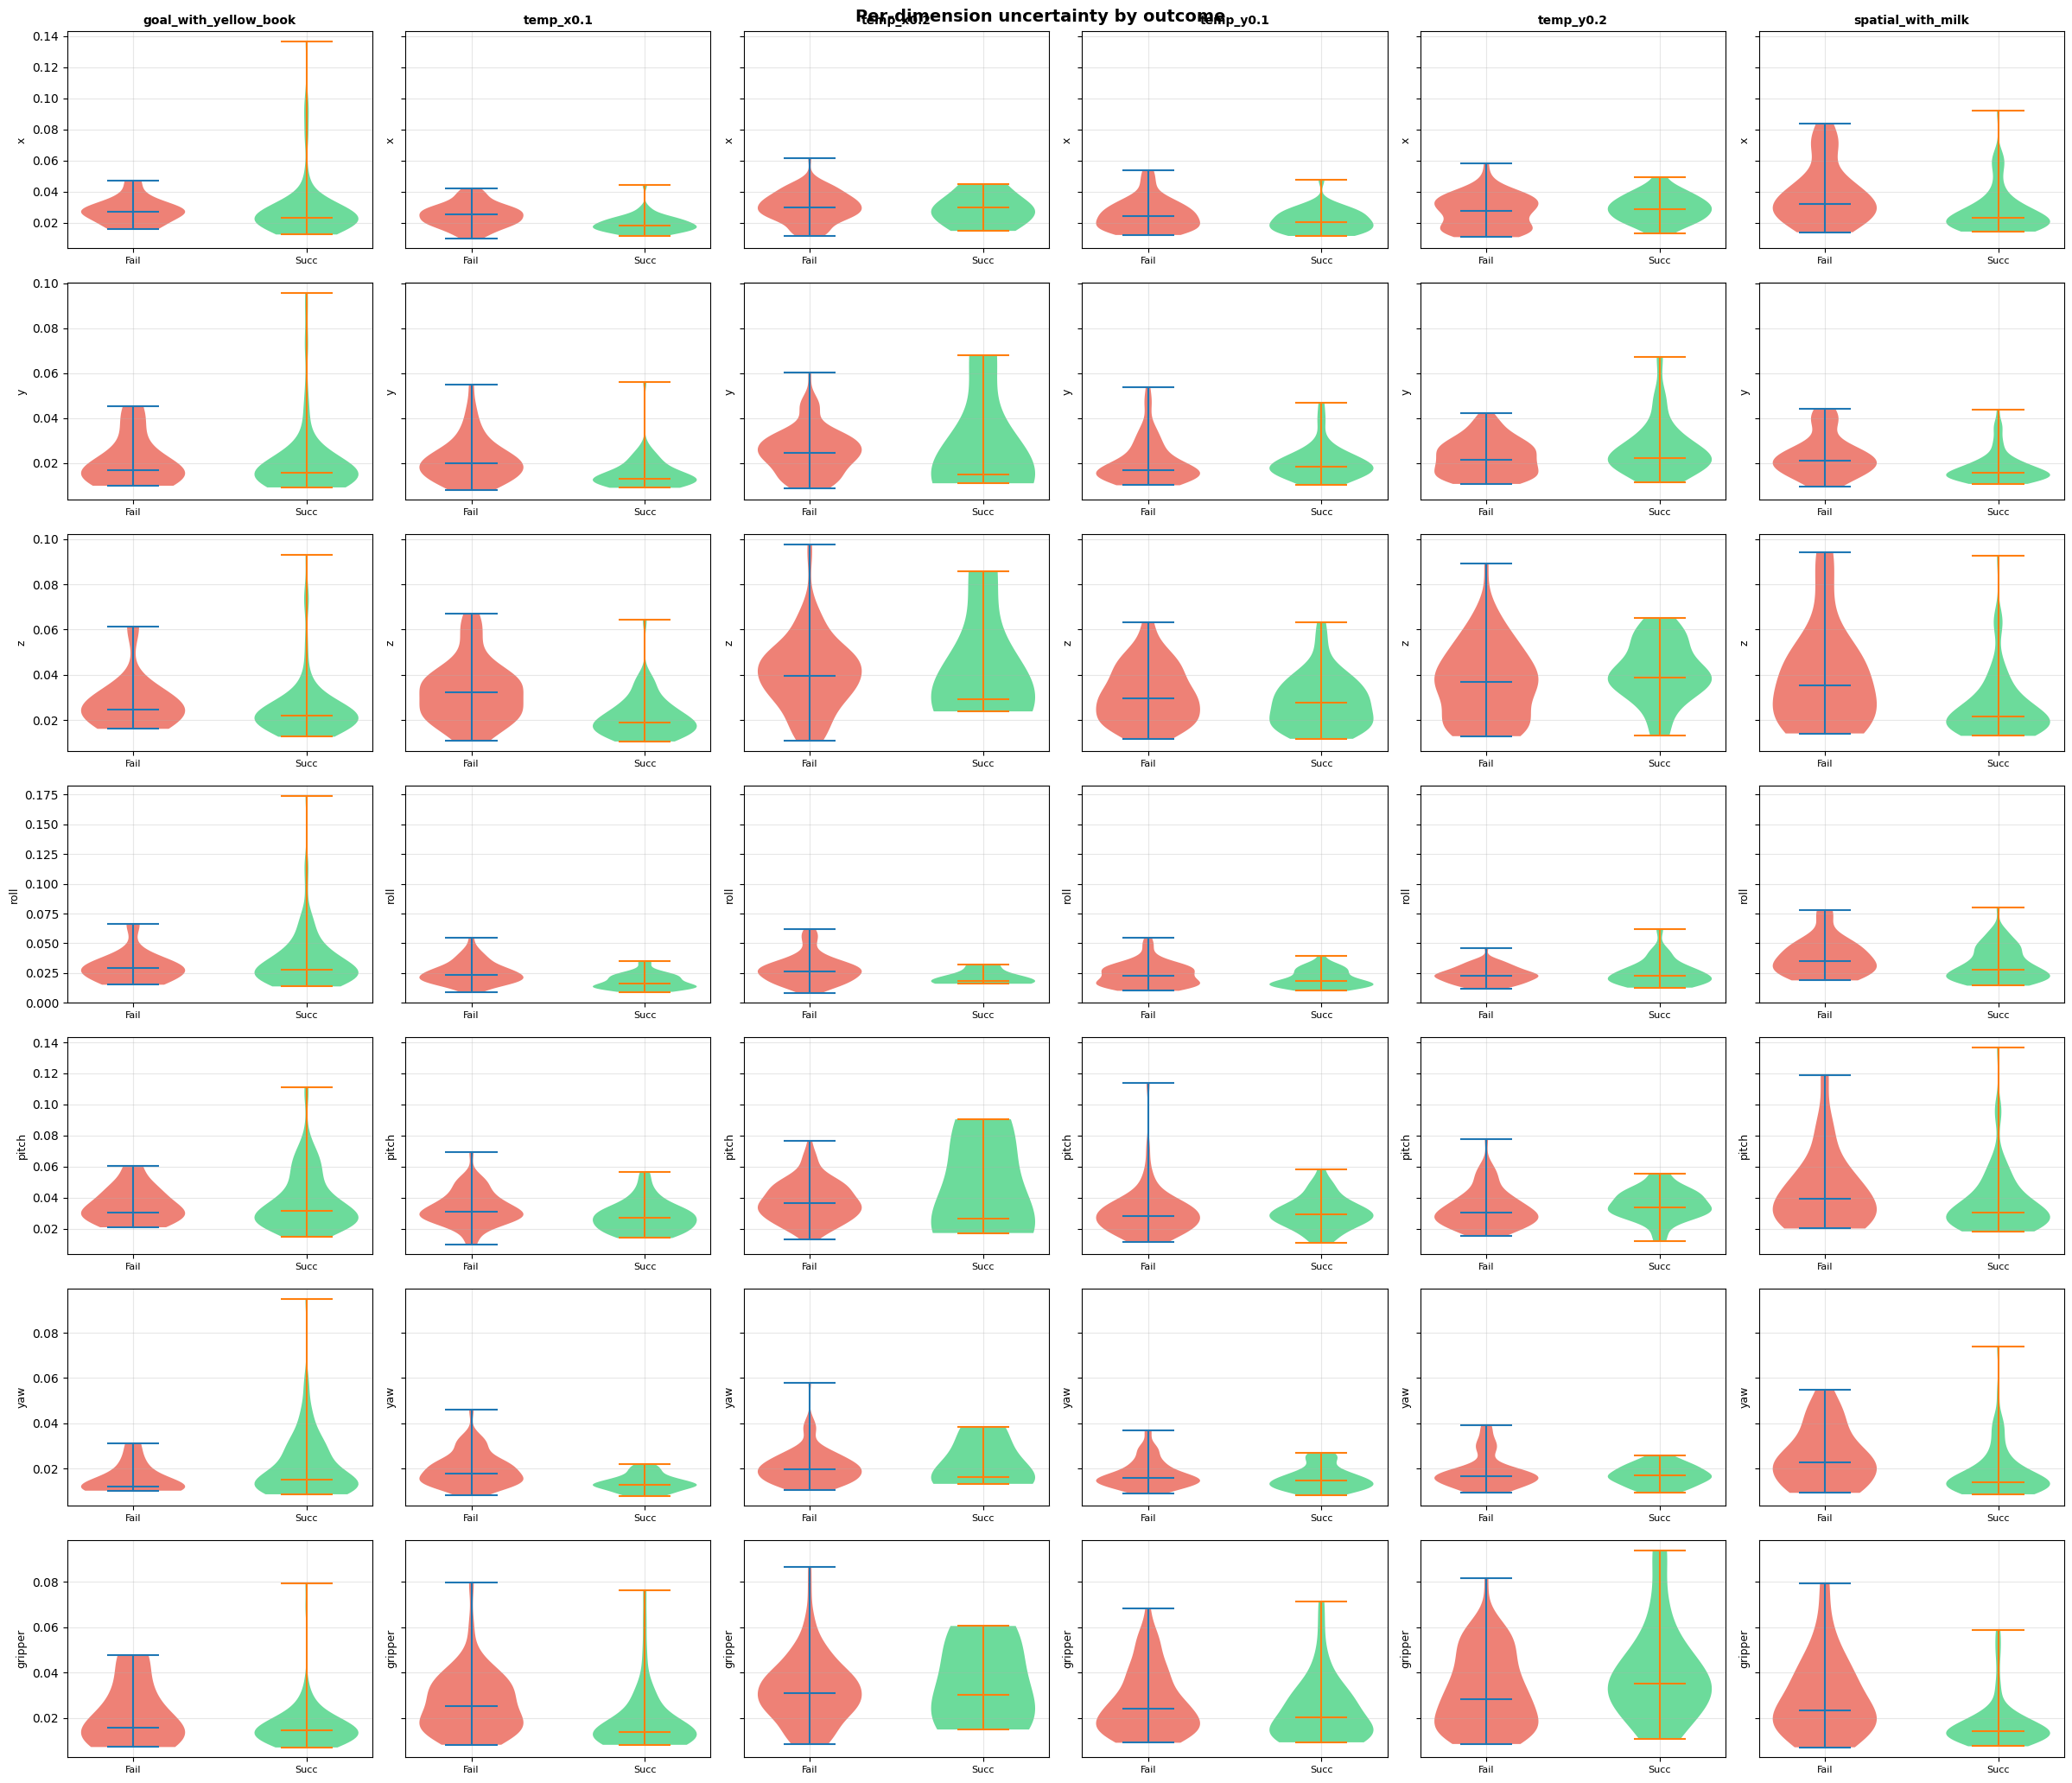

In [ ]:
# ── Plot 1: Per-dim uncertainty by outcome (violin) per suite ─────────────────
SUITES = sorted(paired['suite'].unique())
n_suites = len(SUITES)

fig, axes = plt.subplots(N_DIMS, n_suites,
                          figsize=(4*n_suites, 3*N_DIMS),
                          sharey='row')
fig.suptitle('Per-dimension uncertainty by outcome', fontsize=14, fontweight='bold')

for j, suite in enumerate(SUITES):
    s = paired[paired.suite == suite]
    short = suite.replace('libero_','').replace('object_','')
    failures  = s[s.base_success == 0]
    successes = s[s.base_success == 1]

    for i, dim in enumerate(DIM_NAMES):
        ax = axes[i, j]
        col = f'u_{dim}'
        data_f = failures[col].dropna().values
        data_s = successes[col].dropna().values

        parts_f = ax.violinplot([data_f], positions=[0],
                                showmedians=True, widths=0.6)
        parts_s = ax.violinplot([data_s], positions=[1],
                                showmedians=True, widths=0.6)
        for pc in parts_f['bodies']: pc.set_facecolor('#e74c3c'); pc.set_alpha(0.7)
        for pc in parts_s['bodies']: pc.set_facecolor('#2ecc71'); pc.set_alpha(0.7)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Fail', 'Succ'], fontsize=8)
        ax.set_ylabel(dim, fontsize=9)
        if i == 0:
            ax.set_title(short, fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/dim_uncertainty_violin.png',
            dpi=120, bbox_inches='tight')
plt.show()

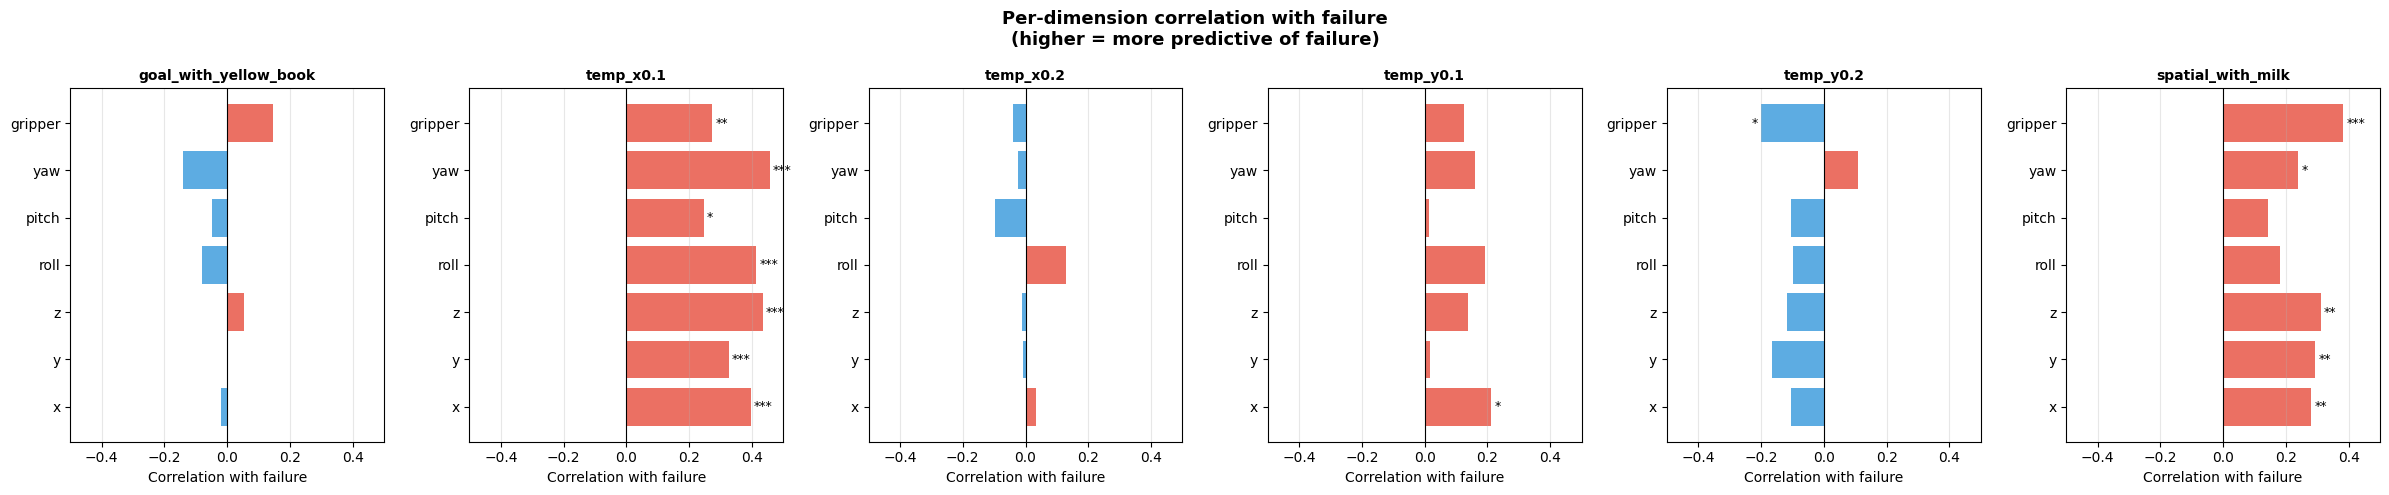

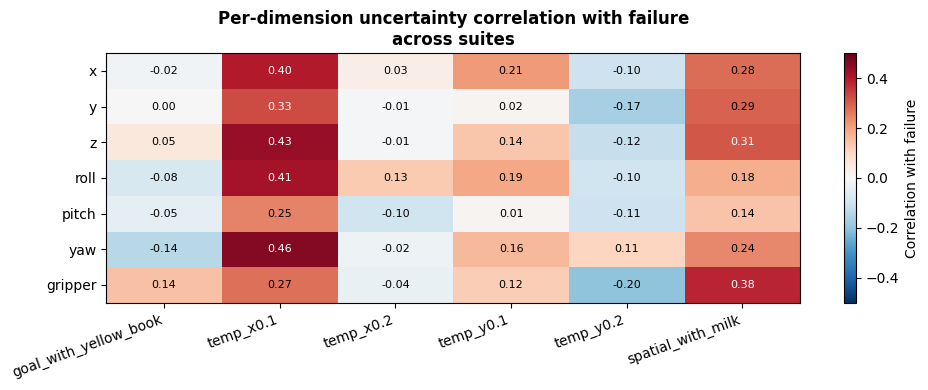

In [ ]:
# ── Plot 2: Per-dim correlation with failure (point-biserial r) ───────────────
from scipy import stats

fig, axes = plt.subplots(1, n_suites, figsize=(4*n_suites, 5))
fig.suptitle('Per-dimension correlation with failure\n(higher = more predictive of failure)',
             fontsize=13, fontweight='bold')

all_corrs = {}
for j, suite in enumerate(SUITES):
    s = paired[paired.suite == suite]
    short = suite.replace('libero_','').replace('object_','')
    corrs, pvals = [], []

    for dim in DIM_NAMES:
        col = f'u_{dim}'
        r, p = stats.pointbiserialr(1 - s['base_success'], s[col].fillna(0))
        corrs.append(r)
        pvals.append(p)

    all_corrs[suite] = corrs
    colors = ['#e74c3c' if r > 0 else '#3498db' for r in corrs]
    bars = axes[j].barh(DIM_NAMES, corrs, color=colors, alpha=0.8)
    axes[j].axvline(0, color='black', linewidth=0.8)
    axes[j].set_title(short, fontsize=10, fontweight='bold')
    axes[j].set_xlabel('Correlation with failure')
    axes[j].set_xlim(-0.5, 0.5)
    axes[j].grid(alpha=0.3, axis='x')

    # Mark significant dims
    for k, (r, p) in enumerate(zip(corrs, pvals)):
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if sig:
            axes[j].text(r + 0.01 if r >= 0 else r - 0.01, k, sig,
                         va='center', ha='left' if r >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/dim_correlation.png',
            dpi=120, bbox_inches='tight')
plt.show()

# ── Plot 3: Mean uncertainty per dim, normalized (heatmap across suites) ──────
import numpy as np

corr_matrix = np.array([all_corrs[suite] for suite in SUITES])
short_names = [s.replace('libero_','').replace('object_','') for s in SUITES]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(corr_matrix.T, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlation with failure')
ax.set_xticks(range(n_suites))
ax.set_xticklabels(short_names, rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(N_DIMS))
ax.set_yticklabels(DIM_NAMES, fontsize=10)
ax.set_title('Per-dimension uncertainty correlation with failure\nacross suites',
             fontsize=12, fontweight='bold')

# Annotate cells
for i in range(n_suites):
    for j in range(N_DIMS):
        ax.text(i, j, f'{corr_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr_matrix[i,j]) > 0.3 else 'black')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/dim_correlation_heatmap.png',
            dpi=120, bbox_inches='tight')
plt.show()

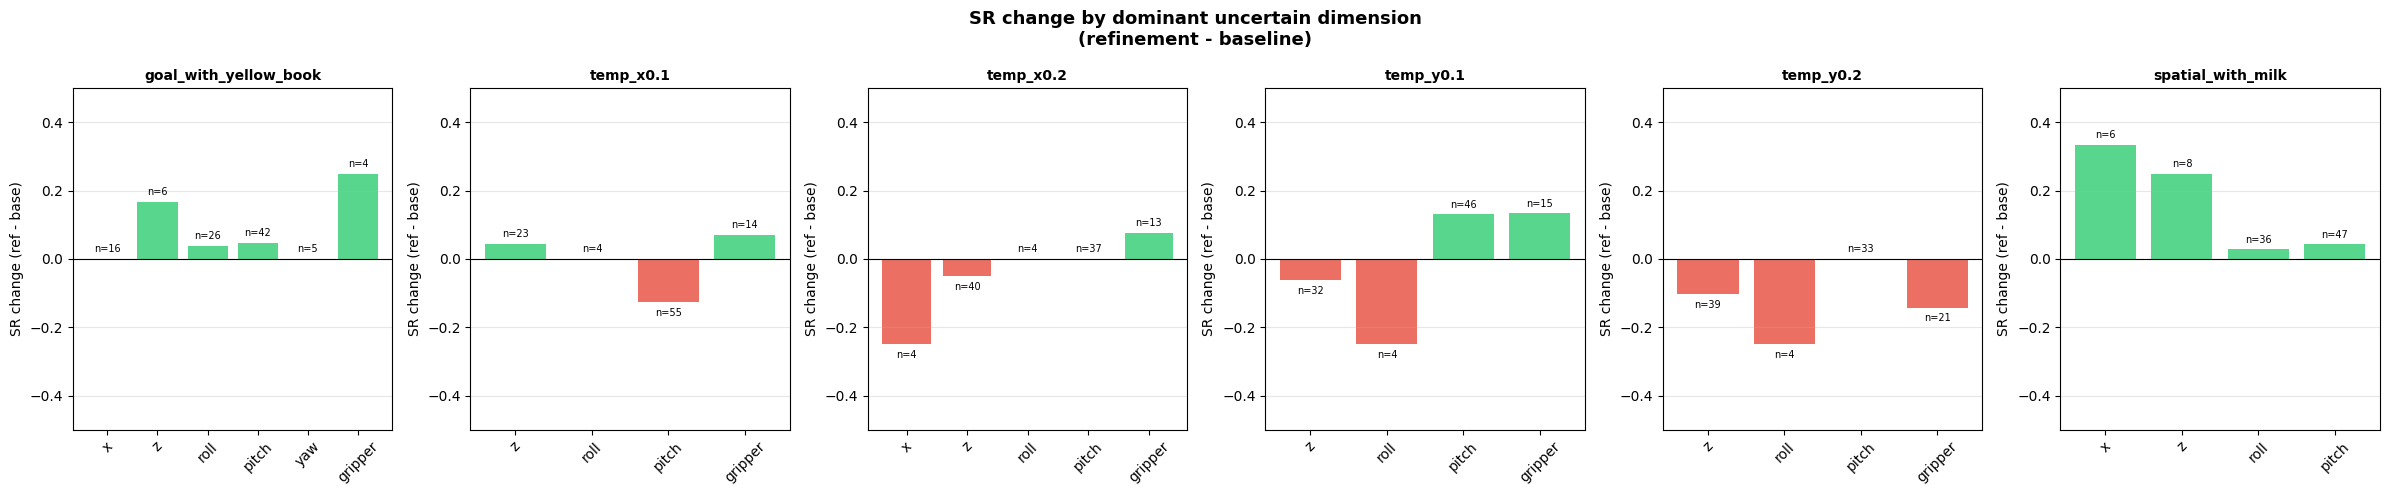

In [ ]:
# ── Plot 4: SR change by dominant uncertain dimension ─────────────────────────
ref = df[(df.pnp_enabled==1)&(df.pnp_mode=='both')]\
        [['suite','task_idx','episode_idx','init_state_hash','success']]\
        .rename(columns={'success':'ref_success'})

paired_full = paired.merge(ref, on=['suite','task_idx','episode_idx','init_state_hash'],
                            how='inner')

# Find dominant uncertain dimension per episode
u_cols = [f'u_{d}' for d in DIM_NAMES]
paired_full['dominant_dim'] = paired_full[u_cols].idxmax(axis=1)\
                                                   .str.replace('u_','')

fig, axes = plt.subplots(1, n_suites, figsize=(4*n_suites, 5))
fig.suptitle('SR change by dominant uncertain dimension\n(refinement - baseline)',
             fontsize=13, fontweight='bold')

for j, suite in enumerate(SUITES):
    s = paired_full[paired_full.suite == suite]
    short = suite.replace('libero_','').replace('object_','')

    sr_changes, ns, dims_present = [], [], []
    for dim in DIM_NAMES:
        grp = s[s.dominant_dim == dim]
        if len(grp) < 3:
            continue
        sr_change = grp.ref_success.mean() - grp.base_success.mean()
        sr_changes.append(sr_change)
        ns.append(len(grp))
        dims_present.append(dim)

    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sr_changes]
    bars = axes[j].bar(dims_present, sr_changes, color=colors, alpha=0.8)
    axes[j].axhline(0, color='black', linewidth=0.8)
    axes[j].set_title(short, fontsize=10, fontweight='bold')
    axes[j].set_ylabel('SR change (ref - base)')
    axes[j].set_ylim(-0.5, 0.5)
    axes[j].grid(alpha=0.3, axis='y')
    axes[j].tick_params(axis='x', rotation=45)

    for bar, n in zip(bars, ns):
        axes[j].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02 if bar.get_height() >= 0
                     else bar.get_height() - 0.04,
                     f'n={n}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/dim_sr_change.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Try removing pitch, roll, yaw

Paired episodes: 600

Suite                                     AUC (7-dim)  AUC (pos+grip)    Diff
------------------------------------------------------------------------------
goal_with_yellow_book                           0.569           0.698  +0.129
temp_x0.1                                       0.778           0.767  -0.011
temp_x0.2                                       0.562           0.577  +0.015
temp_y0.1                                       0.558           0.571  +0.013
temp_y0.2                                       0.406           0.396  -0.010
spatial_with_milk                               0.693           0.742  +0.049


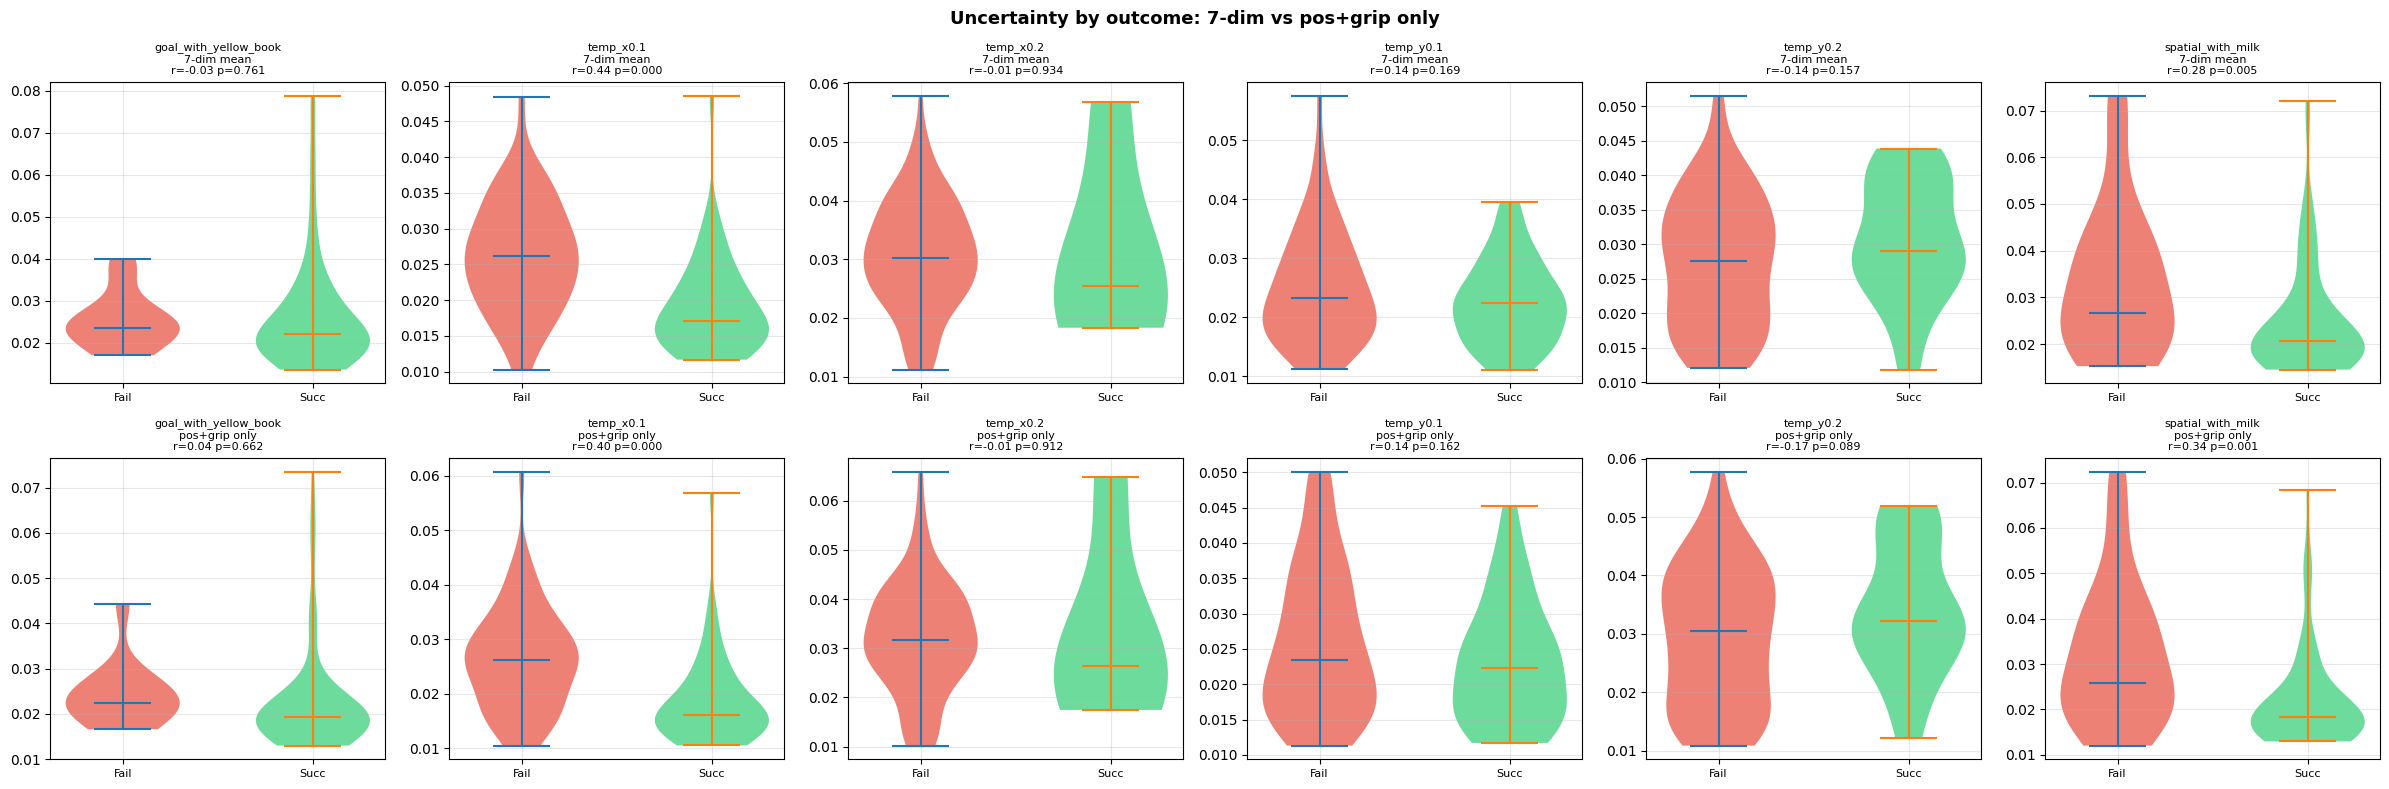

In [5]:
import sqlite3, numpy as np, pandas as pd, json
from scipy import stats
import matplotlib.pyplot as plt

DB_PATH_JEFF = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db'
con = sqlite3.connect(DB_PATH_JEFF)
df = pd.read_sql('SELECT * FROM rollouts', con)
vec_df = pd.read_sql('SELECT * FROM pnp_action_vectors', con)
con.close()

vec_df['u_vec'] = vec_df['u_vec'].apply(json.loads)

DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']
POS_GRIP_DIMS = [0, 1, 2, 6]  # x, y, z, gripper only

# Compute per-rollout mean uncertainty for pos+grip dims only
for i, dim in enumerate(DIM_NAMES):
    vec_df[f'u_{dim}'] = vec_df['u_vec'].apply(lambda v: v[i] if len(v) > i else np.nan)

vec_df['u_pos_grip'] = vec_df[[f'u_{DIM_NAMES[i]}' for i in POS_GRIP_DIMS]].mean(axis=1)

rollout_u = vec_df.groupby('rollout_id')[['u_pos_grip'] +
                                          [f'u_{d}' for d in DIM_NAMES]].mean().reset_index()

# Merge with outcomes
base = df[df.pnp_enabled==0][['rollout_id','suite','task_idx','episode_idx',
                               'init_state_hash','success']]\
         .rename(columns={'success':'base_success'})
unc  = df[(df.pnp_enabled==1)&(df.pnp_mode=='uncertainty')]\
         [['rollout_id','suite','task_idx','episode_idx','init_state_hash','u_mean_episode']]\
         .rename(columns={'rollout_id':'unc_rollout_id'})

rollout_u_r = rollout_u.rename(columns={'rollout_id':'unc_rollout_id'})
unc_with_u  = unc.merge(rollout_u_r, on='unc_rollout_id', how='inner')
paired      = base.merge(unc_with_u,
                         on=['suite','task_idx','episode_idx','init_state_hash'],
                         how='inner')

print(f'Paired episodes: {len(paired)}')

# ── Compare AUC: full 7-dim vs pos+grip only ──────────────────────────────────
from sklearn.metrics import roc_auc_score

SUITES = sorted(paired['suite'].unique())
print(f'\n{"Suite":<40} {"AUC (7-dim)":>12} {"AUC (pos+grip)":>15}  {"Diff":>6}')
print('-' * 78)

for suite in SUITES:
    s = paired[paired.suite == suite].dropna(subset=['u_pos_grip','u_mean_episode'])
    if len(s) < 10: continue

    # Use existing u_mean_episode as 7-dim aggregate
    auc_full = roc_auc_score(1 - s['base_success'], s['u_mean_episode'])
    auc_pg   = roc_auc_score(1 - s['base_success'], s['u_pos_grip'])
    diff     = auc_pg - auc_full
    short    = suite.replace('libero_','').replace('object_','')
    print(f'{short:<40} {auc_full:>12.3f} {auc_pg:>15.3f}  {diff:>+6.3f}')

# ── Violin comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, len(SUITES), figsize=(4*len(SUITES), 8))
fig.suptitle('Uncertainty by outcome: 7-dim vs pos+grip only',
             fontsize=13, fontweight='bold')

for j, suite in enumerate(SUITES):
    s = paired[paired.suite == suite]
    short = suite.replace('libero_','').replace('object_','')
    failures  = s[s.base_success == 0]
    successes = s[s.base_success == 1]

    for row, col, title in [(0, 'u_mean_episode', '7-dim mean'),
                             (1, 'u_pos_grip',    'pos+grip only')]:
        ax = axes[row, j]
        data_f = failures[col].dropna().values
        data_s = successes[col].dropna().values
        if len(data_f) == 0 or len(data_s) == 0:
            continue
        parts_f = ax.violinplot([data_f], positions=[0], showmedians=True, widths=0.6)
        parts_s = ax.violinplot([data_s], positions=[1], showmedians=True, widths=0.6)
        for pc in parts_f['bodies']: pc.set_facecolor('#e74c3c'); pc.set_alpha(0.7)
        for pc in parts_s['bodies']: pc.set_facecolor('#2ecc71'); pc.set_alpha(0.7)
        r, p = stats.pointbiserialr(1 - s['base_success'], s[col].fillna(0))
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Fail', 'Succ'], fontsize=8)
        ax.set_title(f'{short}\n{title}\nr={r:.2f} p={p:.3f}', fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/uncertainty_pos_grip_comparison.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Try sweeping through different combinations of features, return the most promising violin plots (in terms of AUC)

Top 20 dimension subsets by overall AUC:
Dims                                            N  Overall  goal_with_ye     temp_x0.1     temp_x0.2     temp_y0.1     temp_y0.2  spatial_with
------------------------------------------------------------------------------------------------------------------------------------------------
gripper                                         1    0.704         0.575         0.725         0.472         0.595         0.384         0.762
z+gripper                                       2    0.700         0.645         0.766         0.531         0.589         0.391         0.745
z+yaw+gripper                                   3    0.692         0.565         0.796         0.531         0.596         0.412         0.745
y+z+gripper                                     3    0.691         0.668         0.770         0.575         0.558         0.387         0.743
y+gripper                                       2    0.687         0.655         0.749         0.55

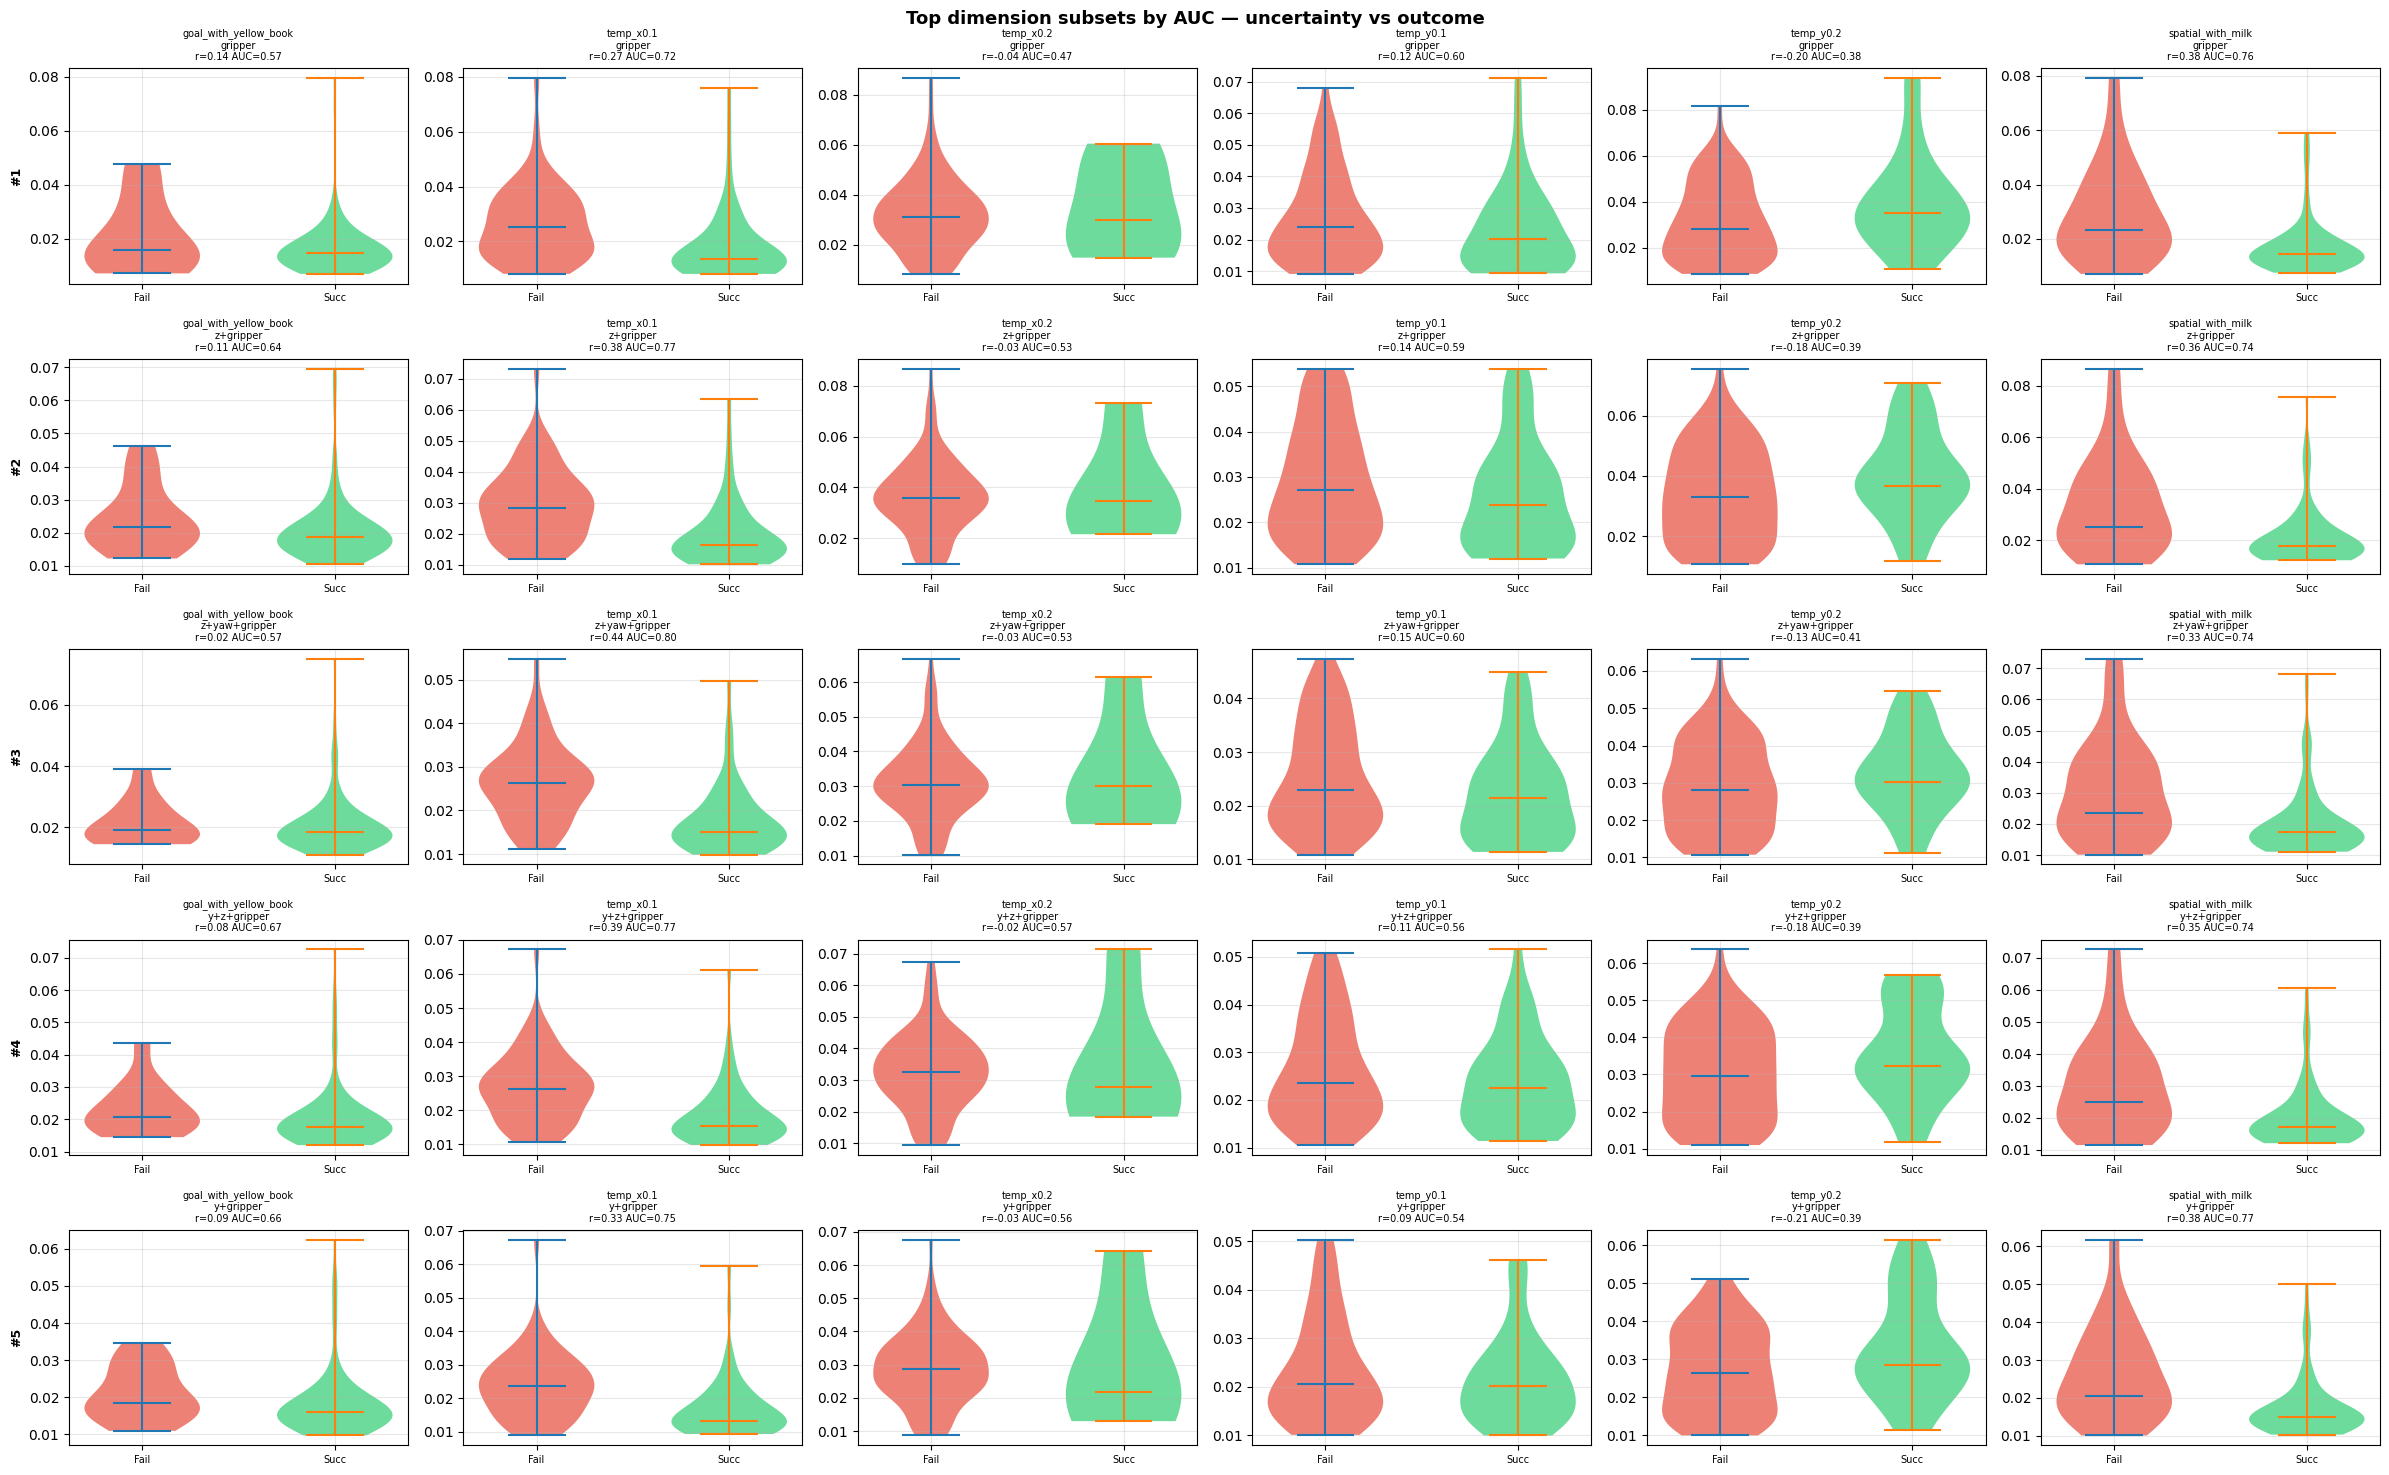

In [10]:
from itertools import combinations
from sklearn.metrics import roc_auc_score
from scipy import stats
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']

def short_name(suite):
    return suite.replace('libero_','').replace('object_','')

SUITES = sorted(paired['suite'].unique())

# ── Sweep all subsets ─────────────────────────────────────────────────────────
results = []
for r in range(1, 8):
    for combo in combinations(range(7), r):
        dims = [DIM_NAMES[i] for i in combo]
        col_name = '+'.join(dims)

        paired[col_name] = paired[[f'u_{d}' for d in dims]].mean(axis=1)

        suite_aucs = {}
        all_true, all_scores = [], []
        for suite in SUITES:
            s = paired[paired.suite == suite].dropna(subset=[col_name, 'base_success'])
            if len(s) < 10: continue
            try:
                auc = roc_auc_score(1 - s['base_success'], s[col_name])
                suite_aucs[suite] = auc
                all_true.extend((1 - s['base_success']).tolist())
                all_scores.extend(s[col_name].tolist())
            except:
                continue

        if len(all_true) < 10: continue
        overall_auc = roc_auc_score(all_true, all_scores)

        row = {
            'dims': dims,
            'n_dims': len(dims),
            'col': col_name,
            'overall_auc': overall_auc,
        }
        for suite in SUITES:
            row[f'auc_{short_name(suite)}'] = suite_aucs.get(suite, np.nan)
        results.append(row)

results_df = pd.DataFrame(results).sort_values('overall_auc', ascending=False)

# ── Print top 20 ──────────────────────────────────────────────────────────────
print('Top 20 dimension subsets by overall AUC:')
header = f'{"Dims":<45} {"N":>3} {"Overall":>8}'
for suite in SUITES:
    header += f'  {short_name(suite)[:12]:>12}'
print(header)
print('-' * (45 + 3 + 8 + len(SUITES) * 14 + 4))

for _, row in results_df.head(20).iterrows():
    line = f'{row.col:<45} {row.n_dims:>3} {row.overall_auc:>8.3f}'
    for suite in SUITES:
        val = row.get(f'auc_{short_name(suite)}', np.nan)
        line += f'  {val:>12.3f}'
    print(line)

# ── Plot top 5 violins ────────────────────────────────────────────────────────
TOP_N = 5
top_combos = results_df.head(TOP_N)

fig, axes = plt.subplots(TOP_N, len(SUITES),
                          figsize=(4*len(SUITES), 3*TOP_N))
fig.suptitle('Top dimension subsets by AUC — uncertainty vs outcome',
             fontsize=13, fontweight='bold')

for i, (_, row) in enumerate(top_combos.iterrows()):
    col = row.col
    for j, suite in enumerate(SUITES):
        ax = axes[i, j]
        s = paired[paired.suite == suite].dropna(subset=[col])
        short = short_name(suite)
        failures  = s[s.base_success == 0][col].values
        successes = s[s.base_success == 1][col].values

        if len(failures) > 1:
            parts_f = ax.violinplot([failures], positions=[0],
                                    showmedians=True, widths=0.6)
            for pc in parts_f['bodies']:
                pc.set_facecolor('#e74c3c'); pc.set_alpha(0.7)
        if len(successes) > 1:
            parts_s = ax.violinplot([successes], positions=[1],
                                    showmedians=True, widths=0.6)
            for pc in parts_s['bodies']:
                pc.set_facecolor('#2ecc71'); pc.set_alpha(0.7)

        r, p = stats.pointbiserialr(1 - s['base_success'], s[col].fillna(0))
        suite_auc = row.get(f'auc_{short}', np.nan)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Fail', 'Succ'], fontsize=7)
        ax.set_title(f'{short}\n{col[:25]}\nr={r:.2f} AUC={suite_auc:.2f}',
                     fontsize=7)
        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f'#{i+1}', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/dim_subset_sweep.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [8]:
for suite in SUITES:
    short = suite.replace('libero_','').replace('object_','')
    print(f'"{suite}" -> key: "auc_{short}"')

"libero_goal_with_yellow_book" -> key: "auc_goal_with_yellow_book"
"libero_object_temp_x0.1" -> key: "auc_temp_x0.1"
"libero_object_temp_x0.2" -> key: "auc_temp_x0.2"
"libero_object_temp_y0.1" -> key: "auc_temp_y0.1"
"libero_object_temp_y0.2" -> key: "auc_temp_y0.2"
"libero_spatial_with_milk" -> key: "auc_spatial_with_milk"


---
# Analysis (Old): Mean Uncertainty

The cells below are self-contained and read entirely from `rollouts.db`.
They can be re-run at any time — even on a new Colab session — as long as the DB is mounted.

Rewrite to new file because something got messed up

In [ ]:
# # For each suite, keep only the 100 most recent baseline rows
# # and all phase 2/3 rows
# import sqlite3, os

# MY_SUITES = [
#     'libero_object_temp_x0.1',
#     'libero_object_temp_y0.1',
#     'libero_object_temp_x0.2',
#     'libero_object_temp_y0.2',
#     'libero_spatial_with_milk',
#     'libero_goal_with_yellow_book',
# ]

# NEW_DB_PATH = '/content/drive/MyDrive/libero_pro_results/rollouts_jeff.db'
# if os.path.exists(NEW_DB_PATH):
#     os.remove(NEW_DB_PATH)

# old_con = sqlite3.connect('/content/drive/MyDrive/libero_pro_results/rollouts.db')
# new_con = sqlite3.connect(NEW_DB_PATH)

# # Copy schema
# for line in old_con.iterdump():
#     if line.startswith('INSERT'):
#         continue
#     try:
#         new_con.execute(line)
#     except:
#         pass
# new_con.commit()

# # For baseline: take the 100 most recent rows per suite
# placeholders = ','.join('?' for _ in MY_SUITES)
# baseline_rows = []
# for suite in MY_SUITES:
#     rows = old_con.execute("""
#         SELECT * FROM rollouts
#         WHERE suite = ? AND pnp_enabled = 0
#         AND timestamp >= '2026-06-06'
#         ORDER BY timestamp DESC
#         LIMIT 100
#     """, (suite,)).fetchall()
#     baseline_rows.extend(rows)
#     print(f'  Baseline {suite}: {len(rows)} rows')

# # For phases 2 and 3: take all rows
# pnp_rows = old_con.execute(f"""
#     SELECT * FROM rollouts
#     WHERE suite IN ({placeholders})
#     AND pnp_enabled = 1
#     AND timestamp >= '2026-06-06'
# """, MY_SUITES).fetchall()
# print(f'  Phase 2+3: {len(pnp_rows)} rows')

# all_rows = baseline_rows + pnp_rows
# if all_rows:
#     new_con.executemany(
#         f'INSERT OR REPLACE INTO rollouts VALUES ({",".join("?" for _ in all_rows[0])})',
#         all_rows
#     )
# new_con.commit()

# # Copy matching euler steps
# rollout_ids = [r[0] for r in all_rows]
# if rollout_ids:
#     placeholders2 = ','.join('?' for _ in rollout_ids)
#     step_rows = old_con.execute(f"""
#         SELECT * FROM pnp_euler_steps
#         WHERE rollout_id IN ({placeholders2})
#     """, rollout_ids).fetchall()
#     if step_rows:
#         new_con.executemany(
#             f'INSERT INTO pnp_euler_steps VALUES ({",".join("?" for _ in step_rows[0])})',
#             step_rows
#         )
#         new_con.commit()
#         print(f'  Euler step rows: {len(step_rows)}')
#     else:
#         print('  No euler step rows found.')

# old_con.close()
# new_con.close()

# # Verify
# verify = sqlite3.connect(NEW_DB_PATH)
# print('\nVerification:')
# for suite, pnp_enabled, pnp_mode, cnt in verify.execute("""
#     SELECT suite, pnp_enabled, pnp_mode, COUNT(*)
#     FROM rollouts
#     GROUP BY suite, pnp_enabled, pnp_mode
#     ORDER BY suite, pnp_enabled
# """).fetchall():
#     phase = 'baseline' if not pnp_enabled else pnp_mode
#     print(f'  {suite:<45} {phase:<12} n={cnt}')
# verify.close()
# print(f'\nNew DB: {NEW_DB_PATH}')

  Baseline libero_object_temp_x0.1: 100 rows
  Baseline libero_object_temp_y0.1: 100 rows
  Baseline libero_object_temp_x0.2: 100 rows
  Baseline libero_object_temp_y0.2: 100 rows
  Baseline libero_spatial_with_milk: 100 rows
  Baseline libero_goal_with_yellow_book: 100 rows
  Phase 2+3: 1212 rows
  Euler step rows: 144

Verification:
  libero_goal_with_yellow_book                  baseline     n=100
  libero_goal_with_yellow_book                  both         n=100
  libero_goal_with_yellow_book                  uncertainty  n=100
  libero_object_temp_x0.1                       baseline     n=100
  libero_object_temp_x0.1                       both         n=100
  libero_object_temp_x0.1                       uncertainty  n=112
  libero_object_temp_x0.2                       baseline     n=100
  libero_object_temp_x0.2                       both         n=100
  libero_object_temp_x0.2                       uncertainty  n=100
  libero_object_temp_y0.1                       baseline    

## A1. Load & Summarise Database

In [ ]:
import sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Connect (works whether we are continuing this session or loading a saved DB)
RESULTS_DIR = '/content/drive/MyDrive/cs159_jeff/libero_pro_results'
DB_PATH     = f'{RESULTS_DIR}/rollouts_jeff_dimensional.db'
con_a       = sqlite3.connect(DB_PATH)
con_a.row_factory = sqlite3.Row

rollouts = pd.read_sql('SELECT * FROM rollouts', con_a)
steps_df = pd.read_sql('SELECT * FROM pnp_euler_steps', con_a)

# Parse JSON step indices
def _parse_idx(s):
    try:    return json.loads(s)
    except: return s
rollouts['step_indices_parsed'] = rollouts['pnp_step_indices'].map(_parse_idx)

# Phase splits
baseline = rollouts[rollouts.pnp_enabled == 0].copy()
pnp_all  = rollouts[rollouts.pnp_enabled == 1].copy()
phase2   = pnp_all[pnp_all['pnp_mode'] == 'uncertainty'].copy()
phase3   = pnp_all[pnp_all['pnp_mode'] == 'both'].copy()

steps_p2 = steps_df[steps_df['rollout_id'].isin(set(phase2['rollout_id']))].copy()
steps_p3 = steps_df[steps_df['rollout_id'].isin(set(phase3['rollout_id']))].copy()

# Suite type annotation
def suite_type(s):
    if 'temp_' in s:  return 'position_perturb'
    if '_with_' in s: return 'distractor'
    return 'other'
for df in [rollouts, baseline, pnp_all, phase2, phase3]:
    df['suite_type'] = df['suite'].map(suite_type)

print(f'Total rollouts: {len(rollouts)}')
print(f'  Baseline (phase 1): {len(baseline)}')
print(f'  Uncertainty only (phase 2): {len(phase2)}')
print(f'  Refinement (phase 3): {len(phase3)}')
print(f'  Euler steps rows: {len(steps_df)}')
print()
print('Suites in DB:', sorted(rollouts.suite.unique().tolist()))
print()
print('Baseline SR per suite:')
for suite, grp in baseline.groupby('suite'):
    print(f'  {suite:<45} {grp.success.mean():.1%}  (n={len(grp)})')

Total rollouts: 1800
  Baseline (phase 1): 600
  Uncertainty only (phase 2): 600
  Refinement (phase 3): 600
  Euler steps rows: 10960

Suites in DB: ['libero_goal_with_yellow_book', 'libero_object_temp_x0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_spatial_with_milk']

Baseline SR per suite:
  libero_goal_with_yellow_book                  88.0%  (n=100)
  libero_object_temp_x0.1                       50.0%  (n=100)
  libero_object_temp_x0.2                       5.0%  (n=100)
  libero_object_temp_y0.1                       42.0%  (n=100)
  libero_object_temp_y0.2                       27.0%  (n=100)
  libero_spatial_with_milk                      77.0%  (n=100)


## A2. Baseline Success Rate — Per Suite & Per Task

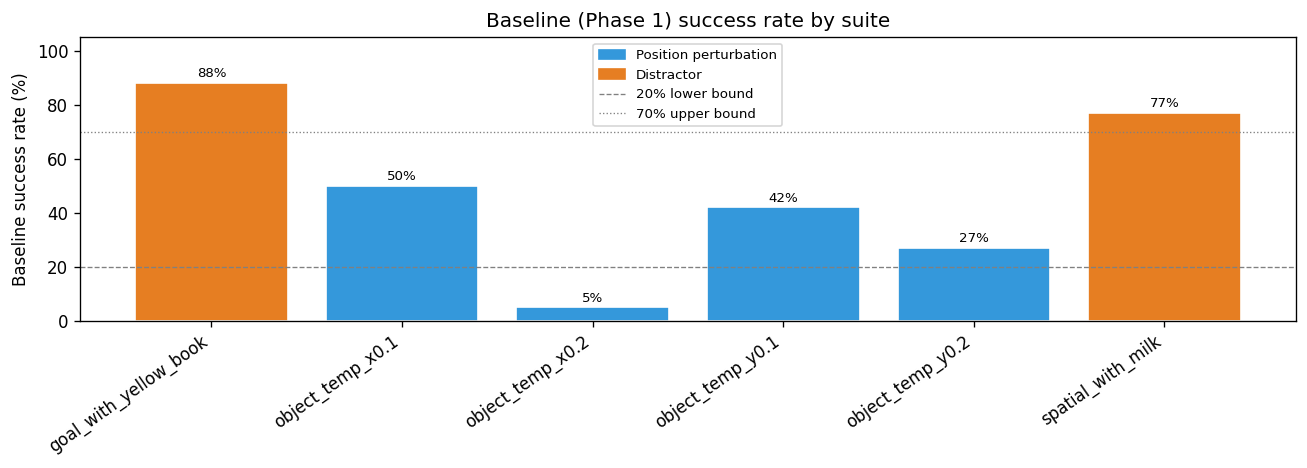

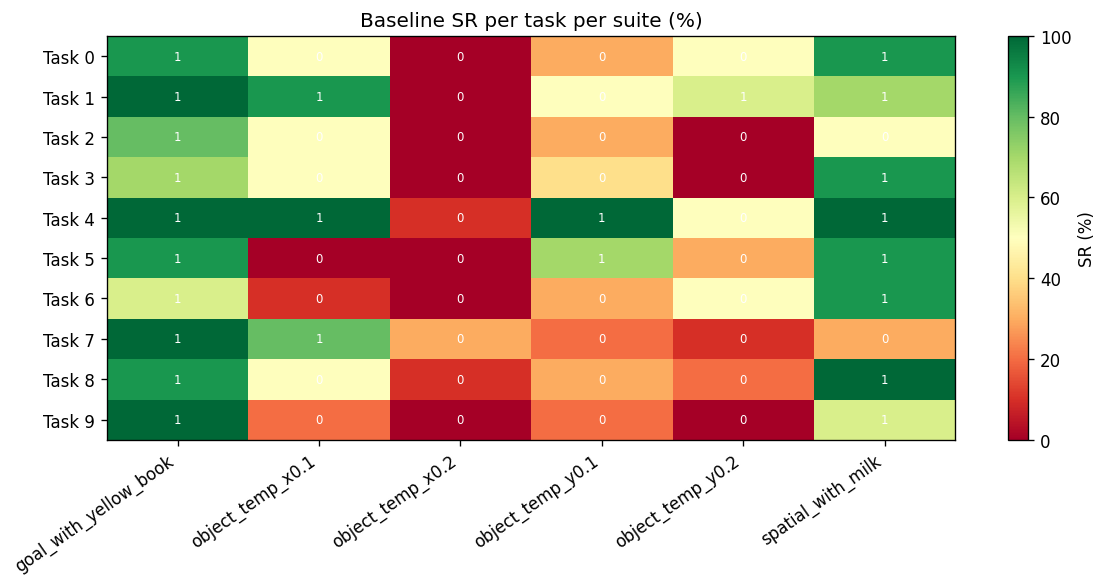

In [ ]:
suites = sorted(baseline['suite'].unique())
suite_sr = baseline.groupby('suite')['success'].mean()

# ── Suite-level bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#3498db' if 'temp_' in s else '#e67e22' for s in suite_sr.index]
bars = ax.bar(range(len(suite_sr)), suite_sr.values * 100, color=colors, edgecolor='white')
ax.axhline(20, color='gray', ls='--', lw=0.8, label='20% lower bound')
ax.axhline(70, color='gray', ls=':',  lw=0.8, label='70% upper bound')
ax.set_xticks(range(len(suite_sr)))
ax.set_xticklabels([s.replace('libero_','') for s in suite_sr.index], rotation=35, ha='right')
ax.set_ylabel('Baseline success rate (%)')
ax.set_ylim(0, 105)
ax.set_title('Baseline (Phase 1) success rate by suite')
for bar, v in zip(bars, suite_sr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.0%}', ha='center', va='bottom', fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#3498db', label='Position perturbation'),
    Patch(color='#e67e22', label='Distractor'),
] + ax.get_legend_handles_labels()[0], fontsize=8)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/baseline_sr_by_suite.png', dpi=150)
plt.show()

# ── Per-task heatmap ─────────────────────────────────────────────────────────
per_task_sr = (
    baseline.groupby(['suite', 'task_idx'])['success']
    .mean().unstack(level='suite').fillna(float('nan'))
)
fig, ax = plt.subplots(figsize=(max(10, len(suites) * 1.2), 5))
im = ax.imshow(per_task_sr.values * 100, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=100)
ax.set_xticks(range(len(suites)))
ax.set_xticklabels([s.replace('libero_','') for s in per_task_sr.columns],
                   rotation=35, ha='right')
ax.set_yticks(range(len(per_task_sr)))
ax.set_yticklabels([f'Task {i}' for i in per_task_sr.index])
ax.set_title('Baseline SR per task per suite (%)')
plt.colorbar(im, ax=ax, label='SR (%)')
for i in range(per_task_sr.shape[0]):
    for j in range(per_task_sr.shape[1]):
        v = per_task_sr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                    color='black' if 30 < v < 80 else 'white')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/baseline_sr_heatmap.png', dpi=150)
plt.show()

## A3. Phase Comparison — Baseline vs. Uncertainty vs. Refinement

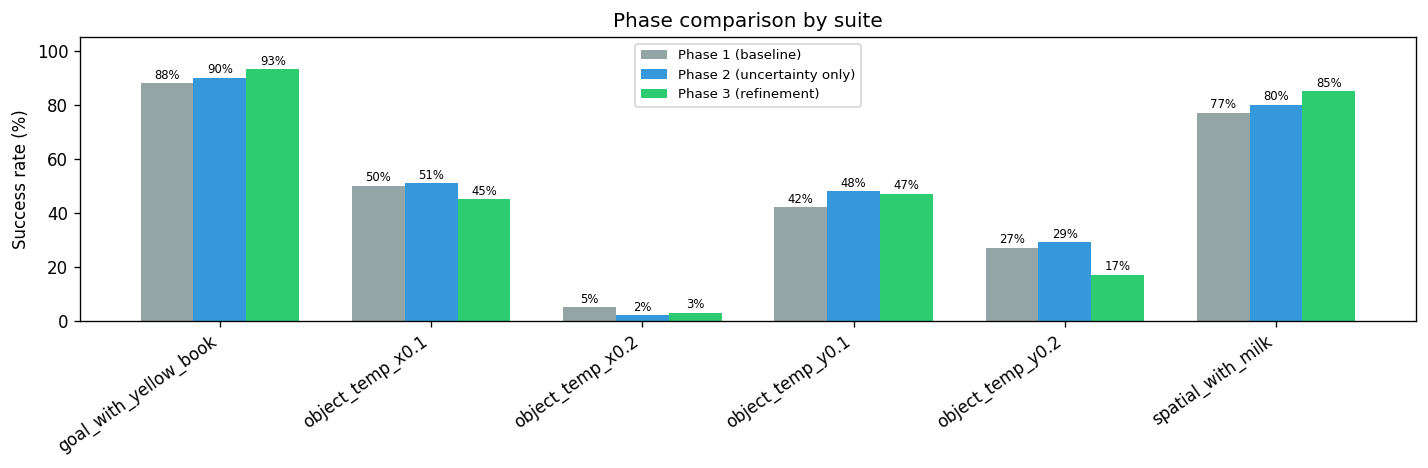

In [ ]:
if len(phase2) == 0 and len(phase3) == 0:
    print('No P&P data yet — run phases 2 and 3 first.')
else:
    suites = sorted(set(
        baseline['suite'].tolist() + phase2['suite'].tolist() + phase3['suite'].tolist()
    ))
    x  = np.arange(len(suites))
    w  = 0.25
    sr_base = baseline.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr_p2   = phase2.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr_p3   = phase3.groupby('suite')['success'].mean().reindex(suites).fillna(0)

    fig, ax = plt.subplots(figsize=(12, 4))
    b1 = ax.bar(x - w, sr_base * 100, width=w, label='Phase 1 (baseline)',           color='#95a5a6')
    b2 = ax.bar(x,     sr_p2   * 100, width=w, label='Phase 2 (uncertainty only)',   color='#3498db')
    b3 = ax.bar(x + w, sr_p3   * 100, width=w, label='Phase 3 (refinement)',         color='#2ecc71')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=35, ha='right')
    ax.set_ylabel('Success rate (%)')
    ax.set_ylim(0, 105)
    ax.set_title('Phase comparison by suite')
    ax.legend(fontsize=8)
    for bars_patch, vals in [(b1, sr_base), (b2, sr_p2), (b3, sr_p3)]:
        for bar, v in zip(bars_patch, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v*100:.0f}%', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/phase_comparison.png', dpi=150)
    plt.show()

## A4. Paired Episode Transition Analysis
For each episode, compares baseline outcome to P&P outcome (same `init_state_hash`).

Paired episodes: 600

Overall transition counts:
transition
failure → failure       252
success → success       231
failure → success  ✓     59
success → failure  ✗     58

Baseline SR:   48.2%
Refinement SR: 48.3%

Per-suite transitions:
  libero_goal_with_yellow_book               base=88%  pnp=93%  F→S=9  S→F=4
  libero_object_temp_x0.1                    base=50%  pnp=45%  F→S=12  S→F=17
  libero_object_temp_x0.2                    base=5%  pnp=3%  F→S=2  S→F=4
  libero_object_temp_y0.1                    base=42%  pnp=47%  F→S=19  S→F=14
  libero_object_temp_y0.2                    base=27%  pnp=17%  F→S=4  S→F=14
  libero_spatial_with_milk                   base=77%  pnp=85%  F→S=13  S→F=5


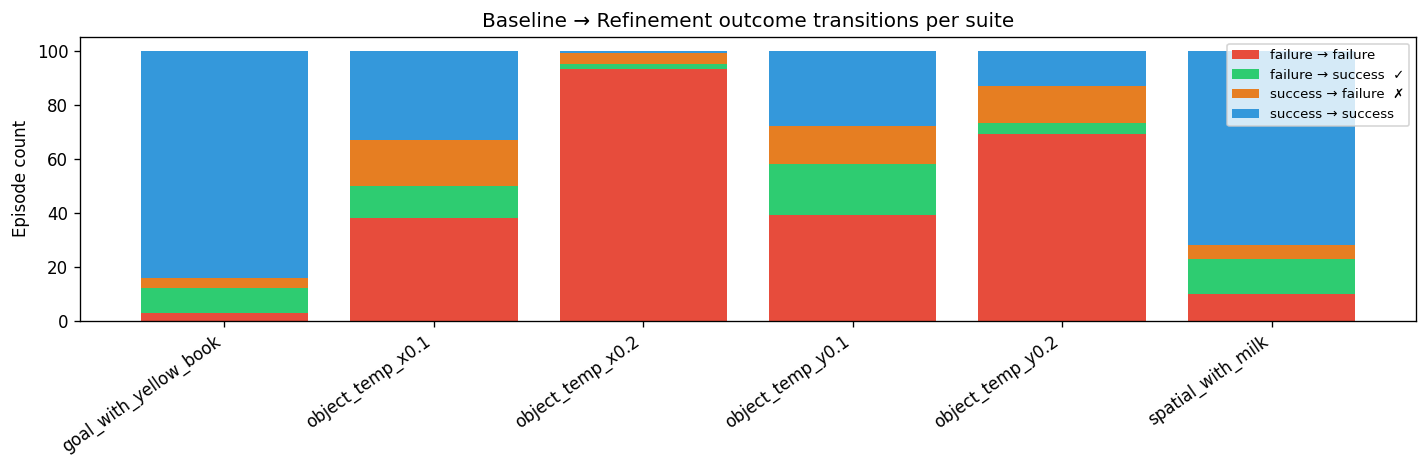

In [ ]:
if len(phase3) == 0:
    print('No Phase 3 data yet.')
else:
    # Pair baseline ↔ phase3 on (suite, task_idx, episode_idx, init_state_hash)
    b_key = baseline[['suite','task_idx','episode_idx','init_state_hash','success']].copy()
    b_key = b_key.rename(columns={'success': 'success_baseline'})
    p_key = phase3[['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']].copy()
    p_key = p_key.rename(columns={'success': 'success_pnp'})

    paired = b_key.merge(p_key, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')
    print(f'Paired episodes: {len(paired)}')

    def _transition(row):
        b, p = int(row['success_baseline']), int(row['success_pnp'])
        if b == 1 and p == 1: return 'success → success'
        if b == 0 and p == 1: return 'failure → success  ✓'
        if b == 1 and p == 0: return 'success → failure  ✗'
        return 'failure → failure'

    paired['transition'] = paired.apply(_transition, axis=1)

    # Global counts
    counts = paired['transition'].value_counts()
    print('\nOverall transition counts:')
    print(counts.to_string())
    print(f'\nBaseline SR:   {paired.success_baseline.mean():.1%}')
    print(f'Refinement SR: {paired.success_pnp.mean():.1%}')

    # Per-suite table
    print('\nPer-suite transitions:')
    for suite, grp in paired.groupby('suite'):
        tc = grp['transition'].value_counts()
        f2s = tc.get('failure → success  ✓', 0)
        s2f = tc.get('success → failure  ✗', 0)
        print(f'  {suite:<42} '
              f'base={grp.success_baseline.mean():.0%}  '
              f'pnp={grp.success_pnp.mean():.0%}  '
              f'F→S={f2s}  S→F={s2f}')

    # Transition chart per suite
    suites = sorted(paired['suite'].unique())
    cats   = ['failure → failure', 'failure → success  ✓',
              'success → failure  ✗', 'success → success']
    cat_colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

    fig, ax = plt.subplots(figsize=(12, 4))
    bottom = np.zeros(len(suites))
    for cat, color in zip(cats, cat_colors):
        vals = [
            paired[paired.suite == s]['transition'].value_counts().get(cat, 0)
            for s in suites
        ]
        ax.bar(range(len(suites)), vals, bottom=bottom, label=cat, color=color)
        bottom += np.array(vals, dtype=float)
    ax.set_xticks(range(len(suites)))
    ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=35, ha='right')
    ax.set_ylabel('Episode count')
    ax.set_title('Baseline → Refinement outcome transitions per suite')
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/transition_chart.png', dpi=150)
    plt.show()

## A5. Uncertainty vs. Outcome — Violin & Scatter Plots

In [ ]:
import sqlite3
con_check = sqlite3.connect('/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db')

# Check if u_mean_episode is populated for P&P rows
rows = con_check.execute("""
    SELECT suite, pnp_mode,
           COUNT(*) as n,
           SUM(CASE WHEN u_mean_episode IS NULL THEN 1 ELSE 0 END) as null_count,
           AVG(u_mean_episode) as avg_u
    FROM rollouts
    WHERE pnp_enabled = 1
    GROUP BY suite, pnp_mode
""").fetchall()
for r in rows:
    print(r)
con_check.close()

('libero_goal_with_yellow_book', 'both', 100, 0, 0.024829050617214916)
('libero_goal_with_yellow_book', 'uncertainty', 100, 0, 0.026441348746962225)
('libero_object_temp_x0.1', 'both', 100, 0, 0.022601066455089795)
('libero_object_temp_x0.1', 'uncertainty', 100, 0, 0.02270408840659851)
('libero_object_temp_x0.2', 'both', 100, 0, 0.029845294874782363)
('libero_object_temp_x0.2', 'uncertainty', 100, 0, 0.03070846039724226)
('libero_object_temp_y0.1', 'both', 100, 0, 0.02314300308644305)
('libero_object_temp_y0.1', 'uncertainty', 100, 0, 0.02410031071794219)
('libero_object_temp_y0.2', 'both', 100, 0, 0.0287846318090645)
('libero_object_temp_y0.2', 'uncertainty', 100, 0, 0.028361409675640367)
('libero_spatial_with_milk', 'both', 100, 0, 0.02685641968428779)
('libero_spatial_with_milk', 'uncertainty', 100, 0, 0.027092494649346915)


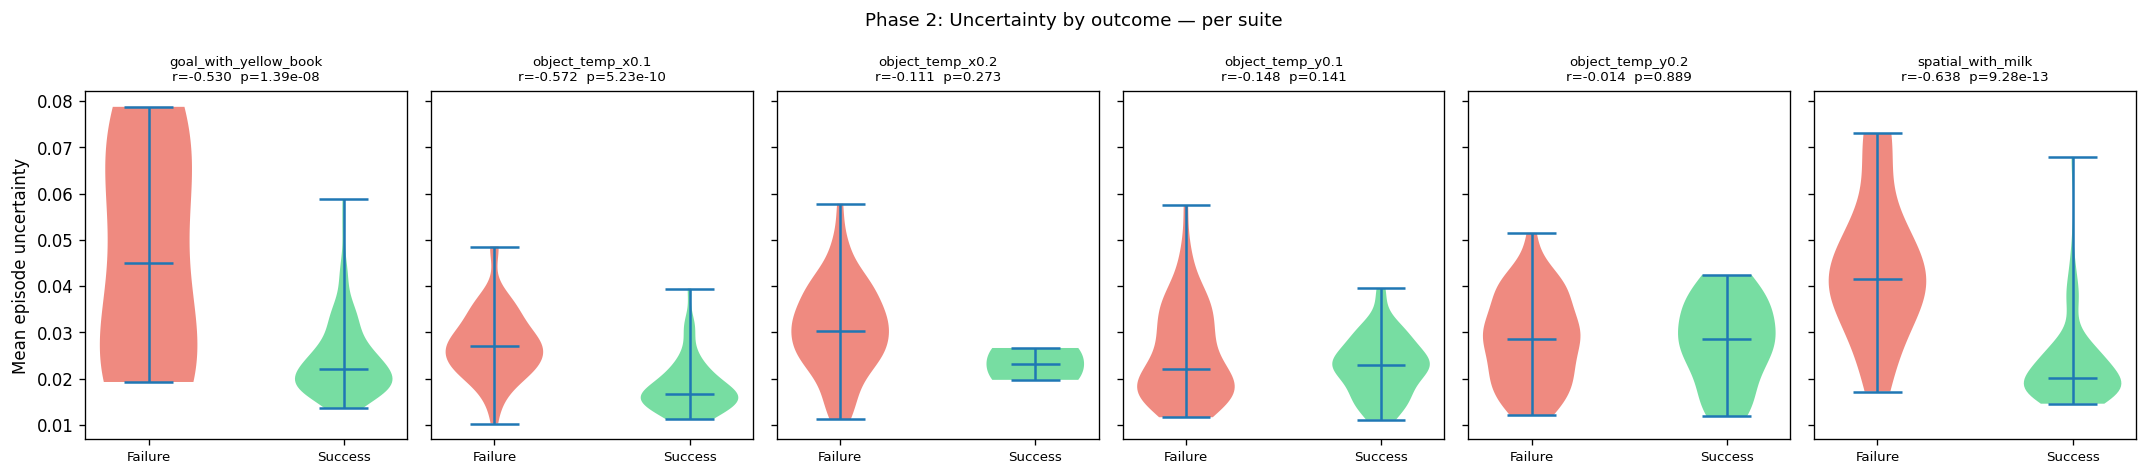

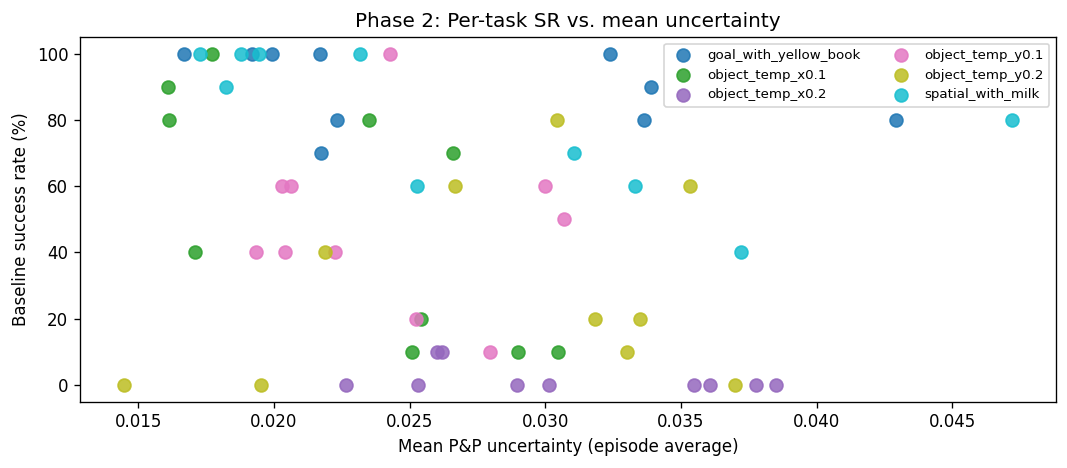

In [ ]:
if len(phase2) == 0:
    print('No Phase 2 data yet.')
else:
    suites = sorted(phase2['suite'].unique())
    n_suites = len(suites)

    # ── Violin: uncertainty by outcome, one panel per suite ──────────────────
    fig, axes = plt.subplots(1, n_suites, figsize=(3 * n_suites, 4), sharey=True)
    if n_suites == 1: axes = [axes]

    for ax, suite in zip(axes, suites):
        sub = phase2[phase2.suite == suite].dropna(subset=['u_mean_episode'])
        succ_u = sub.loc[sub.success == 1, 'u_mean_episode']
        fail_u = sub.loc[sub.success == 0, 'u_mean_episode']
        data   = [g for g in [fail_u, succ_u] if len(g) > 1]
        lbls   = [l for g, l in zip([fail_u, succ_u], ['Failure','Success']) if len(g) > 1]
        if data:
            vp = ax.violinplot(data, positions=range(len(data)), showmedians=True)
            colors = ['#e74c3c', '#2ecc71']
            for body, c in zip(vp['bodies'], colors[:len(data)]):
                body.set_facecolor(c)
                body.set_alpha(0.65)
        ax.set_xticks(range(len(lbls)))
        ax.set_xticklabels(lbls, fontsize=8)
        r, p = (pointbiserialr(sub['success'], sub['u_mean_episode'])
                if sub['success'].nunique() == 2 else (float('nan'), float('nan')))
        ax.set_title(f'{suite.replace("libero_","")}\nr={r:.3f}  p={p:.3g}', fontsize=8)
        if ax is axes[0]:
            ax.set_ylabel('Mean episode uncertainty')

    fig.suptitle('Phase 2: Uncertainty by outcome — per suite', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/uncertainty_by_outcome_violin.png', dpi=150)
    plt.show()

    # ── Per-task scatter: SR vs. mean uncertainty ─────────────────────────────
    per_task = (
        phase2.groupby(['suite','task_idx'])
        .agg(sr=('success','mean'), u_mean=('u_mean_episode','mean'), n=('success','count'))
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(9, 4))
    colors_suite = plt.cm.tab10(np.linspace(0, 1, len(suites)))
    for (suite, color) in zip(suites, colors_suite):
        g = per_task[per_task.suite == suite]
        ax.scatter(g['u_mean'], g['sr'] * 100, color=color,
                   s=60, alpha=0.85, label=suite.replace('libero_',''), zorder=3)
    ax.set_xlabel('Mean P&P uncertainty (episode average)')
    ax.set_ylabel('Baseline success rate (%)')
    ax.set_title('Phase 2: Per-task SR vs. mean uncertainty')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/sr_vs_uncertainty_scatter.png', dpi=150)
    plt.show()

Paired episodes: 600
suite
libero_goal_with_yellow_book    100
libero_object_temp_x0.1         100
libero_object_temp_x0.2         100
libero_object_temp_y0.1         100
libero_object_temp_y0.2         100
libero_spatial_with_milk        100
dtype: int64


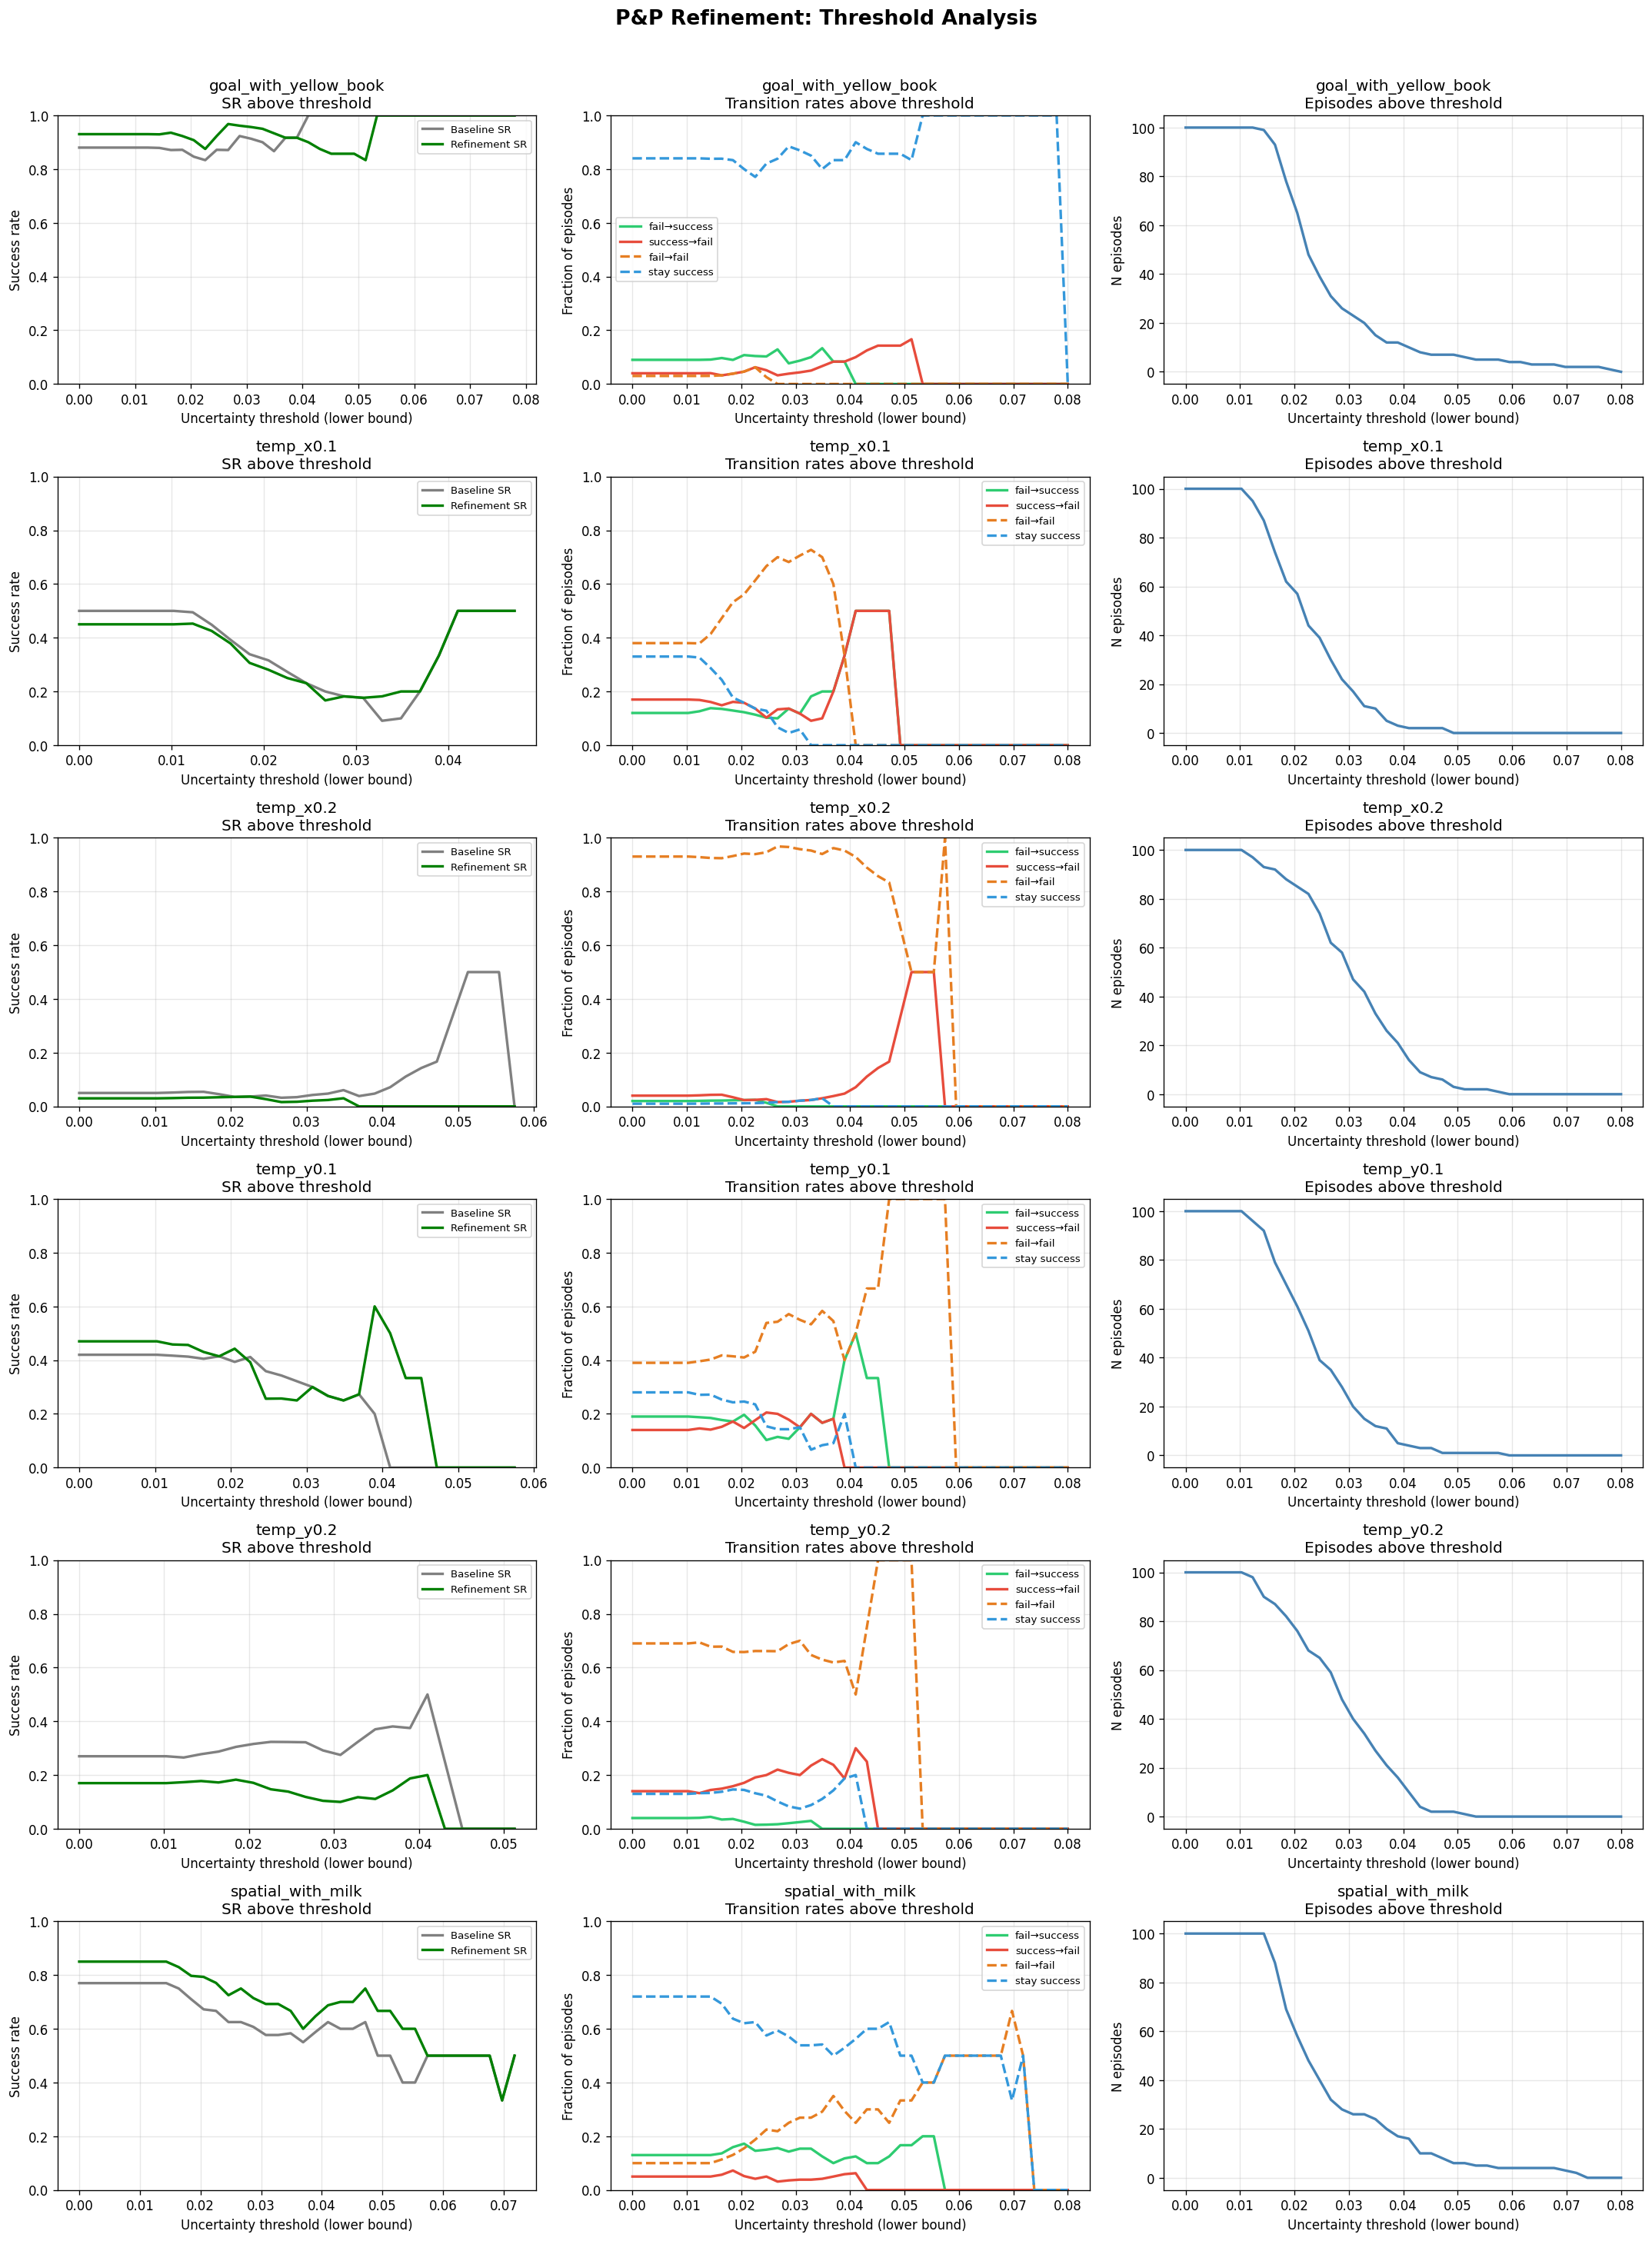

Saved to Drive.


In [ ]:
import sqlite3, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DB_PATH_JEFF = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db'
con = sqlite3.connect(DB_PATH_JEFF)

df = pd.read_sql('SELECT * FROM rollouts', con)
con.close()

# Pair baseline and refinement on (suite, task_idx, episode_idx, init_state_hash)
base = df[df.pnp_enabled == 0][['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'base_success'})
unc  = df[(df.pnp_enabled == 1) & (df.pnp_mode == 'uncertainty')]\
         [['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']]\
         .rename(columns={'success':'unc_success'})
ref  = df[(df.pnp_enabled == 1) & (df.pnp_mode == 'both')]\
         [['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'ref_success'})

# Merge all three phases
paired = base.merge(unc,  on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')\
             .merge(ref,  on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')

print(f'Paired episodes: {len(paired)}')
print(paired.groupby('suite').size())

# ── Threshold sweep ───────────────────────────────────────────────────────────
thresholds = np.linspace(0.0, 0.08, 40)
SUITES = sorted(paired['suite'].unique())
COLORS = {'fail->success': '#2ecc71', 'success->fail': '#e74c3c',
          'fail->fail': '#e67e22', 'success->success': '#3498db'}

fig, axes = plt.subplots(len(SUITES), 3, figsize=(18, 4*len(SUITES)))
fig.suptitle('P&P Refinement: Threshold Analysis', fontsize=16, fontweight='bold', y=1.01)

for i, suite in enumerate(SUITES):
    s = paired[paired.suite == suite].copy()
    short = suite.replace('libero_','').replace('object_','')

    # Arrays for threshold sweep
    n_above      = []
    sr_base      = []
    sr_ref       = []
    fail2success = []
    success2fail = []
    fail2fail    = []
    success2success = []

    for t in thresholds:
        above = s[s.u_mean_episode >= t]
        n_above.append(len(above))
        if len(above) == 0:
            sr_base.append(np.nan); sr_ref.append(np.nan)
            fail2success.append(0); success2fail.append(0)
            fail2fail.append(0); success2success.append(0)
            continue
        sr_base.append(above.base_success.mean())
        sr_ref.append(above.ref_success.mean())
        fail2success.append(((above.base_success==0) & (above.ref_success==1)).sum() / len(above))
        success2fail.append(((above.base_success==1) & (above.ref_success==0)).sum() / len(above))
        fail2fail.append(((above.base_success==0) & (above.ref_success==0)).sum() / len(above))
        success2success.append(((above.base_success==1) & (above.ref_success==1)).sum() / len(above))

    # Plot 1: SR vs threshold
    ax1 = axes[i, 0]
    ax1.plot(thresholds, sr_base, color='gray', label='Baseline SR', linewidth=2)
    ax1.plot(thresholds, sr_ref,  color='green', label='Refinement SR', linewidth=2)
    ax1.set_xlabel('Uncertainty threshold (lower bound)')
    ax1.set_ylabel('Success rate')
    ax1.set_title(f'{short}\nSR above threshold')
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, 1)
    ax1.grid(alpha=0.3)

    # Plot 2: Transition rates vs threshold
    ax2 = axes[i, 1]
    ax2.plot(thresholds, fail2success,    color=COLORS['fail->success'],    label='fail→success', linewidth=2)
    ax2.plot(thresholds, success2fail,    color=COLORS['success->fail'],    label='success→fail', linewidth=2)
    ax2.plot(thresholds, fail2fail,       color=COLORS['fail->fail'],       label='fail→fail',    linewidth=2, linestyle='--')
    ax2.plot(thresholds, success2success, color=COLORS['success->success'], label='stay success', linewidth=2, linestyle='--')
    ax2.set_xlabel('Uncertainty threshold (lower bound)')
    ax2.set_ylabel('Fraction of episodes')
    ax2.set_title(f'{short}\nTransition rates above threshold')
    ax2.legend(fontsize=8)
    ax2.set_ylim(0, 1)
    ax2.grid(alpha=0.3)

    # Plot 3: N episodes above threshold
    ax3 = axes[i, 2]
    ax3.plot(thresholds, n_above, color='steelblue', linewidth=2)
    ax3.set_xlabel('Uncertainty threshold (lower bound)')
    ax3.set_ylabel('N episodes')
    ax3.set_title(f'{short}\nEpisodes above threshold')
    ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/threshold_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

Total paired episodes: 600
Overall baseline SR:   0.482


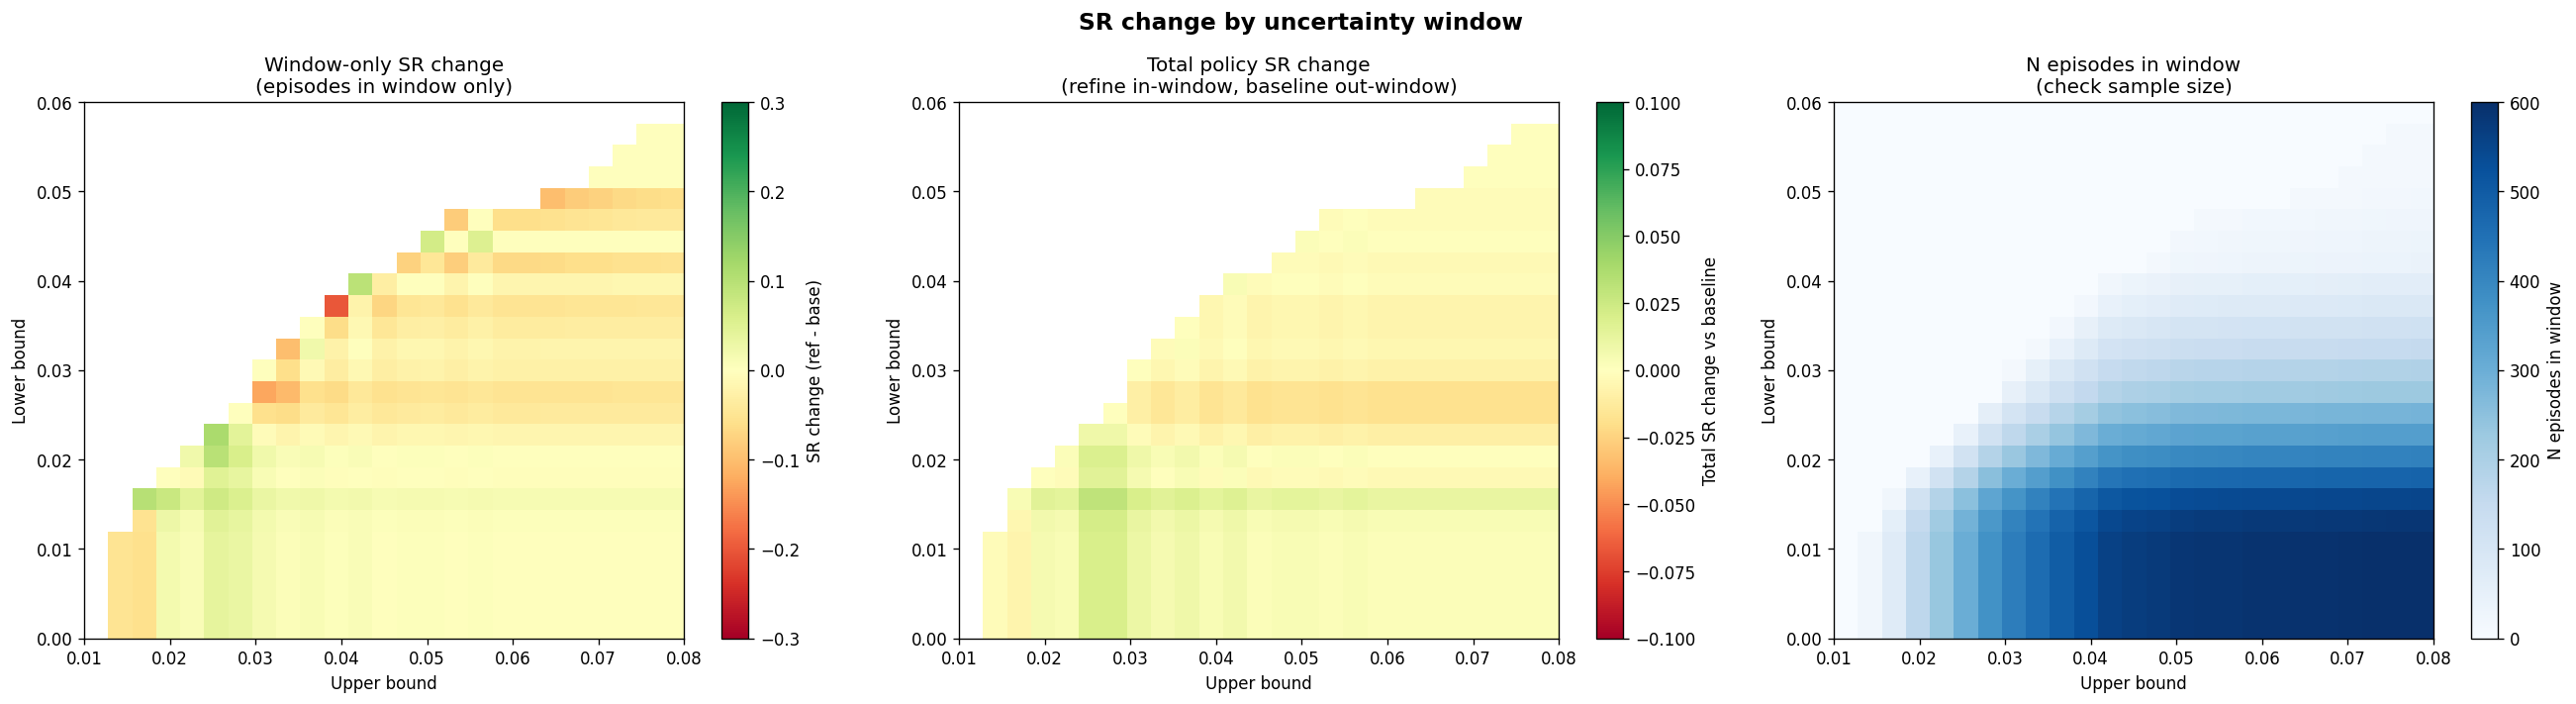


Overall baseline SR: 0.482

TOP 10 windows by WINDOW SR change:
   Lower    Upper      N  Win SR chg  Tot SR chg  Base SR   Ref SR
-----------------------------------------------------------------
   0.022    0.025     44      +0.114      +0.008    0.523    0.636
   0.015    0.016     20      +0.100      +0.003    0.650    0.750
   0.020    0.025    113      +0.097      +0.018    0.549    0.646
   0.040    0.042     21      +0.095      +0.003    0.238    0.333
   0.015    0.019    114      +0.079      +0.015    0.658    0.737
   0.015    0.025    251      +0.072      +0.030    0.618    0.689
   0.020    0.028    184      +0.060      +0.018    0.495    0.554
   0.015    0.028    322      +0.056      +0.030    0.571    0.627
   0.018    0.025    183      +0.049      +0.015    0.601    0.650
   0.013    0.025    287      +0.045      +0.022    0.610    0.655

TOP 10 windows by TOTAL POLICY SR change:
   Lower    Upper      N  Win SR chg  Tot SR chg  Base SR   Ref SR
----------------------

In [ ]:
import sqlite3, numpy as np, pandas as pd
import matplotlib.pyplot as plt

DB_PATH_JEFF = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db'
con = sqlite3.connect(DB_PATH_JEFF)
df = pd.read_sql('SELECT * FROM rollouts', con)
con.close()

# Pair phases
base = df[df.pnp_enabled==0][['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'base_success'})
unc  = df[(df.pnp_enabled==1)&(df.pnp_mode=='uncertainty')]\
         [['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']]\
         .rename(columns={'success':'unc_success'})
ref  = df[(df.pnp_enabled==1)&(df.pnp_mode=='both')]\
         [['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'ref_success'})

paired = base.merge(unc, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')\
             .merge(ref, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')

total_n = len(paired)
overall_base_sr = paired.base_success.mean()
print(f'Total paired episodes: {total_n}')
print(f'Overall baseline SR:   {overall_base_sr:.3f}')

# ── Sweep ─────────────────────────────────────────────────────────────────────
lower_bounds = np.linspace(0.0, 0.06, 25)
upper_bounds = np.linspace(0.01, 0.08, 25)

# Window-only SR change
sr_change_window   = np.full((len(lower_bounds), len(upper_bounds)), np.nan)
# Total SR change (selective refinement policy)
sr_change_total    = np.full((len(lower_bounds), len(upper_bounds)), np.nan)
n_episodes         = np.zeros((len(lower_bounds), len(upper_bounds)))

for i, lo in enumerate(lower_bounds):
    for j, hi in enumerate(upper_bounds):
        if hi <= lo:
            continue
        in_window  = paired[(paired.u_mean_episode >= lo) & (paired.u_mean_episode <= hi)]
        out_window = paired[(paired.u_mean_episode < lo)  | (paired.u_mean_episode > hi)]
        if len(in_window) < 10:
            continue

        n_episodes[i, j] = len(in_window)

        # Window-only: SR change just for episodes in window
        sr_change_window[i, j] = in_window.ref_success.mean() - in_window.base_success.mean()

        # Total policy: refine in-window, keep baseline for out-window
        successes_in  = in_window.ref_success.sum()
        successes_out = out_window.base_success.sum()
        total_sr_policy = (successes_in + successes_out) / total_n
        sr_change_total[i, j] = total_sr_policy - overall_base_sr

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('SR change by uncertainty window', fontsize=14, fontweight='bold')

# Plot 1: Window-only SR change
im1 = axes[0].imshow(sr_change_window, aspect='auto', origin='lower',
                      cmap='RdYlGn', vmin=-0.3, vmax=0.3,
                      extent=[upper_bounds[0], upper_bounds[-1],
                               lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im1, ax=axes[0], label='SR change (ref - base)')
axes[0].set_xlabel('Upper bound')
axes[0].set_ylabel('Lower bound')
axes[0].set_title('Window-only SR change\n(episodes in window only)')

# Plot 2: Total policy SR change
im2 = axes[1].imshow(sr_change_total, aspect='auto', origin='lower',
                      cmap='RdYlGn', vmin=-0.1, vmax=0.1,
                      extent=[upper_bounds[0], upper_bounds[-1],
                               lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im2, ax=axes[1], label='Total SR change vs baseline')
axes[1].set_xlabel('Upper bound')
axes[1].set_ylabel('Lower bound')
axes[1].set_title('Total policy SR change\n(refine in-window, baseline out-window)')

# Plot 3: N episodes in window
im3 = axes[2].imshow(n_episodes, aspect='auto', origin='lower',
                      cmap='Blues',
                      extent=[upper_bounds[0], upper_bounds[-1],
                               lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im3, ax=axes[2], label='N episodes in window')
axes[2].set_xlabel('Upper bound')
axes[2].set_ylabel('Lower bound')
axes[2].set_title('N episodes in window\n(check sample size)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/threshold_2d_heatmap_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top/bottom windows ────────────────────────────────────────────────────────
results = []
for i, lo in enumerate(lower_bounds):
    for j, hi in enumerate(upper_bounds):
        if np.isnan(sr_change_window[i,j]) or n_episodes[i,j] < 20:
            continue
        in_window  = paired[(paired.u_mean_episode >= lo) & (paired.u_mean_episode <= hi)]
        out_window = paired[(paired.u_mean_episode < lo)  | (paired.u_mean_episode > hi)]
        successes_in  = in_window.ref_success.sum()
        successes_out = out_window.base_success.sum()
        total_sr_policy = (successes_in + successes_out) / total_n
        results.append({
            'lo': lo, 'hi': hi, 'n': len(in_window),
            'window_sr_change': sr_change_window[i,j],
            'total_sr_change':  total_sr_policy - overall_base_sr,
            'base_sr_window':   in_window.base_success.mean(),
            'ref_sr_window':    in_window.ref_success.mean(),
            'total_sr_policy':  total_sr_policy,
        })

results_df = pd.DataFrame(results)

print(f'\nOverall baseline SR: {overall_base_sr:.3f}')
print(f'\n{"==="*20}')
print('TOP 10 windows by WINDOW SR change:')
print(f'{"Lower":>8} {"Upper":>8} {"N":>6} {"Win SR chg":>11} {"Tot SR chg":>11} {"Base SR":>8} {"Ref SR":>8}')
print('-' * 65)
for _, r in results_df.nlargest(10, 'window_sr_change').iterrows():
    print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
          f'{r.window_sr_change:>+11.3f} {r.total_sr_change:>+11.3f} '
          f'{r.base_sr_window:>8.3f} {r.ref_sr_window:>8.3f}')

print(f'\n{"==="*20}')
print('TOP 10 windows by TOTAL POLICY SR change:')
print(f'{"Lower":>8} {"Upper":>8} {"N":>6} {"Win SR chg":>11} {"Tot SR chg":>11} {"Base SR":>8} {"Ref SR":>8}')
print('-' * 65)
for _, r in results_df.nlargest(10, 'total_sr_change').iterrows():
    print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
          f'{r.window_sr_change:>+11.3f} {r.total_sr_change:>+11.3f} '
          f'{r.base_sr_window:>8.3f} {r.ref_sr_window:>8.3f}')

print(f'\n{"==="*20}')
print('BOTTOM 10 windows by TOTAL POLICY SR change (most degradation):')
print(f'{"Lower":>8} {"Upper":>8} {"N":>6} {"Win SR chg":>11} {"Tot SR chg":>11} {"Base SR":>8} {"Ref SR":>8}')
print('-' * 65)
for _, r in results_df.nsmallest(10, 'total_sr_change').iterrows():
    print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
          f'{r.window_sr_change:>+11.3f} {r.total_sr_change:>+11.3f} '
          f'{r.base_sr_window:>8.3f} {r.ref_sr_window:>8.3f}')

## A6. ROC / AUC — Uncertainty as Failure Predictor

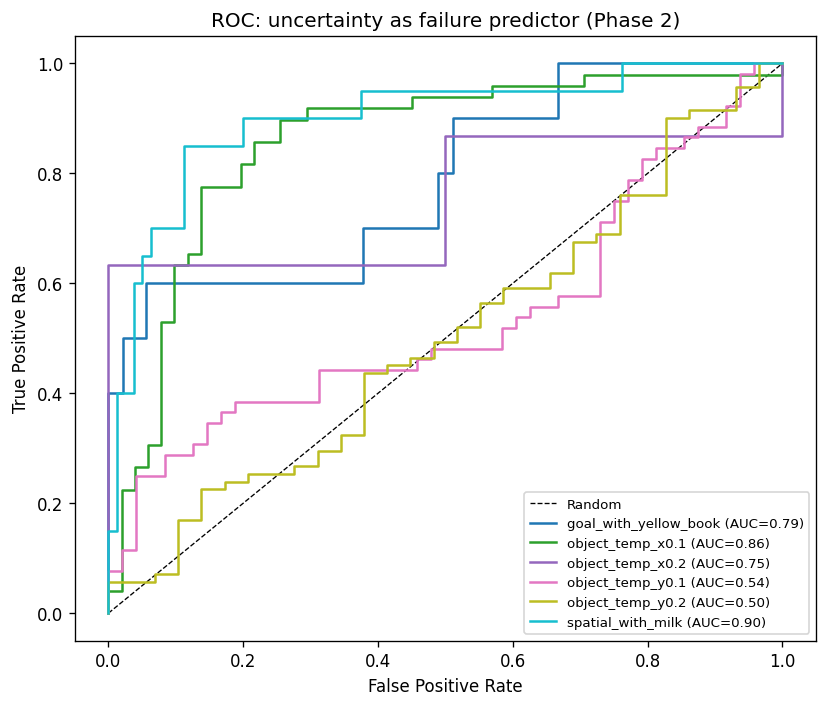


AUC by suite:
  libero_spatial_with_milk                      AUC=0.900  [distractor]
  libero_object_temp_x0.1                       AUC=0.857  [pos_perturb]
  libero_goal_with_yellow_book                  AUC=0.788  [distractor]
  libero_object_temp_x0.2                       AUC=0.750  [pos_perturb]
  libero_object_temp_y0.1                       AUC=0.537  [pos_perturb]
  libero_object_temp_y0.2                       AUC=0.501  [pos_perturb]

Mean AUC across suites: 0.722


In [ ]:
if len(phase2) == 0:
    print('No Phase 2 data yet.')
else:
    sub = phase2.dropna(subset=['u_mean_episode'])
    suites = sorted(sub['suite'].unique())

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0,1],[0,1],'k--',lw=0.8, label='Random')

    auc_results = {}
    colors_suite = plt.cm.tab10(np.linspace(0, 1, len(suites)))

    for suite, color in zip(suites, colors_suite):
        g = sub[sub.suite == suite]
        if g['success'].nunique() < 2:
            print(f'  Skipping {suite}: only one outcome class present')
            continue
        # Higher uncertainty → predicts failure (success=0)
        fpr, tpr, _ = roc_curve(1 - g['success'], g['u_mean_episode'])
        roc_auc = auc(fpr, tpr)
        auc_results[suite] = roc_auc
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f'{suite.replace("libero_","")} (AUC={roc_auc:.2f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC: uncertainty as failure predictor (Phase 2)')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/roc_curves.png', dpi=150)
    plt.show()

    print('\nAUC by suite:')
    for suite, a_val in sorted(auc_results.items(), key=lambda x: -x[1]):
        stype = 'pos_perturb' if 'temp_' in suite else 'distractor'
        print(f'  {suite:<45} AUC={a_val:.3f}  [{stype}]')

    if auc_results:
        overall_auc = np.mean(list(auc_results.values()))
        print(f'\nMean AUC across suites: {overall_auc:.3f}')

## A7. Uncertainty by Euler Step

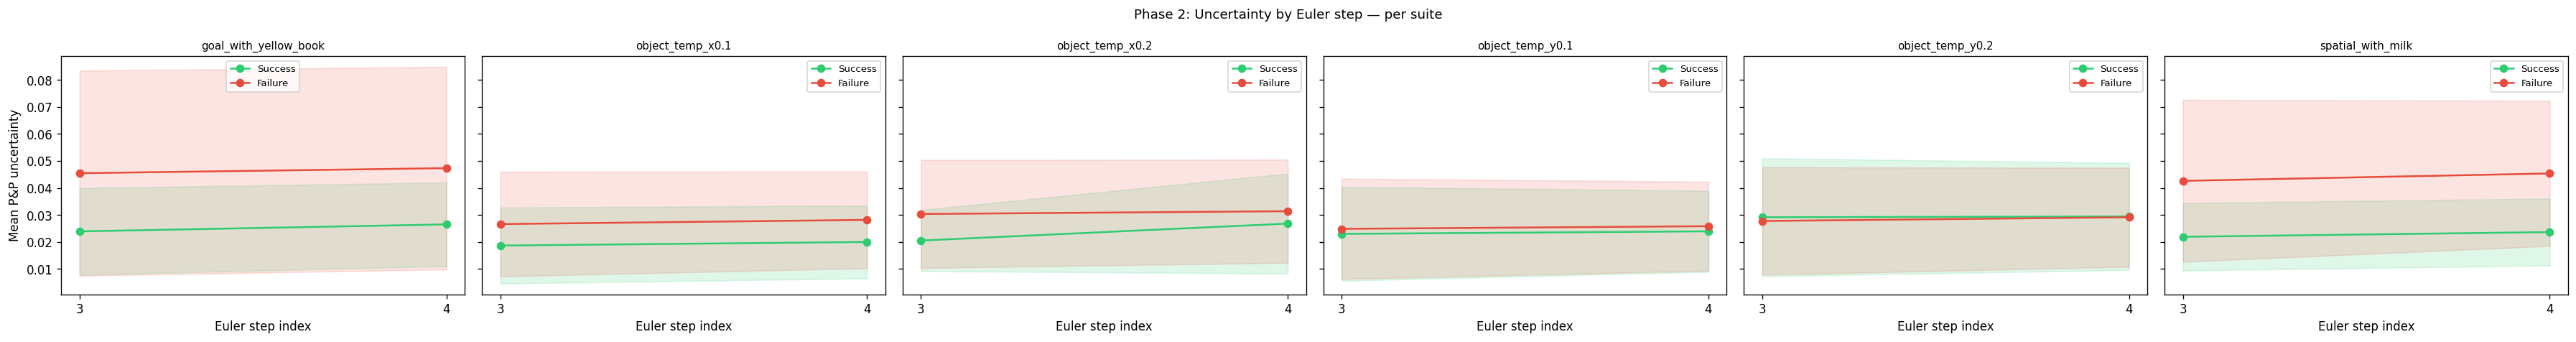

Point-biserial r (uncertainty ↔ failure) per Euler step:
 euler_step         r            p    n
          3 -0.153891 5.838449e-16 2735
          4 -0.158018 9.377838e-17 2735


In [ ]:
if len(steps_p2) == 0:
    print('No Phase 2 Euler step data yet.')
else:
    # Join outcome labels
    steps_j = steps_p2.merge(
        phase2[['rollout_id','success','suite']], on='rollout_id', how='left')

    suites = sorted(steps_j['suite'].dropna().unique())
    n_suites = len(suites)

    fig, axes = plt.subplots(1, n_suites, figsize=(5 * n_suites, 4), sharey=True)
    if n_suites == 1: axes = [axes]

    for ax, suite in zip(axes, suites):
        sub = steps_j[steps_j.suite == suite]
        by_e = (sub.groupby(['euler_step','success'])
                .agg(u_mean=('u_mean','mean'), u_std=('u_mean','std'))
                .reset_index())
        for outcome, label, color in [(1,'Success','#2ecc71'), (0,'Failure','#e74c3c')]:
            g = by_e[by_e.success == outcome].sort_values('euler_step')
            if g.empty: continue
            ax.plot(g['euler_step'], g['u_mean'], marker='o', color=color, label=label)
            ax.fill_between(g['euler_step'],
                            g['u_mean'] - g['u_std'].fillna(0),
                            g['u_mean'] + g['u_std'].fillna(0),
                            alpha=0.15, color=color)
        ax.set_xlabel('Euler step index')
        if ax is axes[0]: ax.set_ylabel('Mean P&P uncertainty')
        ax.set_title(suite.replace('libero_',''), fontsize=9)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8)

    fig.suptitle('Phase 2: Uncertainty by Euler step — per suite', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/uncertainty_by_euler_step.png', dpi=150)
    plt.show()

    # Point-biserial discriminability per step
    print('Point-biserial r (uncertainty ↔ failure) per Euler step:')
    step_corrs = []
    for step_idx, grp in steps_j.groupby('euler_step'):
        if grp['success'].nunique() < 2: continue
        r, p = pointbiserialr(grp['success'], grp['u_mean'])
        step_corrs.append({'euler_step': step_idx, 'r': r, 'p': p, 'n': len(grp)})
    sc_df = pd.DataFrame(step_corrs).sort_values('euler_step')
    print(sc_df.to_string(index=False))

## A8. Uncertainty Over Episode Time

/tmp/ipykernel_3391/2683648873.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bin = (sub.groupby(['time_bin','success'])
/tmp/ipykernel_3391/2683648873.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bin = (sub.groupby(['time_bin','success'])
/tmp/ipykernel_3391/2683648873.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bin = (sub.groupby(['time_bin','success'])
/tmp/ipykernel_3391/2683648873.py:

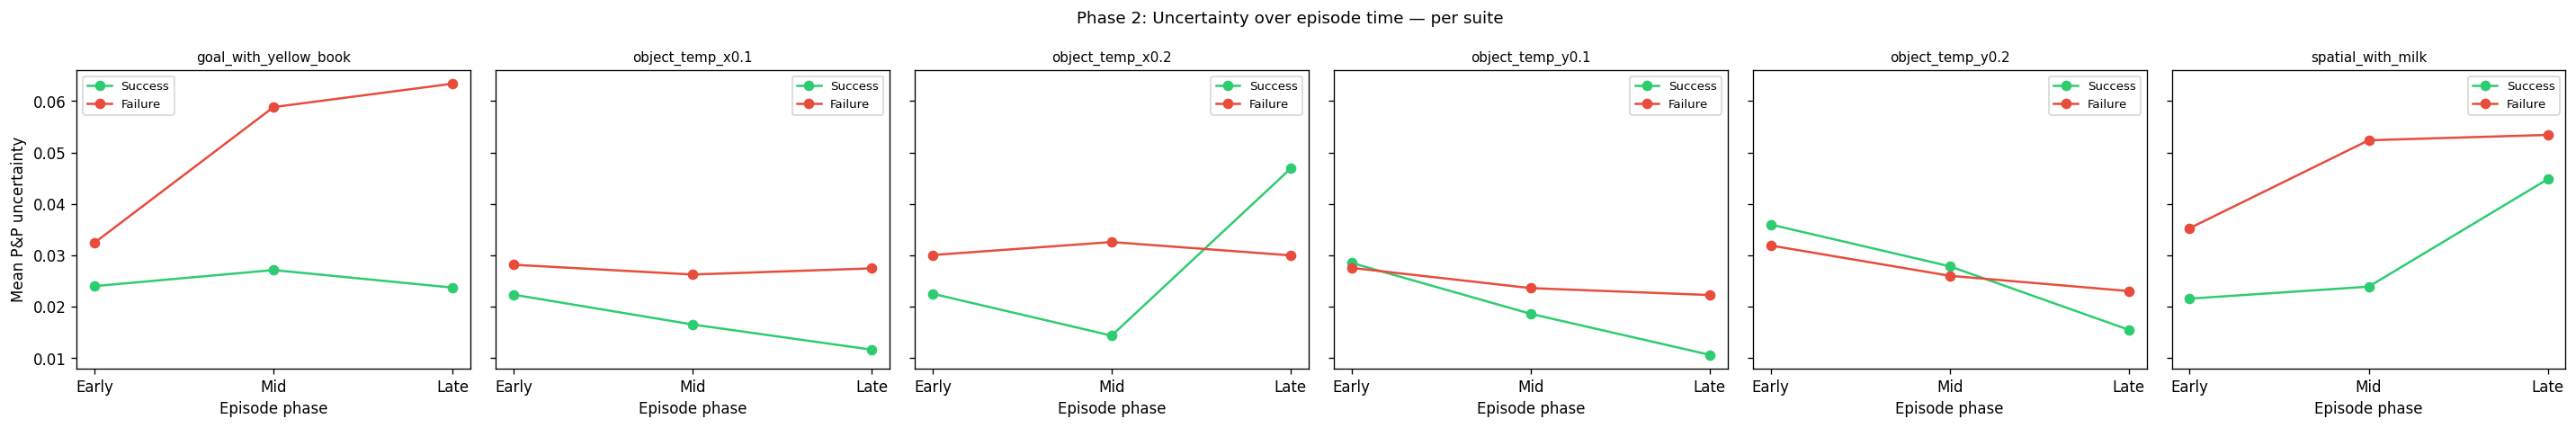

In [ ]:
if len(steps_p2) == 0:
    print('No Phase 2 data yet.')
else:
    steps_j = steps_p2.merge(
        phase2[['rollout_id','success','suite']], on='rollout_id', how='left')

    # Bin chunk_idx into early / mid / late thirds
    max_chunk = steps_j.groupby('rollout_id')['chunk_idx'].transform('max').clip(lower=0)
    steps_j['time_bin'] = pd.cut(
        steps_j['chunk_idx'] / (max_chunk + 1),
        bins=[0, 1/3, 2/3, 1.0001],
        labels=['Early', 'Mid', 'Late'],
        include_lowest=True
    )

    suites   = sorted(steps_j['suite'].dropna().unique())
    n_suites = len(suites)

    fig, axes = plt.subplots(1, n_suites, figsize=(4 * n_suites, 4), sharey=True)
    if n_suites == 1: axes = [axes]

    for ax, suite in zip(axes, suites):
        sub = steps_j[steps_j.suite == suite]
        by_bin = (sub.groupby(['time_bin','success'])
                  .agg(u_mean=('u_mean','mean'), u_std=('u_mean','std'))
                  .reset_index())
        bins = ['Early', 'Mid', 'Late']
        for outcome, label, color in [(1,'Success','#2ecc71'), (0,'Failure','#e74c3c')]:
            g = by_bin[by_bin.success == outcome]
            u_vals = [g[g.time_bin == b]['u_mean'].values[0]
                      if len(g[g.time_bin == b]) else np.nan for b in bins]
            ax.plot(range(len(bins)), u_vals, marker='o', color=color, label=label)
        ax.set_xticks(range(len(bins)))
        ax.set_xticklabels(bins)
        ax.set_xlabel('Episode phase')
        if ax is axes[0]: ax.set_ylabel('Mean P&P uncertainty')
        ax.set_title(suite.replace('libero_',''), fontsize=9)
        ax.legend(fontsize=8)

    fig.suptitle('Phase 2: Uncertainty over episode time — per suite', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/uncertainty_over_time.png', dpi=150)
    plt.show()

## A9. Per-Task P&P Lift — Before vs. After Refinement

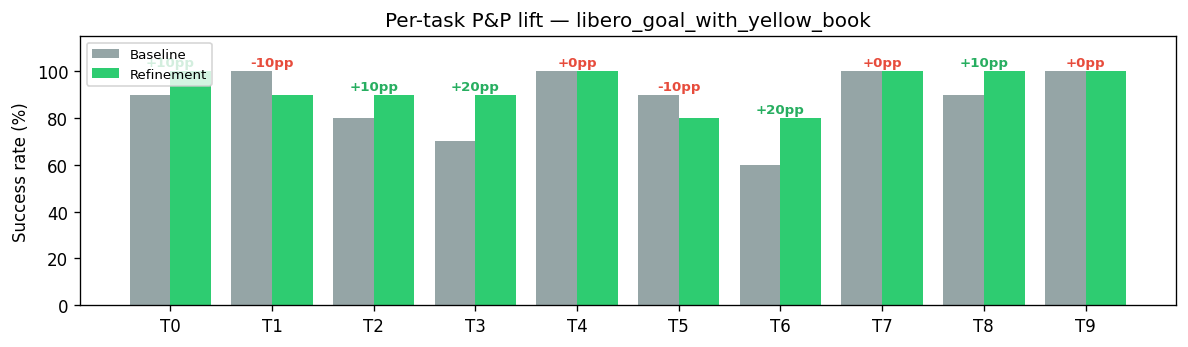

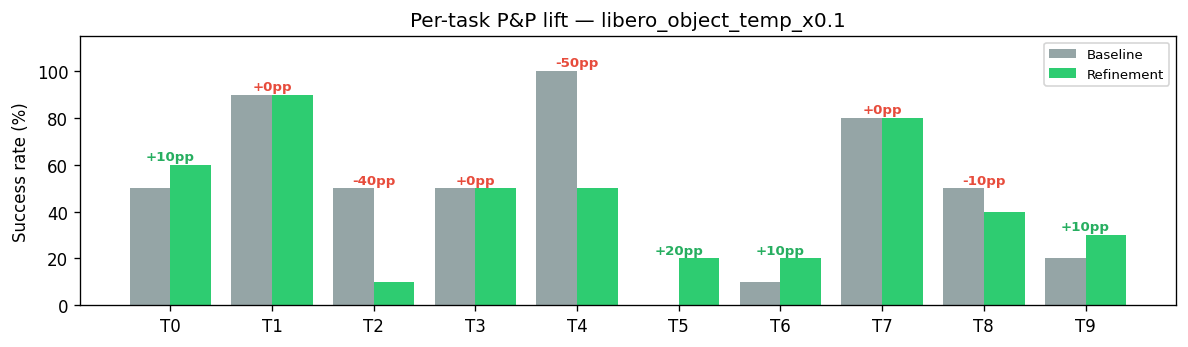

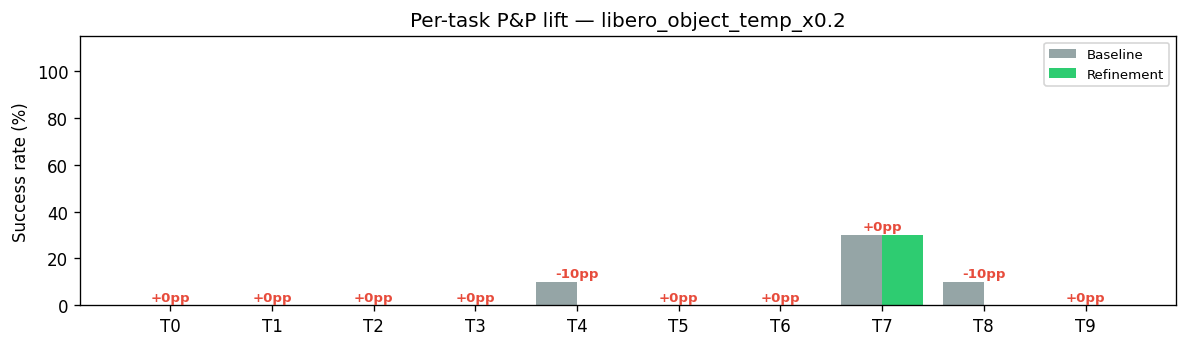

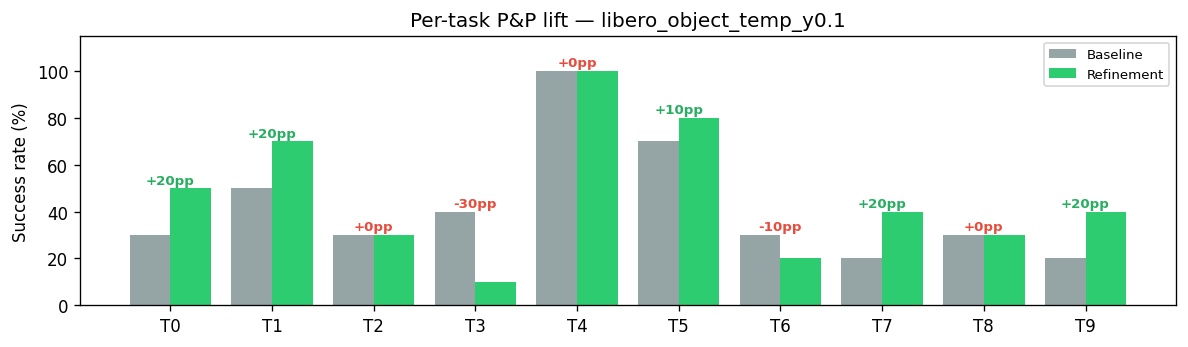

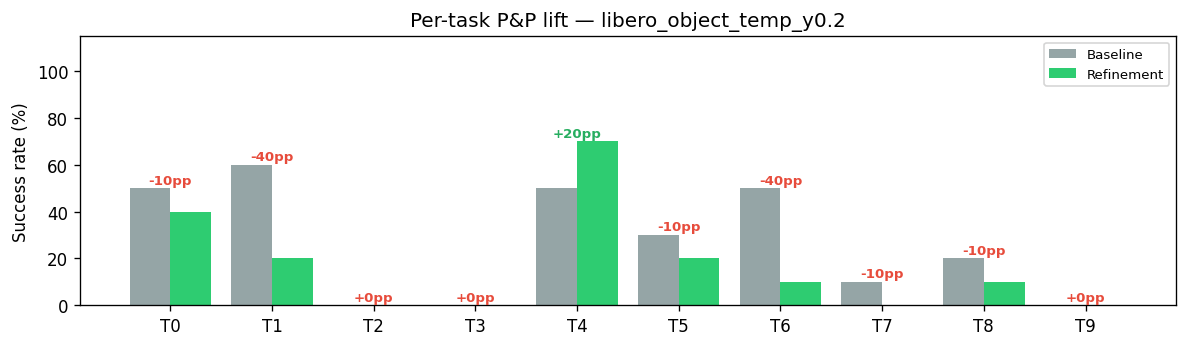

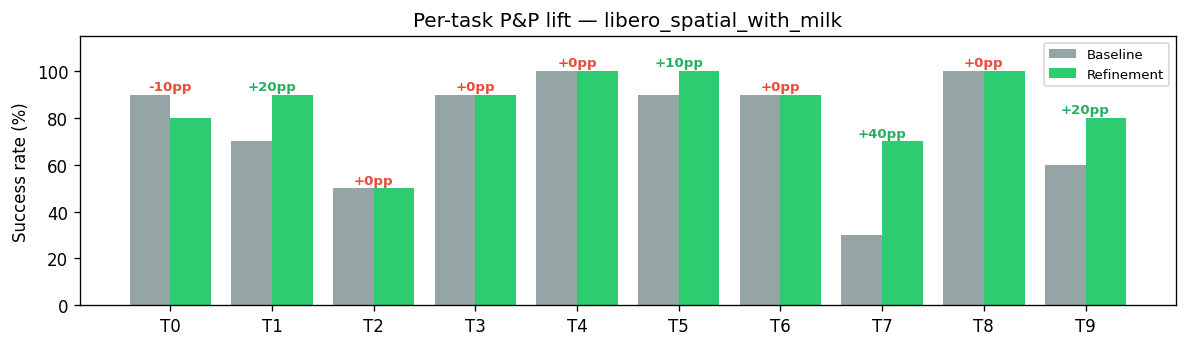


Top-5 biggest P&P improvements (failure → success):
                       suite  task_idx  sr_baseline  sr_pnp  lift
    libero_spatial_with_milk         7          0.3     0.7   0.4
libero_goal_with_yellow_book         3          0.7     0.9   0.2
libero_goal_with_yellow_book         6          0.6     0.8   0.2
    libero_spatial_with_milk         1          0.7     0.9   0.2
    libero_spatial_with_milk         9          0.6     0.8   0.2

Top-5 biggest regressions (success → failure):
                  suite  task_idx  sr_baseline  sr_pnp  lift
libero_object_temp_x0.1         4          1.0     0.5  -0.5
libero_object_temp_x0.1         2          0.5     0.1  -0.4
libero_object_temp_y0.2         6          0.5     0.1  -0.4
libero_object_temp_y0.2         1          0.6     0.2  -0.4
libero_object_temp_y0.1         3          0.4     0.1  -0.3


In [ ]:
if len(phase3) == 0:
    print('No Phase 3 data yet.')
else:
    base_task = baseline.groupby(['suite','task_idx'])['success'].mean().reset_index()
    base_task.columns = ['suite','task_idx','sr_baseline']
    pnp_task  = phase3.groupby(['suite','task_idx'])['success'].mean().reset_index()
    pnp_task.columns  = ['suite','task_idx','sr_pnp']

    lift_df = base_task.merge(pnp_task, on=['suite','task_idx'], how='inner')
    lift_df['lift'] = lift_df['sr_pnp'] - lift_df['sr_baseline']

    suites = sorted(lift_df['suite'].unique())

    for suite in suites:
        g = lift_df[lift_df.suite == suite].sort_values('task_idx')
        fig, ax = plt.subplots(figsize=(10, 3))
        x  = np.arange(len(g))
        ax.bar(x - 0.2, g['sr_baseline'] * 100, width=0.4,
               label='Baseline', color='#95a5a6')
        ax.bar(x + 0.2, g['sr_pnp'] * 100, width=0.4,
               label='Refinement', color='#2ecc71')
        for xi, (_, row) in zip(x, g.iterrows()):
            lift = row['lift']
            color = '#27ae60' if lift > 0 else '#e74c3c'
            ax.annotate(f'{lift*100:+.0f}pp', xy=(xi, max(row['sr_baseline'], row['sr_pnp'])*100 + 2),
                        ha='center', fontsize=8, color=color, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'T{i}' for i in g['task_idx']])
        ax.set_ylabel('Success rate (%)')
        ax.set_ylim(0, 115)
        ax.set_title(f'Per-task P&P lift — {suite}')
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(f'{RESULTS_DIR}/pnp_lift_{suite}.png', dpi=150)
        plt.show()

    # Summary: biggest improvers and regressors
    print('\nTop-5 biggest P&P improvements (failure → success):')
    top = lift_df.nlargest(5, 'lift')[['suite','task_idx','sr_baseline','sr_pnp','lift']]
    print(top.to_string(index=False))
    print('\nTop-5 biggest regressions (success → failure):')
    bot = lift_df.nsmallest(5, 'lift')[['suite','task_idx','sr_baseline','sr_pnp','lift']]
    print(bot.to_string(index=False))

## A10. Cross-Suite Comparison — Position Perturbation vs. Distractor

Cross-suite summary:
                       suite       suite_type  sr_baseline  sr_pnp  lift      auc   u_mean
libero_goal_with_yellow_book       distractor         0.88    0.93  0.05 0.787778 0.026441
     libero_object_temp_x0.1 position_perturb         0.50    0.45 -0.05 0.856743 0.022704
     libero_object_temp_x0.2 position_perturb         0.05    0.03 -0.02 0.750000 0.030708
     libero_object_temp_y0.1 position_perturb         0.42    0.47  0.05 0.536859 0.024100
     libero_object_temp_y0.2 position_perturb         0.27    0.17 -0.10 0.500729 0.028361
    libero_spatial_with_milk       distractor         0.77    0.85  0.08 0.900000 0.027092


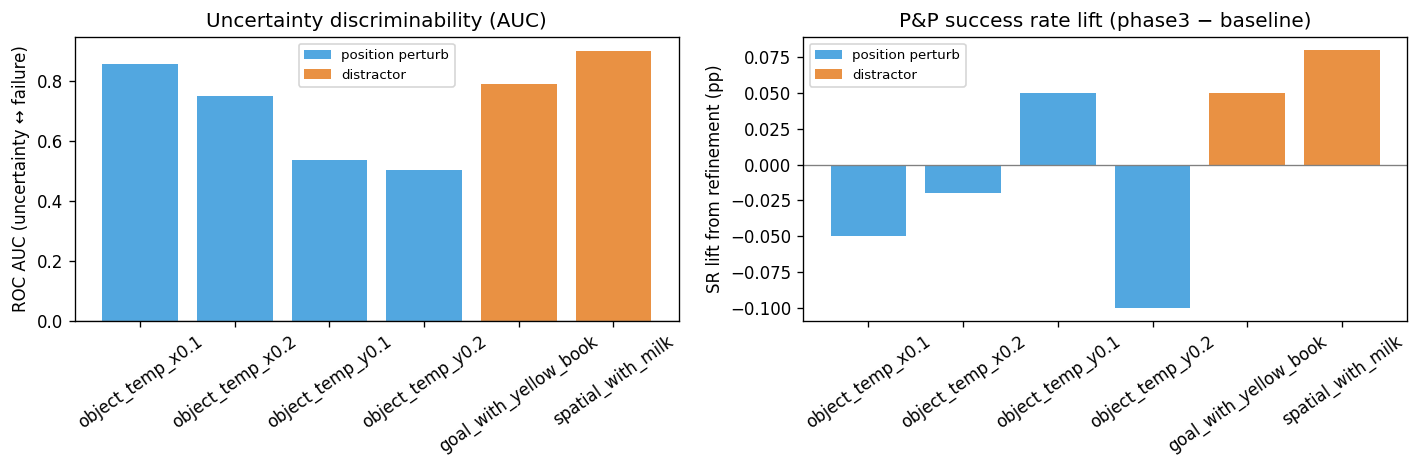


Means by suite type:
                  sr_baseline   lift    auc
suite_type                                 
distractor              0.825  0.065  0.844
position_perturb        0.310 -0.030  0.661


In [ ]:
if len(phase2) == 0 or len(phase3) == 0:
    print('Need both Phase 2 and Phase 3 data for this comparison.')
else:
    summary_rows = []
    sub = phase2.dropna(subset=['u_mean_episode'])

    for suite in sorted(rollouts['suite'].unique()):
        base_sr = baseline[baseline.suite == suite]['success'].mean()
        pnp_sr  = phase3[phase3.suite == suite]['success'].mean()
        p2_sub  = sub[sub.suite == suite]

        # AUC
        roc_auc = float('nan')
        if p2_sub['success'].nunique() == 2:
            fpr, tpr, _ = roc_curve(1 - p2_sub['success'], p2_sub['u_mean_episode'])
            roc_auc = auc(fpr, tpr)

        summary_rows.append({
            'suite':       suite,
            'suite_type':  'position_perturb' if 'temp_' in suite else 'distractor',
            'sr_baseline': base_sr,
            'sr_pnp':      pnp_sr,
            'lift':        pnp_sr - base_sr if not np.isnan(pnp_sr) else np.nan,
            'auc':         roc_auc,
            'u_mean':      p2_sub['u_mean_episode'].mean(),
        })

    summary = pd.DataFrame(summary_rows)
    print('Cross-suite summary:')
    print(summary.to_string(index=False))

    # Grouped comparison chart
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, (col, ylabel, title) in zip(axes, [
        ('auc',  'ROC AUC (uncertainty ↔ failure)', 'Uncertainty discriminability (AUC)'),
        ('lift', 'SR lift from refinement (pp)',     'P&P success rate lift (phase3 − baseline)'),
    ]):
        for stype, color in [('position_perturb','#3498db'), ('distractor','#e67e22')]:
            g = summary[summary.suite_type == stype].dropna(subset=[col])
            if g.empty: continue
            ax.bar(g['suite'].str.replace('libero_',''), g[col],
                   color=color, label=stype.replace('_',' '), alpha=0.85)
        ax.axhline(0, color='gray', lw=0.8)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=35)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cross_suite_comparison.png', dpi=150)
    plt.show()

    # Group-level means
    print('\nMeans by suite type:')
    print(summary.groupby('suite_type')[['sr_baseline','lift','auc']].mean().round(3).to_string())

## A11. Pairing Coverage Diagnostics

In [ ]:
print('Pairing coverage diagnostics')
print('=' * 55)

for label, df in [('Phase 2 (uncertainty)', phase2), ('Phase 3 (refinement)', phase3)]:
    if len(df) == 0:
        print(f'{label}: no data')
        continue

    # Pair on (suite, task_idx, episode_idx, init_state_hash)
    keys = ['suite', 'task_idx', 'episode_idx', 'init_state_hash']
    base_keys = set(map(tuple, baseline[keys].values.tolist()))
    pnp_keys  = set(map(tuple, df[keys].values.tolist()))

    paired_count = len(base_keys & pnp_keys)
    coverage     = paired_count / len(base_keys) if base_keys else 0
    print(f'\n{label}')
    print(f'  Baseline episodes:       {len(baseline)}')
    print(f'  {label[:20]} episodes: {len(df)}')
    print(f'  Paired (hash match):     {paired_count}')
    print(f'  Coverage:                {coverage:.1%}')

    # Per-suite breakdown
    for suite in sorted(rollouts['suite'].unique()):
        b = len(baseline[baseline.suite == suite])
        p = len(df[df.suite == suite])
        bk = set(map(tuple, baseline[baseline.suite == suite][keys].values.tolist()))
        pk = set(map(tuple, df[df.suite == suite][keys].values.tolist()))
        paired = len(bk & pk)
        print(f'    {suite:<42} base={b}  pnp={p}  paired={paired}')

Pairing coverage diagnostics

Phase 2 (uncertainty)
  Baseline episodes:       600
  Phase 2 (uncertainty episodes: 600
  Paired (hash match):     600
  Coverage:                100.0%
    libero_goal_with_yellow_book               base=100  pnp=100  paired=100
    libero_object_temp_x0.1                    base=100  pnp=100  paired=100
    libero_object_temp_x0.2                    base=100  pnp=100  paired=100
    libero_object_temp_y0.1                    base=100  pnp=100  paired=100
    libero_object_temp_y0.2                    base=100  pnp=100  paired=100
    libero_spatial_with_milk                   base=100  pnp=100  paired=100

Phase 3 (refinement)
  Baseline episodes:       600
  Phase 3 (refinement) episodes: 600
  Paired (hash match):     600
  Coverage:                100.0%
    libero_goal_with_yellow_book               base=100  pnp=100  paired=100
    libero_object_temp_x0.1                    base=100  pnp=100  paired=100
    libero_object_temp_x0.2                 